## Vérification (copie, suppréssion, déplacement de fichiers)

In [111]:
import os
import numpy as np
import shutil
from tqdm import tqdm

# rename

root = '../data/PET-EARL/domain_a100/'

for subject in tqdm(os.listdir(root), position=0, desc='Renaming files', leave=True):
    subject_folder = os.path.join(root, subject)
    if os.path.isdir(subject_folder):
        for file in os.listdir(subject_folder):
            for dsr in range(1, 31):
                m, n = f'predicted_EARL_unet_DSR{dsr}_EARL2', f'pseudo-earl2-dsr{dsr}'
                if m in file:
                    old_file_path = os.path.join(subject_folder, file)
                    new_file_name = file.replace(m, n)
                    new_file_path = os.path.join(subject_folder, new_file_name)
                    shutil.move(old_file_path, new_file_path)

Renaming files:   0%|          | 0/148 [00:00<?, ?it/s]

Renaming files: 100%|██████████| 148/148 [00:00<00:00, 1955.21it/s]


In [ ]:
import os
import numpy as np
import shutil
from tqdm import tqdm

# delete files

root = 'outputs/pseudo-earl/'

for subject in tqdm(os.listdir(root), position=0, desc='Deleting files', leave=True):
    subject_folder = os.path.join(root, subject)
    if os.path.isdir(subject_folder):
        for file in os.listdir(subject_folder):
            if file.endswith('.csv'):
                file_path = os.path.join(subject_folder, file)
                os.remove(file_path)

In [ ]:
import os
import glob
import pandas as pd
from tqdm import tqdm

input_dir = '../outputs/pseudo-earl/'

search_pattern = os.path.join(input_dir, "**", "*radiomics.csv")
csv_files = glob.glob(search_pattern, recursive=True)

assert csv_files, "Aucun fichier CSV de radiomiques trouvé dans le répertoire spécifié."
    
print(f"📄 {len(csv_files)} fichiers trouvés. Début de la lecture...")

df_list = []
for file_path in tqdm(csv_files, desc="Lecture ..."):
    df = pd.read_csv(file_path)
    
    if df.empty: 
        continue
    
    parts = os.path.normpath(file_path).split(os.sep)
    
    # On vérifie qu'on a assez de profondeur (au moins 4 éléments : le fichier + 3 dossiers)
    if len(parts) >= 4:
        domain = parts[ -4 ]
        
        # Déduction de la Source et de la Target selon le nom du domaine
        if "_to_" in domain:
            domain_source, domain_target = domain.split("_to_", 1)
        else:
            domain_source = domain
            domain_target = ""
            
        # Insertion des métadonnées contextuelles au début du DataFrame
        df.insert(0, 'Domain_Target', domain_target)
        df.insert(0, 'Domain_Source', domain_source)
        df.insert(0, 'Domain', domain)
    else:
        df.insert(0, 'Source_Path', os.path.dirname(file_path))
    
    df_list.append(df)
        

assert df_list, "Aucun DataFrame valide n'a été créé à partir des fichiers CSV"

print("🔗 Concaténation des DataFrames...")
master_df = pd.concat(df_list, ignore_index=True)

# output_csv_path = os.path.join(input_dir, 'master_radiomics.csv')
# master_df.to_csv(output_csv_path, index=False)

print("\n" + "="*50)
print("✅ FUSION TERMINÉE AVEC SUCCÈS")
print("="*50)
print(f"Total des lignes  : {len(master_df)}")
print(f"Total des colonnes: {len(master_df.columns)}")
print("="*50)

master_df.head()

### in case we load a presaved file

In [61]:
import os
import pandas as pd

master_df = pd.read_csv('../outputs/pseudo-earl/master_radiomics.csv', low_memory=False)

dom_col = master_df['Domain'].str.lower()
mod_col = master_df['Modality'].str.lower()

ids_pseudo1 = master_df[mod_col == 'pseudo-earl1']['Subject_ID'].unique()
ids_pseudo2 = master_df[mod_col == 'pseudo-earl2']['Subject_ID'].unique()

mask_rennes_chb = dom_col.isin(['rennes', 'chb']) & master_df['Subject_ID'].isin(ids_pseudo1)
mask_nantes = (dom_col == 'nantes') & master_df['Subject_ID'].isin(ids_pseudo2)

is_a100 = (dom_col == 'a100')
mask_a100_std1 = is_a100 & mod_col.isin(['earl1', 'gaussian-earl1', 'pseudo-earl1']) & master_df['Subject_ID'].isin(ids_pseudo1)
mask_a100_std2 = is_a100 & mod_col.isin(['earl2', 'gaussian-earl2', 'pseudo-earl2']) & master_df['Subject_ID'].isin(ids_pseudo2)
mask_a100_standard = is_a100 & (mod_col == 'standard') & (master_df['Subject_ID'].isin(ids_pseudo1) | master_df['Subject_ID'].isin(ids_pseudo2))
master_df = master_df[mask_rennes_chb | mask_nantes | mask_a100_std1 | mask_a100_std2 | mask_a100_standard].copy()

# Vérification rapide
print(f"Dataset nettoyé ! Lignes restantes : {len(master_df)}")

Dataset nettoyé ! Lignes restantes : 7815


In [63]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import logging
import warnings

from skimage.metrics import structural_similarity as ssim
from scipy.stats import wilcoxon, spearmanr
from scipy.ndimage import distance_transform_edt

# Désactiver les warnings
sitk.ProcessObject.SetGlobalWarningDisplay(False)
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def generate_centered_sphere(sitk_mask, radius_mm=20.0, use_barycenter=False, margin_mm=1.0, shift_mm=(0.0, 0.0, 0.0)):
    spacing = sitk_mask.GetSpacing() 
    size = sitk_mask.GetSize()
    
    stats = sitk.LabelShapeStatisticsImageFilter()
    sitk_mask_uint8 = sitk.Cast(sitk_mask, sitk.sitkUInt8)
    stats.Execute(sitk_mask_uint8)
    
    if not stats.HasLabel(1):
        return None, "Masque vide"
        
    if use_barycenter:
        c_phys = list(stats.GetCentroid(1))
    else:
        mask_arr = sitk.GetArrayFromImage(sitk_mask_uint8)
        edt_map = distance_transform_edt(mask_arr, sampling=spacing[ ::-1 ])
        max_idx_flat = edt_map.argmax()
        cz, cy, cx = np.unravel_index(max_idx_flat, mask_arr.shape)
        c_phys = list(sitk_mask.TransformIndexToPhysicalPoint((int(cx), int(cy), int(cz))))

    c_phys[ 0 ] += shift_mm[ 0 ]
    c_phys[ 1 ] += shift_mm[ 1 ]
    c_phys[ 2 ] += shift_mm[ 2 ]
    
    c_idx = sitk_mask.TransformPhysicalPointToContinuousIndex(c_phys)
    
    nz, ny, nx = size[ 2 ], size[ 1 ], size[ 0 ]
    zz, yy, xx = np.ogrid[ :nz, :ny, :nx ]
    
    dist2 = (
        ((xx - c_idx[ 0 ]) * spacing[ 0 ])**2 + 
        ((yy - c_idx[ 1 ]) * spacing[ 1 ])**2 + 
        ((zz - c_idx[ 2 ]) * spacing[ 2 ])**2
    )
    
    sphere_arr = (dist2 <= radius_mm**2)
    safety_radius_sq = (radius_mm + margin_mm)**2
    safety_arr = (dist2 <= safety_radius_sq)

    if not np.any(sphere_arr):
        return None, "Sphère vide"

    mask_arr_bool = sitk.GetArrayFromImage(sitk_mask_uint8).astype(bool)

    if not np.all(mask_arr_bool[ safety_arr ]):
        return None, "Débordement"

    out_sitk = sitk.GetImageFromArray(sphere_arr.astype(np.uint8))
    out_sitk.CopyInformation(sitk_mask)
    return out_sitk, "Succès"

def calculate_metrics(gt_arr, pred_arr, mask_arr):
    voxels_gt = gt_arr[ mask_arr > 0 ]
    voxels_pred = pred_arr[ mask_arr > 0 ]
    
    if len(voxels_gt) == 0:
        return None
        
    # --- aRE ---
    voxels_gt_safe = np.where(voxels_gt == 0, 1e-8, voxels_gt)
    are_val = np.mean(np.abs((voxels_pred - voxels_gt_safe) / voxels_gt_safe)) * 100
    
    # --- PSNR ---
    mse = np.mean((voxels_gt - voxels_pred) ** 2)
    max_val = np.max(voxels_gt)
    psnr_val = 10 * np.log10((max_val ** 2) / mse) if mse > 1e-8 else np.inf
    
    # --- COV (Coefficient of Variation) ---
    mean_gt, mean_pred = np.mean(voxels_gt), np.mean(voxels_pred)
    cov_gt = (np.std(voxels_gt) / mean_gt) if mean_gt > 1e-8 else 0
    cov_pred = (np.std(voxels_pred) / mean_pred) if mean_pred > 1e-8 else 0
    
    # --- SSIM (3D) ---
    # Crop sur la Bounding Box du masque pour éviter l'influence massive du fond
    z, y, x = np.where(mask_arr > 0)
    z_min, z_max = np.min(z), np.max(z)
    y_min, y_max = np.min(y), np.max(y)
    x_min, x_max = np.min(x), np.max(x)
    
    gt_box = gt_arr[ z_min:z_max+1, y_min:y_max+1, x_min:x_max+1 ].copy()
    pred_box = pred_arr[ z_min:z_max+1, y_min:y_max+1, x_min:x_max+1 ].copy()
    mask_box = mask_arr[ z_min:z_max+1, y_min:y_max+1, x_min:x_max+1 ]
    
    # On met strictement à zéro ce qui est hors du masque dans la bounding box
    gt_box[ mask_box == 0 ] = 0
    pred_box[ mask_box == 0 ] = 0
    
    data_range = float(np.max(gt_box) - np.min(gt_box))
    win_size = min(7, min(gt_box.shape))
    if win_size % 2 == 0: 
        win_size -= 1
        
    if win_size >= 3:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ssim_val = ssim(gt_box, pred_box, data_range=data_range, win_size=win_size)
    else:
        ssim_val = np.nan # La zone est trop petite pour calculer une texture SSIM
        
    return {
        "aRE": are_val,
        "PSNR": psnr_val,
        "SSIM": ssim_val,
        "COV_GT": cov_gt,
        "COV_Pred": cov_pred,
        "Mean_GT": mean_gt,
        "Mean_Pred": mean_pred
    }

def process_single_subject(args):
    subject_id, subject_path, gt_filename, pred_filename, mask_filename, sphere_vois, sphere_radius = args
    results_dict = {}
    
    if not os.path.isdir(subject_path):
        return subject_id, None, "Invalid path"
        
    # Les dossiers VOI sont situés directement dans le dossier du patient
    voi_folders = [f for f in os.listdir(subject_path) if os.path.isdir(os.path.join(subject_path, f))]
    
    for voi in voi_folders:
        voi_path = os.path.join(subject_path, voi)
        files = os.listdir(voi_path)
        
        gt_file = gt_filename if gt_filename.endswith('nii.gz') else gt_filename + ".nii.gz"
        pred_file = pred_filename if pred_filename.endswith('nii.gz') else pred_filename + ".nii.gz"
        
        if not gt_file or not pred_file or mask_filename not in files:
            continue
            
        try:
            gt_img = sitk.ReadImage(os.path.join(voi_path, gt_file))
            pred_img = sitk.ReadImage(os.path.join(voi_path, pred_file))
            mask_img = sitk.ReadImage(os.path.join(voi_path, mask_filename))
            
            # --- Condition Sphère vs Organe entier ---
            if voi in sphere_vois:
                sphere_img, msg = generate_centered_sphere(mask_img, radius_mm=sphere_radius)
                if sphere_img is not None:
                    mask_img = sphere_img
                else:
                    continue # La sphère est invalide (déborde ou vide), on ignore ce VOI
                    
            gt_arr = sitk.GetArrayFromImage(gt_img)
            pred_arr = sitk.GetArrayFromImage(pred_img)
            mask_arr = sitk.GetArrayFromImage(mask_img)
            
            metrics = calculate_metrics(gt_arr, pred_arr, mask_arr)
            if metrics:
                results_dict[ voi ] = metrics
                
        except Exception as e:
            pass # Poursuite silencieuse pour ne pas crasher le pool entier
            
    return subject_id, results_dict, "Success"


def evaluate(
    root_dir, include_only=None, sphere_vois=None, sphere_radius=20.0, 
    mask_filename="mask.nii.gz", gt_filename="EARL", pred_filename="predicted", num_workers=None
    ):
    if sphere_vois is None:
        sphere_vois = []
        
    if not os.path.exists(root_dir):
        logging.error(f"Le dossier {root_dir} n'existe pas.")
        return {}

    subjects = [s for s in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, s))]
    if include_only:
        subjects = [s for s in subjects if s in include_only]
    
    tasks = [
        (subj, os.path.join(root_dir, subj), gt_filename, pred_filename, mask_filename, sphere_vois, sphere_radius) 
        for subj in subjects
    ]
    
    center_results = {}
    print(f"\n🚀 Lancement de l'évaluation sur : {os.path.basename(root_dir)} ({len(subjects)} patients)")
    print(f"🎯 Organes évalués par sphère ({sphere_radius}mm) : {sphere_vois}")
    
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(process_single_subject, task): task for task in tasks}
        
        for future in tqdm(as_completed(futures), total=len(tasks), desc="Calcul des Métriques"):
            subject_id, subj_results, status = future.result()
            
            if subj_results:
                center_results[ subject_id ] = subj_results

    return center_results

def display_statistics(res):
    """
    Parcourt les résultats par patient, regroupe par VOI et affiche les statistiques + p-values.
    """
    # 1. Regrouper les résultats par VOI
    vois_trouvees = set()
    for subj in res.values():
        vois_trouvees.update(subj.keys())
        
    for voi in sorted(vois_trouvees):
        print("\n" + "="*60)
        print(f"📊 RÉSULTATS POUR LA VOI : {voi.upper()}")
        print("="*60)
        
        are_list, psnr_list, ssim_list = [], [], []
        cov_gt_list, cov_pred_list = [], []
        mean_gt_list, mean_pred_list = [], []
        
        for subj_id, subj_data in res.items():
            if voi in subj_data:
                m = subj_data[ voi ]
                if not np.isnan(m[ "aRE" ]): are_list.append(m[ "aRE" ])
                if not np.isnan(m[ "PSNR" ]) and m[ "PSNR" ] != np.inf: psnr_list.append(m[ "PSNR" ])
                if not np.isnan(m[ "SSIM" ]): ssim_list.append(m[ "SSIM" ])
                
                cov_gt_list.append(m[ "COV_GT" ])
                cov_pred_list.append(m[ "COV_Pred" ])
                mean_gt_list.append(m[ "Mean_GT" ])
                mean_pred_list.append(m[ "Mean_Pred" ])
        
        n = len(are_list)
        if n == 0:
            print("Aucune donnée valide pour ce calcul.")
            continue
            
        print(f"🔹 aRE  : {np.mean(are_list):.2f}% ± {np.std(are_list):.2f}%")
        print(f"🔹 PSNR : {np.mean(psnr_list):.2f} ± {np.std(psnr_list):.2f} dB")
        print(f"🔹 SSIM : {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")
        print(f"🔹 COV  : GT = {np.mean(cov_gt_list):.3f} | Pred = {np.mean(cov_pred_list):.3f}")
        
        # --- Tests Statistiques ---
        try:
            _, p_mean = wilcoxon(mean_gt_list, mean_pred_list)
        except ValueError:
            p_mean = np.nan # Échoue si les arrays sont strictement identiques
            
        try:
            _, p_cov = wilcoxon(cov_gt_list, cov_pred_list)
        except ValueError:
            p_cov = np.nan
            
        corr, p_corr = spearmanr(mean_gt_list, mean_pred_list)
        
        print(f"\n🧪 Tests Statistiques (N = {n} patients valides)")
        print(f"  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = {p_mean:.4e}")
        print(f"  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = {p_cov:.4e}")
        print(f"  - Préservation du rang patient (Spearman ρ)         : ρ = {corr:.3f} (p = {p_corr:.4e})")

In [64]:
# Lancement des calculs
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/a100/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl1', 
    pred_filename='pseudo-earl1'
)

display_statistics(resultats)


🚀 Lancement de l'évaluation sur :  (50 patients)
🎯 Organes évalués par sphère (20.0mm) : ['liver', 'lung', 'brain']


Calcul des Métriques: 100%|██████████| 50/50 [00:04<00:00, 12.31it/s]


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 aRE  : 0.67% ± 0.15%
🔹 PSNR : 48.12 ± 1.27 dB
🔹 SSIM : 0.9998 ± 0.0001
🔹 COV  : GT = 0.446 | Pred = 0.446

🧪 Tests Statistiques (N = 50 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 4.3169e-03
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 2.1866e-01
  - Préservation du rang patient (Spearman ρ)         : ρ = 1.000 (p = 2.0511e-79)

📊 RÉSULTATS POUR LA VOI : LESION
🔹 aRE  : 1.02% ± 0.49%
🔹 PSNR : 42.88 ± 4.20 dB
🔹 SSIM : 0.9998 ± 0.0006
🔹 COV  : GT = 0.250 | Pred = 0.251

🧪 Tests Statistiques (N = 39 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 2.1948e-01
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 3.4665e-02
  - Préservation du rang patient (Spearman ρ)         : ρ = 1.000 (p = 8.2719e-59)

📊 RÉSULTATS POUR LA VOI : LIVER
🔹 aRE  : 0.42% ± 0.05%
🔹 PSNR : 46.48 ± 1.08 dB
🔹 SSIM : 0.9986 ± 0.0004
🔹 COV  : GT = 0.049 | Pred = 0.049

🧪 Tes

In [5]:
# Lancement des calculs
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/a100/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl2', 
    pred_filename='pseudo-earl2'
)

display_statistics(resultats)

ERROR: Le dossier ../outputs/pseudo-earl/a100/ n'existe pas.


In [6]:
# Lancement des calculs
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/chb/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl1', 
    pred_filename='pseudo-earl1'
)

display_statistics(resultats)

ERROR: Le dossier ../outputs/pseudo-earl/chb/ n'existe pas.


In [7]:
# Lancement des calculs
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/rennes/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl1', 
    pred_filename='pseudo-earl1'
)

display_statistics(resultats)

ERROR: Le dossier ../outputs/pseudo-earl/rennes/ n'existe pas.


In [8]:
# Lancement des calculs
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/nantes/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl2', 
    pred_filename='pseudo-earl2'
)

display_statistics(resultats)

ERROR: Le dossier ../outputs/pseudo-earl/nantes/ n'existe pas.


### Radiomics evaluation

In [65]:
import numpy as np
import pandas as pd
from scipy.stats import norm, ttest_1samp
import warnings

# =============================================================================
# 1. FONCTIONS MATHÉMATIQUES (AVEC P-VALUES INTÉGRÉES)
# =============================================================================

def calculate_ccc_and_ci(y_true, y_pred, alpha=0.05):
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()
    N = len(y_true)
    
    if N < 3: 
        return np.nan, np.nan, np.nan, np.nan
    
    if np.var(y_true) == 0 and np.var(y_pred) == 0:
        return 1.0, 1.0, 1.0, 0.0
        
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    if np.isnan(cor): 
        return np.nan, np.nan, np.nan, np.nan
    
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2
    ccc = numerator / denominator if denominator != 0 else np.nan
    
    if np.isnan(ccc):
        return np.nan, np.nan, np.nan, np.nan
        
    ccc = np.clip(ccc, -1.0, 1.0)
    
    if ccc == 1.0:
        return 1.0, 1.0, 1.0, 0.0 

    z = np.arctanh(ccc)
    se = 1.0 / np.sqrt(N - 2)
    z_critical = norm.ppf(1 - alpha / 2) 
    
    lower_ci = np.tanh(z - z_critical * se)
    upper_ci = np.tanh(z + z_critical * se)
    
    z_stat = z / se
    p_value = 2 * (1 - norm.cdf(np.abs(z_stat)))
    
    return ccc, lower_ci, upper_ci, p_value

def format_p_value(p):
    """Formate la p-value pour la publication."""
    if np.isnan(p):
        return "NaN"
    elif p < 0.001:
        return "< 0.001"
    elif p < 0.01:
        return "< 0.01"
    elif p < 0.05:
        return "< 0.05"
    else:
        return f"{p:.3f}"

def calculate_relative_bland_altman(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()
    
    denominator = (y_true + y_pred) / 2.0
    safe_mask = denominator != 0
    
    if not np.any(safe_mask):
        return 0.0, 0.0, 0.0, 0.0, np.nan

    # Calcul en pourcentage dès le départ
    relative_diffs_pct = ((y_pred[safe_mask] - y_true[safe_mask]) / denominator[safe_mask]) * 100.0
    
    bias_relative_pct = np.mean(relative_diffs_pct)
    std_relative_pct = np.std(relative_diffs_pct, ddof=1) if len(relative_diffs_pct) > 1 else 0

    loa_lower_pct = bias_relative_pct - (1.96 * std_relative_pct)
    loa_upper_pct = bias_relative_pct + (1.96 * std_relative_pct)
    
    if len(relative_diffs_pct) > 1 and std_relative_pct > 0:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            _, p_value = ttest_1samp(relative_diffs_pct, 0.0)
    else:
        p_value = np.nan
        
    return bias_relative_pct, std_relative_pct, loa_lower_pct, loa_upper_pct, p_value

# =============================================================================
# 2. ÉVALUATION PAR VOI DEPUIS LE MASTER DATAFRAME
# =============================================================================

def evaluate_radiomics_from_master(df, gt_mod='standard', pred_mod='harmonized'):
    df_gt = df[ df[ 'Modality' ] == gt_mod ].copy()
    df_pred = df[ df[ 'Modality' ] == pred_mod ].copy()
    
    merged = pd.merge(
        df_gt, df_pred, 
        on=[ 'Subject_ID', 'VOI', 'Domain_Source' ], 
        suffixes=('_gt', '_pred')
    )
    
    if merged.empty:
        print("⚠️ Aucune donnée appariée trouvée.")
        return None
        
    features = [c for c in df.columns if c.startswith('original_') and not c.startswith('original_shape_')]
    vois_list = merged[ 'VOI' ].unique()
    
    results_by_voi = {}
    
    for voi in vois_list:
        df_voi = merged[ merged[ 'VOI' ] == voi ]
        metrics_list = []
        
        for feat in features:
            gt_vals = df_voi[ f"{feat}_gt" ].dropna().values
            pred_vals = df_voi[ f"{feat}_pred" ].dropna().values
            
            if len(gt_vals) < 3:
                continue
                
            ccc, ccc_ci_low, ccc_ci_up, p_ccc = calculate_ccc_and_ci(gt_vals, pred_vals)
            bias_pct, std_diff_pct, loa_inf_pct, loa_sup_pct, p_bias = calculate_relative_bland_altman(gt_vals, pred_vals)
            
            family = feat.split('_')[ 1 ]
            
            metrics_list.append({
                'Feature': feat,
                'Family': family,
                'CCC': ccc,
                'CCC_95CI_Lower': ccc_ci_low,
                'CCC_95CI_Upper': ccc_ci_up,
                'p_val_CCC': p_ccc,
                'Bias_%': bias_pct,          
                'Bias_STD_%': std_diff_pct,    
                'LoA_Lower_%': loa_inf_pct,    
                'LoA_Upper_%': loa_sup_pct,
                'p_val_Bias': p_bias
            })
            
        if not metrics_list:
            continue
            
        df_metrics = pd.DataFrame(metrics_list).dropna(subset=['CCC'])
        
        family_summary = df_metrics.groupby('Family').agg({
            'CCC': 'mean',
            'CCC_95CI_Lower': 'mean',
            'CCC_95CI_Upper': 'mean',
            'Bias_%': 'mean',
            'Bias_STD_%': 'mean', # Agrégation de l'écart type
            'LoA_Lower_%': 'mean',
            'LoA_Upper_%': 'mean',
        })
        
        # --- NOUVEAU FORMATAGE DU TABLEAU ---
        family_summary[ 'CCC [95% CI]' ] = family_summary.apply(
            lambda x: f"{x[ 'CCC' ]:.3f} [{x[ 'CCC_95CI_Lower' ]:.3f}, {x[ 'CCC_95CI_Upper' ]:.3f}]", axis=1
        )
        family_summary[ 'Bias (%)' ] = family_summary[ 'Bias_%' ].apply(lambda x: f"{x:.2f}%")
        family_summary[ 'SD (%)' ] = family_summary[ 'Bias_STD_%' ].apply(lambda x: f"{x:.2f}%")
        family_summary[ '95% LoA (%)' ] = family_summary.apply(
            lambda x: f"[{x[ 'LoA_Lower_%' ]:.2f}%, {x[ 'LoA_Upper_%' ]:.2f}%]", axis=1
        )
        
        # Résumé Global pour la VOI
        voi_global = {
            'N_Pairs': len(df_voi),
            'CCC_Mean': df_metrics[ 'CCC' ].mean(),
            'p_val_CCC_Median': df_metrics[ 'p_val_CCC' ].median(),
            'Bias_Mean': df_metrics[ 'Bias_%' ].mean(),
            'Bias_STD': df_metrics[ 'Bias_STD_%' ].mean(),
            'p_val_Bias_Median': df_metrics[ 'p_val_Bias' ].median(),
        }
        
        results_by_voi[ voi ] = {
            'df_details': df_metrics,
            'df_family': family_summary,
            'global': voi_global
        }
        
    return results_by_voi

# =============================================================================
# 3. AFFICHAGE (STYLE VOXEL-WISE + MOYENNE GLOBALE)
# =============================================================================

def display_radiomics_statistics(results_by_voi):
    if not results_by_voi:
        return
        
    grand_ccc = []
    grand_pval_ccc = []
    grand_bias = []
    grand_pval_bias = []
    
    for voi in sorted(results_by_voi.keys()):
        data = results_by_voi[ voi ]
        g = data[ 'global' ]
        fam = data[ 'df_family' ]
        
        print("\n" + "="*80)
        print(f"📊 RÉSULTATS POUR LA VOI : {voi.upper()}")
        print("="*80)
        
        p_ccc_str = format_p_value(g['p_val_CCC_Median'])
        p_bias_str = format_p_value(g['p_val_Bias_Median'])
        
        print(f"🔹 CCC Moyen Global   : {g['CCC_Mean']:.3f} (p {p_ccc_str})")
        print(f"🔹 Biais Relatif      : {g['Bias_Mean']:.2f}% ± {g['Bias_STD']:.2f}% (p {p_bias_str})")
        print(f"   (Testé sur N = {g['N_Pairs']} paires)")
        
        print("\n  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :")
        
        # Nouvelles colonnes pour un affichage propre
        cols_to_show = [ 'CCC [95% CI]', 'Bias (%)', 'SD (%)', '95% LoA (%)' ]
        print(fam[ cols_to_show ].to_markdown())
        
        grand_ccc.append(g[ 'CCC_Mean' ])
        grand_pval_ccc.append(g[ 'p_val_CCC_Median' ])
        grand_bias.append(g[ 'Bias_Mean' ])
        grand_pval_bias.append(g[ 'p_val_Bias_Median' ])

    print("\n" + "="*80)
    print("🌐 RÉSULTAT GLOBAL (Toutes VOIs confondues)")
    print("="*80)
    
    global_p_ccc_str = format_p_value(np.nanmedian(grand_pval_ccc))
    global_p_bias_str = format_p_value(np.nanmedian(grand_pval_bias))
    
    print(f"🔹 CCC Moyen        : {np.nanmean(grand_ccc):.3f} (p {global_p_ccc_str})")
    print(f"🔹 Biais Relatif    : {np.nanmean(grand_bias):.2f}% (p {global_p_bias_str})")
    print("="*80)

In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'a100'], 
    gt_mod='earl1',
    pred_mod='pseudo-earl1'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.997 (p < 0.001)
🔹 Biais Relatif      : 0.11% ± 2.72% (p 0.209)
   (Testé sur N = 50 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 1.000 [1.000, 1.000] | -0.02%     | 0.57%    | [-1.13%, 1.09%]   |
| glcm       | 0.998 [0.996, 0.999] | 0.04%      | 0.80%    | [-1.52%, 1.60%]   |
| gldm       | 0.991 [0.984, 0.995] | 0.32%      | 4.16%    | [-7.84%, 8.48%]   |
| glrlm      | 0.997 [0.994, 0.998] | 0.21%      | 2.95%    | [-5.56%, 5.99%]   |
| glszm      | 0.995 [0.992, 0.997] | 0.06%      | 6.32%    | [-12.33%, 12.46%] |
| ngtdm      | 0.998 [0.996, 0.999] | 0.22%      | 3.36%    | [-6.36%, 6.81%]   |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.992 (p < 0.001)
🔹 Biais Relatif      : 0.79% ± 16.37% (p 0.164)
   (Testé sur N = 39 paires)


In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'a100'], 
    gt_mod='earl1',
    pred_mod='pseudo-earl1'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.997 (p < 0.001)
🔹 Biais Relatif      : 0.11% ± 2.72% (p 0.209)
   (Testé sur N = 50 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 1.000 [1.000, 1.000] | -0.02%     | 0.57%    | [-1.13%, 1.09%]   |
| glcm       | 0.998 [0.996, 0.999] | 0.04%      | 0.80%    | [-1.52%, 1.60%]   |
| gldm       | 0.991 [0.984, 0.995] | 0.32%      | 4.16%    | [-7.84%, 8.48%]   |
| glrlm      | 0.997 [0.994, 0.998] | 0.21%      | 2.95%    | [-5.56%, 5.99%]   |
| glszm      | 0.995 [0.992, 0.997] | 0.06%      | 6.32%    | [-12.33%, 12.46%] |
| ngtdm      | 0.998 [0.996, 0.999] | 0.22%      | 3.36%    | [-6.36%, 6.81%]   |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.992 (p < 0.001)
🔹 Biais Relatif      : 0.79% ± 16.37% (p 0.164)
   (Testé sur N = 39 paires)


In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'a100'], 
    gt_mod='earl2',
    pred_mod='pseudo-earl2'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.989 (p < 0.001)
🔹 Biais Relatif      : 0.20% ± 4.01% (p 0.286)
   (Testé sur N = 50 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 1.000 [1.000, 1.000] | 0.16%      | 0.69%    | [-1.19%, 1.51%]   |
| glcm       | 0.998 [0.996, 0.999] | 0.17%      | 1.76%    | [-3.29%, 3.63%]   |
| gldm       | 0.980 [0.966, 0.988] | 0.31%      | 6.50%    | [-12.43%, 13.04%] |
| glrlm      | 0.990 [0.983, 0.994] | 0.19%      | 5.07%    | [-9.74%, 10.12%]  |
| glszm      | 0.967 [0.948, 0.980] | 0.19%      | 8.04%    | [-15.56%, 15.94%] |
| ngtdm      | 0.997 [0.994, 0.998] | 0.28%      | 3.51%    | [-6.59%, 7.16%]   |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.989 (p < 0.001)
🔹 Biais Relatif      : -0.10% ± 10.15% (p 0.445)
   (Testé sur N = 39 paires)

In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'chb'], 
    gt_mod='earl1',
    pred_mod='pseudo-earl1'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.989 (p < 0.001)
🔹 Biais Relatif      : 0.06% ± 7.49% (p < 0.01)
   (Testé sur N = 99 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 0.999 [0.998, 0.999] | 1.20%      | 11.81%   | [-21.95%, 24.34%] |
| glcm       | 0.996 [0.994, 0.997] | 0.41%      | 3.64%    | [-6.71%, 7.54%]   |
| gldm       | 0.983 [0.975, 0.988] | -0.09%     | 7.99%    | [-15.74%, 15.56%] |
| glrlm      | 0.992 [0.988, 0.994] | -0.05%     | 5.54%    | [-10.91%, 10.81%] |
| glszm      | 0.970 [0.956, 0.979] | -1.34%     | 10.60%   | [-22.12%, 19.44%] |
| ngtdm      | 0.992 [0.989, 0.995] | -0.43%     | 5.41%    | [-11.04%, 10.18%] |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.987 (p < 0.001)
🔹 Biais Relatif      : -0.08% ± 8.02% (p 0.315)
   (Testé sur N = 82 paires)

In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'rennes'], 
    gt_mod='earl1',
    pred_mod='pseudo-earl1'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.986 (p < 0.001)
🔹 Biais Relatif      : 0.32% ± 3.83% (p 0.379)
   (Testé sur N = 65 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 1.000 [0.999, 1.000] | 0.01%      | 0.70%    | [-1.35%, 1.38%]   |
| glcm       | 0.997 [0.996, 0.998] | 0.08%      | 1.13%    | [-2.15%, 2.30%]   |
| gldm       | 0.987 [0.979, 0.992] | 0.53%      | 5.54%    | [-10.33%, 11.38%] |
| glrlm      | 0.994 [0.990, 0.996] | 0.36%      | 4.04%    | [-7.57%, 8.28%]   |
| glszm      | 0.941 [0.921, 0.958] | 0.88%      | 9.52%    | [-17.78%, 19.54%] |
| ngtdm      | 0.996 [0.994, 0.998] | 0.14%      | 4.43%    | [-8.55%, 8.83%]   |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.947 (p < 0.001)
🔹 Biais Relatif      : 1.93% ± 24.61% (p 0.366)
   (Testé sur N = 53 paires)


In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'nantes'], 
    gt_mod='earl2',
    pred_mod='pseudo-earl2'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.998 (p < 0.001)
🔹 Biais Relatif      : -0.10% ± 1.72% (p < 0.05)
   (Testé sur N = 88 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)     |
|:-----------|:---------------------|:-----------|:---------|:----------------|
| firstorder | 1.000 [1.000, 1.000] | 0.01%      | 0.20%    | [-0.39%, 0.42%] |
| glcm       | 1.000 [0.999, 1.000] | 0.03%      | 0.40%    | [-0.76%, 0.81%] |
| gldm       | 0.996 [0.994, 0.998] | -0.25%     | 2.84%    | [-5.82%, 5.32%] |
| glrlm      | 0.998 [0.998, 0.999] | -0.23%     | 2.07%    | [-4.28%, 3.82%] |
| glszm      | 0.995 [0.993, 0.997] | -0.27%     | 4.08%    | [-8.27%, 7.74%] |
| ngtdm      | 0.999 [0.998, 0.999] | 0.18%      | 1.63%    | [-3.03%, 3.38%] |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.997 (p < 0.001)
🔹 Biais Relatif      : -0.21% ± 7.08% (p 0.136)
   (Testé sur N = 69 paires)

  RÉSULTATS P

## Gaussian EARL

In [ ]:
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/a100/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl1', 
    pred_filename='gaussian-earl1'
)

display_statistics(resultats)


🚀 Lancement de l'évaluation sur :  (50 patients)
🎯 Organes évalués par sphère (20.0mm) : ['liver', 'lung', 'brain']


Calcul des Métriques: 100%|██████████| 50/50 [00:03<00:00, 14.17it/s]


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 aRE  : 10.10% ± 2.37%
🔹 PSNR : 26.59 ± 0.89 dB
🔹 SSIM : 0.9762 ± 0.0047
🔹 COV  : GT = 0.446 | Pred = 0.362

🧪 Tests Statistiques (N = 50 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 5.1786e-02
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 1.7764e-15
  - Préservation du rang patient (Spearman ρ)         : ρ = 0.999 (p = 2.3072e-63)

📊 RÉSULTATS POUR LA VOI : LESION
🔹 aRE  : 17.73% ± 7.67%
🔹 PSNR : 19.12 ± 5.27 dB
🔹 SSIM : 0.9641 ± 0.0579
🔹 COV  : GT = 0.250 | Pred = 0.213

🧪 Tests Statistiques (N = 39 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 3.6380e-12
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 9.2041e-10
  - Préservation du rang patient (Spearman ρ)         : ρ = 0.981 (p = 6.0810e-28)

📊 RÉSULTATS POUR LA VOI : LIVER
🔹 aRE  : 1.68% ± 0.20%
🔹 PSNR : 34.84 ± 0.89 dB
🔹 SSIM : 0.9751 ± 0.0040
🔹 COV  : GT = 0.049 | Pred = 0.034

🧪 T

In [ ]:
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/a100/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl2', 
    pred_filename='gaussian-earl2'
)

display_statistics(resultats)


🚀 Lancement de l'évaluation sur :  (50 patients)
🎯 Organes évalués par sphère (20.0mm) : ['liver', 'lung', 'brain']


Calcul des Métriques: 100%|██████████| 50/50 [00:03<00:00, 12.64it/s]


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 aRE  : 2.39% ± 0.30%
🔹 PSNR : 38.58 ± 0.68 dB
🔹 SSIM : 0.9984 ± 0.0003
🔹 COV  : GT = 0.502 | Pred = 0.485

🧪 Tests Statistiques (N = 50 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 1.9588e-02
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 1.7764e-15
  - Préservation du rang patient (Spearman ρ)         : ρ = 1.000 (p = 2.0420e-76)

📊 RÉSULTATS POUR LA VOI : LESION
🔹 aRE  : 4.00% ± 1.87%
🔹 PSNR : 32.19 ± 5.59 dB
🔹 SSIM : 0.9973 ± 0.0048
🔹 COV  : GT = 0.304 | Pred = 0.286

🧪 Tests Statistiques (N = 39 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 3.6380e-12
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 7.2760e-12
  - Préservation du rang patient (Spearman ρ)         : ρ = 0.989 (p = 3.2098e-32)

📊 RÉSULTATS POUR LA VOI : LIVER
🔹 aRE  : 1.53% ± 0.17%
🔹 PSNR : 37.05 ± 0.73 dB
🔹 SSIM : 0.9933 ± 0.0007
🔹 COV  : GT = 0.093 | Pred = 0.078

🧪 Tes

In [ ]:
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/chb/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl1', 
    pred_filename='gaussian-earl1'
)

display_statistics(resultats)


🚀 Lancement de l'évaluation sur :  (100 patients)
🎯 Organes évalués par sphère (20.0mm) : ['liver', 'lung', 'brain']


Calcul des Métriques: 100%|██████████| 100/100 [00:04<00:00, 20.25it/s]


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 aRE  : 10.24% ± 3.15%
🔹 PSNR : 25.43 ± 1.27 dB
🔹 SSIM : 0.9609 ± 0.0126
🔹 COV  : GT = 0.347 | Pred = 0.264

🧪 Tests Statistiques (N = 99 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 1.3145e-06
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 5.6972e-18
  - Préservation du rang patient (Spearman ρ)         : ρ = 0.998 (p = 1.0008e-123)

📊 RÉSULTATS POUR LA VOI : LESION
🔹 aRE  : 17.71% ± 9.35%
🔹 PSNR : 20.11 ± 5.88 dB
🔹 SSIM : 0.9669 ± 0.0558
🔹 COV  : GT = 0.306 | Pred = 0.248

🧪 Tests Statistiques (N = 82 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 3.6639e-15
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 2.7060e-14
  - Préservation du rang patient (Spearman ρ)         : ρ = 0.925 (p = 1.9107e-35)

📊 RÉSULTATS POUR LA VOI : LIVER
🔹 aRE  : 4.31% ± 0.80%
🔹 PSNR : 28.12 ± 1.26 dB
🔹 SSIM : 0.9381 ± 0.0105
🔹 COV  : GT = 0.098 | Pred = 0.058

🧪 

In [ ]:
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/rennes/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl1', 
    pred_filename='gaussian-earl1'
)

display_statistics(resultats)


🚀 Lancement de l'évaluation sur :  (75 patients)
🎯 Organes évalués par sphère (20.0mm) : ['liver', 'lung', 'brain']


Calcul des Métriques: 100%|██████████| 75/75 [00:04<00:00, 15.53it/s]


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 aRE  : 6.39% ± 1.15%
🔹 PSNR : 29.91 ± 0.94 dB
🔹 SSIM : 0.9879 ± 0.0020
🔹 COV  : GT = 0.449 | Pred = 0.402

🧪 Tests Statistiques (N = 75 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 7.5409e-03
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 5.2804e-14
  - Préservation du rang patient (Spearman ρ)         : ρ = 1.000 (p = 8.6670e-112)

📊 RÉSULTATS POUR LA VOI : LESION
🔹 aRE  : 10.85% ± 5.42%
🔹 PSNR : 23.68 ± 5.70 dB
🔹 SSIM : 0.9872 ± 0.0297
🔹 COV  : GT = 0.302 | Pred = 0.273

🧪 Tests Statistiques (N = 62 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 7.5778e-12
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 9.9537e-10
  - Préservation du rang patient (Spearman ρ)         : ρ = 0.989 (p = 3.0623e-51)

📊 RÉSULTATS POUR LA VOI : LIVER
🔹 aRE  : 4.69% ± 0.84%
🔹 PSNR : 27.64 ± 1.09 dB
🔹 SSIM : 0.9371 ± 0.0108
🔹 COV  : GT = 0.110 | Pred = 0.069

🧪 T

In [ ]:
resultats = evaluate(
    root_dir='../outputs/pseudo-earl/nantes/',
    sphere_vois=['liver', 'lung', 'brain'],  # Celles-ci seront en sphère de 20mm
    mask_filename='mask.nii.gz',             # Les autres, comme 'spleen', utiliseront le masque entier
    gt_filename='earl2', 
    pred_filename='gaussian-earl2'
)

display_statistics(resultats)


🚀 Lancement de l'évaluation sur :  (88 patients)
🎯 Organes évalués par sphère (20.0mm) : ['liver', 'lung', 'brain']


Calcul des Métriques: 100%|██████████| 88/88 [00:05<00:00, 17.28it/s]


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 aRE  : 13.17% ± 2.70%
🔹 PSNR : 25.43 ± 0.75 dB
🔹 SSIM : 0.9669 ± 0.0052
🔹 COV  : GT = 0.540 | Pred = 0.443

🧪 Tests Statistiques (N = 88 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 9.6520e-03
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 3.7320e-16
  - Préservation du rang patient (Spearman ρ)         : ρ = 0.999 (p = 1.6851e-119)

📊 RÉSULTATS POUR LA VOI : LESION
🔹 aRE  : 22.45% ± 9.85%
🔹 PSNR : 17.17 ± 5.30 dB
🔹 SSIM : 0.9545 ± 0.0906
🔹 COV  : GT = 0.310 | Pred = 0.235

🧪 Tests Statistiques (N = 69 patients valides)
  - Biais d'Intensité (Wilcoxon sur moyennes GT/Pred) : p-value = 5.2149e-13
  - Biais de Variance (Wilcoxon sur COV GT/Pred)      : p-value = 5.3219e-12
  - Préservation du rang patient (Spearman ρ)         : ρ = 0.926 (p = 4.4108e-30)

📊 RÉSULTATS POUR LA VOI : LIVER
🔹 aRE  : 3.69% ± 0.61%
🔹 PSNR : 29.05 ± 0.92 dB
🔹 SSIM : 0.9397 ± 0.0090
🔹 COV  : GT = 0.083 | Pred = 0.049

🧪 

### CCC - Bland-Altman

In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'a100'], 
    gt_mod='earl1',
    pred_mod='gaussian-earl1'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.783 (p < 0.001)
🔹 Biais Relatif      : -9.03% ± 14.80% (p < 0.001)
   (Testé sur N = 50 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 0.906 [0.845, 0.945] | -6.99%     | 19.97%   | [-46.13%, 32.14%] |
| glcm       | 0.720 [0.568, 0.826] | -14.25%    | 5.87%    | [-25.75%, -2.74%] |
| gldm       | 0.802 [0.689, 0.878] | -12.87%    | 13.78%   | [-39.88%, 14.13%] |
| glrlm      | 0.863 [0.772, 0.919] | -3.34%     | 10.81%   | [-24.53%, 17.85%] |
| glszm      | 0.667 [0.493, 0.791] | -3.23%     | 27.91%   | [-57.92%, 51.47%] |
| ngtdm      | 0.699 [0.541, 0.812] | -17.24%    | 12.77%   | [-42.27%, 7.80%]  |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.748 (p < 0.001)
🔹 Biais Relatif      : -17.30% ± 42.07% (p < 0.001)
   (Testé sur N = 39 

In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'a100'], 
    gt_mod='earl2',
    pred_mod='gaussian-earl2'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.941 (p < 0.001)
🔹 Biais Relatif      : -0.76% ± 6.60% (p < 0.001)
   (Testé sur N = 50 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 0.995 [0.992, 0.997] | -1.33%     | 1.79%    | [-4.83%, 2.18%]   |
| glcm       | 0.948 [0.913, 0.970] | -2.64%     | 2.59%    | [-7.71%, 2.42%]   |
| gldm       | 0.907 [0.853, 0.944] | 0.29%      | 10.35%   | [-20.00%, 20.59%] |
| glrlm      | 0.928 [0.885, 0.956] | 0.73%      | 8.75%    | [-16.43%, 17.89%] |
| glszm      | 0.925 [0.875, 0.956] | 1.49%      | 12.62%   | [-23.25%, 26.23%] |
| ngtdm      | 0.900 [0.838, 0.940] | -4.60%     | 6.51%    | [-17.35%, 8.16%]  |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.962 (p < 0.001)
🔹 Biais Relatif      : -4.17% ± 13.96% (p < 0.001)
   (Testé sur N = 39 pa

In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'chb'], 
    gt_mod='earl1',
    pred_mod='gaussian-earl1'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.616 (p < 0.001)
🔹 Biais Relatif      : -7.53% ± 36.34% (p < 0.001)
   (Testé sur N = 99 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)        |
|:-----------|:---------------------|:-----------|:---------|:-------------------|
| firstorder | 0.873 [0.820, 0.912] | -2.41%     | 51.17%   | [-102.71%, 97.88%] |
| glcm       | 0.495 [0.339, 0.626] | -15.22%    | 48.70%   | [-110.68%, 80.23%] |
| gldm       | 0.634 [0.508, 0.735] | -10.74%    | 25.97%   | [-61.64%, 40.16%]  |
| glrlm      | 0.662 [0.543, 0.757] | -1.07%     | 18.99%   | [-38.29%, 36.15%]  |
| glszm      | 0.468 [0.306, 0.604] | 1.07%      | 31.75%   | [-61.15%, 63.30%]  |
| ngtdm      | 0.547 [0.413, 0.661] | -28.31%    | 22.87%   | [-73.14%, 16.52%]  |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.725 (p < 0.001)
🔹 Biais Relatif      : -16.54% ± 37.25% (p < 0.001)
   (Testé sur

In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'rennes'], 
    gt_mod='earl1',
    pred_mod='gaussian-earl1'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.860 (p < 0.001)
🔹 Biais Relatif      : -4.92% ± 9.70% (p < 0.001)
   (Testé sur N = 75 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 0.959 [0.937, 0.974] | -2.96%     | 2.78%    | [-8.41%, 2.49%]   |
| glcm       | 0.819 [0.736, 0.878] | -8.37%     | 4.20%    | [-16.59%, -0.15%] |
| gldm       | 0.854 [0.786, 0.903] | -6.60%     | 13.60%   | [-33.26%, 20.07%] |
| glrlm      | 0.896 [0.843, 0.932] | -1.35%     | 10.25%   | [-21.44%, 18.74%] |
| glszm      | 0.818 [0.731, 0.879] | -2.13%     | 21.64%   | [-44.56%, 40.29%] |
| ngtdm      | 0.739 [0.634, 0.821] | -11.12%    | 10.11%   | [-30.93%, 8.69%]  |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.877 (p < 0.001)
🔹 Biais Relatif      : -7.39% ± 34.81% (p < 0.001)
   (Testé sur N = 62 pa

In [ ]:
rad_results = evaluate_radiomics_from_master(
    master_df[master_df['Domain'] == 'nantes'], 
    gt_mod='earl2',
    pred_mod='gaussian-earl2'
)

display_radiomics_statistics(rad_results)


📊 RÉSULTATS POUR LA VOI : BRAIN
🔹 CCC Moyen Global   : 0.721 (p < 0.001)
🔹 Biais Relatif      : -10.16% ± 12.61% (p < 0.001)
   (Testé sur N = 88 paires)

  RÉSULTATS PAR FAMILLE DE RADIOMIQUES :
| Family     | CCC [95% CI]         | Bias (%)   | SD (%)   | 95% LoA (%)       |
|:-----------|:---------------------|:-----------|:---------|:------------------|
| firstorder | 0.881 [0.827, 0.920] | -6.81%     | 6.92%    | [-20.38%, 6.76%]  |
| glcm       | 0.654 [0.531, 0.751] | -16.18%    | 6.69%    | [-29.29%, -3.07%] |
| gldm       | 0.771 [0.679, 0.840] | -12.20%    | 16.71%   | [-44.96%, 20.55%] |
| glrlm      | 0.834 [0.760, 0.888] | -4.34%     | 11.95%   | [-27.77%, 19.09%] |
| glszm      | 0.544 [0.388, 0.671] | -5.42%     | 24.25%   | [-52.96%, 42.11%] |
| ngtdm      | 0.537 [0.397, 0.657] | -21.31%    | 14.87%   | [-50.46%, 7.84%]  |

📊 RÉSULTATS POUR LA VOI : LESION
🔹 CCC Moyen Global   : 0.735 (p < 0.001)
🔹 Biais Relatif      : -22.97% ± 40.62% (p < 0.001)
   (Testé sur N = 69

### Quantitative evaluation

In [ ]:
import os
import numpy as np
import SimpleITK as sitk
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

# Désactiver les warnings SimpleITK
sitk.ProcessObject.SetGlobalWarningDisplay(False)


def calculate_suv_peak(image_arr, mask_arr, spacing, radius_mm=6.2035):
    """Calcule le SUV Peak (sphère de ~1 mL autour du voxel le plus chaud du masque)."""
    masked_img = np.where(mask_arr > 0, image_arr, -np.inf)
    if np.all(masked_img == -np.inf): 
        return np.nan
        
    # Voxel le plus chaud dans la VOI
    idx_z, idx_y, idx_x = np.unravel_index(np.argmax(masked_img), masked_img.shape)
    sp_x, sp_y, sp_z = spacing
    
    # Bounding box pour la sphère de 1 cm3
    rad_z, rad_y, rad_x = int(np.ceil(radius_mm / sp_z)), int(np.ceil(radius_mm / sp_y)), int(np.ceil(radius_mm / sp_x))
    
    z_min, z_max = max(0, idx_z - rad_z), min(image_arr.shape[0], idx_z + rad_z + 1)
    y_min, y_max = max(0, idx_y - rad_y), min(image_arr.shape[1], idx_y + rad_y + 1)
    x_min, x_max = max(0, idx_x - rad_x), min(image_arr.shape[2], idx_x + rad_x + 1)
    
    box_arr = image_arr[z_min:z_max, y_min:y_max, x_min:x_max]
    zz, yy, xx = np.ogrid[z_min:z_max, y_min:y_max, x_min:x_max]
    
    dist2 = ((zz - idx_z) * sp_z)**2 + ((yy - idx_y) * sp_y)**2 + ((xx - idx_x) * sp_x)**2
    sphere_mask = dist2 <= (radius_mm**2)
    
    return np.mean(box_arr[sphere_mask])

def extract_suv_metrics(gt_arr, pred_arr, mask_arr, spacing):
    """Extrait directement les SUV Mean, Max et Peak."""
    voxels_gt = gt_arr[mask_arr > 0]
    voxels_pred = pred_arr[mask_arr > 0]
    
    if len(voxels_gt) == 0: 
        return None

    return {
        "SUV_Mean_GT": np.mean(voxels_gt), 
        "SUV_Mean_Pred": np.mean(voxels_pred),
        "SUV_Max_GT": np.max(voxels_gt), 
        "SUV_Max_Pred": np.max(voxels_pred),
        "SUV_Peak_GT": calculate_suv_peak(gt_arr, mask_arr, spacing),
        "SUV_Peak_Pred": calculate_suv_peak(pred_arr, mask_arr, spacing)
    }


def process_single_subject(args):
    subject_id, subject_path, gt_filename, pred_filename, mask_filename = args
    results_dict = {}
    
    if not os.path.isdir(subject_path): 
        return subject_id, None
        
    voi_folders = [f for f in os.listdir(subject_path) if os.path.isdir(os.path.join(subject_path, f))]
    
    for voi in voi_folders:
        voi_path = os.path.join(subject_path, voi)
        files = os.listdir(voi_path)
        
        # Sécurisation des extensions
        gt_file = gt_filename if gt_filename.endswith('.nii.gz') else f"{gt_filename}.nii.gz"
        pred_file = pred_filename if pred_filename.endswith('.nii.gz') else f"{pred_filename}.nii.gz"
        
        if gt_file not in files or pred_file not in files or mask_filename not in files: 
            continue
            
        try:
            # Chargement des images
            gt_img = sitk.ReadImage(os.path.join(voi_path, gt_file))
            pred_img = sitk.ReadImage(os.path.join(voi_path, pred_file))
            mask_img = sitk.ReadImage(os.path.join(voi_path, mask_filename))
                    
            gt_arr = sitk.GetArrayFromImage(gt_img)
            pred_arr = sitk.GetArrayFromImage(pred_img)
            mask_arr = sitk.GetArrayFromImage(mask_img)
            spacing = gt_img.GetSpacing()
            
            # Extraction
            metrics = extract_suv_metrics(gt_arr, pred_arr, mask_arr, spacing)
            if metrics: 
                results_dict[voi] = metrics
        except Exception:
            pass 
            
    return subject_id, results_dict

def evaluate_suv_pipeline(root_dir, include_only=None, gt_filename="EARL", pred_filename="predicted", mask_filename="mask.nii.gz", num_workers=None):
    if not os.path.exists(root_dir): 
        return {}

    subjects = [s for s in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, s))]
    if include_only: 
        subjects = [s for s in subjects if s in include_only]
    
    tasks = [(subj, os.path.join(root_dir, subj), gt_filename, pred_filename, mask_filename) for subj in subjects]
    center_results = {}
    
    print(f"🚀 Lancement de l'évaluation SUV sur : {os.path.basename(root_dir)} ({len(subjects)} patients)")
    
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(process_single_subject, task): task for task in tasks}
        for future in tqdm(as_completed(futures), total=len(tasks), desc="Extraction NIfTI"):
            subject_id, subj_results = future.result()
            if subj_results: 
                center_results[subject_id] = subj_results

    return center_results


def print_quantitative_stats(metric_name, gt_list, pred_list):
    gt, pred = np.array(gt_list), np.array(pred_list)
    valid_mask = ~(np.isnan(gt) | np.isnan(pred))
    gt, pred = gt[valid_mask], pred[valid_mask]
    
    if len(gt) == 0:
        print(f"🔹 {metric_name.ljust(10)}: Pas de données valides")
        return

    # Brut
    delta = pred - gt
    bias_raw = np.mean(delta)
    std_raw = np.std(delta, ddof=1) if len(delta) > 1 else 0
    loa_inf_raw, loa_sup_raw = bias_raw - 1.96 * std_raw, bias_raw + 1.96 * std_raw
    
    # Pourcentage (%)
    safe_gt = np.where(gt == 0, 1e-8, gt)
    delta_pct = (delta / safe_gt) * 100.0
    bias_pct = np.mean(delta_pct)
    std_pct = np.std(delta_pct, ddof=1) if len(delta_pct) > 1 else 0
    loa_inf_pct, loa_sup_pct = bias_pct - 1.96 * std_pct, bias_pct + 1.96 * std_pct
    
    print(f"🔹 {metric_name.ljust(10)}:")
    print(f"   ↳ Valeurs Brutes : Delta = {bias_raw:+.3f} | SD = {std_raw:.3f} | 95% LoA = [{loa_inf_raw:+.3f}, {loa_sup_raw:+.3f}]")
    print(f"   ↳ Relatif (%)    : Delta = {bias_pct:+.2f}% | SD = {std_pct:.2f}% | 95% LoA = [{loa_inf_pct:+.2f}%, {loa_sup_pct:+.2f}%]")

def display_suv_statistics(res):
    if not res:
        print("⚠️ Aucun résultat à afficher.")
        return
        
    vois_trouvees = set()
    for subj in res.values(): 
        vois_trouvees.update(subj.keys())
        
    for voi in sorted(vois_trouvees):
        print("\n" + "="*80)
        print(f"📊 ANALYSE QUANTITATIVE : {voi.upper()}")
        print("="*80)
        
        mean_gt, mean_pred, max_gt, max_pred, peak_gt, peak_pred = [], [], [], [], [], []
        
        for subj_data in res.values():
            if voi in subj_data:
                m = subj_data[voi]
                mean_gt.append(m["SUV_Mean_GT"])
                mean_pred.append(m["SUV_Mean_Pred"])
                max_gt.append(m["SUV_Max_GT"])
                max_pred.append(m["SUV_Max_Pred"])
                peak_gt.append(m["SUV_Peak_GT"])
                peak_pred.append(m["SUV_Peak_Pred"])
        
        print(f"Nombre de patients valides : {len(mean_gt)}\n")
        print_quantitative_stats("SUV Mean", mean_gt, mean_pred)
        print_quantitative_stats("SUV Max", max_gt, max_pred)
        print_quantitative_stats("SUV Peak", peak_gt, peak_pred)


In [ ]:
suv_results = evaluate_suv_pipeline(
    root_dir='../outputs/pseudo-earl/a100/', 
    gt_filename='earl1', 
    pred_filename='pseudo-earl1', 
    num_workers=8
)

display_suv_statistics(suv_results)

🚀 Lancement de l'évaluation SUV sur :  (50 patients)


Extraction NIfTI: 100%|██████████| 50/50 [00:01<00:00, 25.53it/s]


📊 ANALYSE QUANTITATIVE : BRAIN
Nombre de patients valides : 50

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = -0.001 | SD = 0.003 | 95% LoA = [-0.006, +0.003]
   ↳ Relatif (%)    : Delta = -0.02% | SD = 0.04% | 95% LoA = [-0.10%, +0.05%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = +0.022 | SD = 0.061 | 95% LoA = [-0.096, +0.141]
   ↳ Relatif (%)    : Delta = +0.20% | SD = 0.50% | 95% LoA = [-0.77%, +1.18%]
🔹 SUV Peak  :
   ↳ Valeurs Brutes : Delta = -0.043 | SD = 0.124 | 95% LoA = [-0.285, +0.200]
   ↳ Relatif (%)    : Delta = -0.39% | SD = 1.24% | 95% LoA = [-2.82%, +2.03%]

📊 ANALYSE QUANTITATIVE : LESION
Nombre de patients valides : 39

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = +0.004 | SD = 0.042 | 95% LoA = [-0.078, +0.085]
   ↳ Relatif (%)    : Delta = +0.11% | SD = 0.76% | 95% LoA = [-1.38%, +1.60%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = +0.053 | SD = 0.191 | 95% LoA = [-0.321, +0.427]
   ↳ Relatif (%)    : Delta = +0.43% | SD = 1.50% | 95% LoA = [-2.51%, +3.36%]
🔹 SUV Pea

In [ ]:
suv_results = evaluate_suv_pipeline(
    root_dir='../outputs/pseudo-earl/a100/', 
    gt_filename='earl2', 
    pred_filename='pseudo-earl2', 
    num_workers=8
)

display_suv_statistics(suv_results)

🚀 Lancement de l'évaluation SUV sur :  (50 patients)


Extraction NIfTI: 100%|██████████| 50/50 [00:02<00:00, 24.76it/s]


📊 ANALYSE QUANTITATIVE : BRAIN
Nombre de patients valides : 50

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = -0.002 | SD = 0.003 | 95% LoA = [-0.008, +0.004]
   ↳ Relatif (%)    : Delta = -0.03% | SD = 0.05% | 95% LoA = [-0.12%, +0.06%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = -0.006 | SD = 0.125 | 95% LoA = [-0.252, +0.240]
   ↳ Relatif (%)    : Delta = -0.07% | SD = 1.02% | 95% LoA = [-2.07%, +1.92%]
🔹 SUV Peak  :
   ↳ Valeurs Brutes : Delta = +0.004 | SD = 0.111 | 95% LoA = [-0.213, +0.222]
   ↳ Relatif (%)    : Delta = +0.05% | SD = 1.12% | 95% LoA = [-2.15%, +2.25%]

📊 ANALYSE QUANTITATIVE : LESION
Nombre de patients valides : 39

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = +0.008 | SD = 0.041 | 95% LoA = [-0.073, +0.088]
   ↳ Relatif (%)    : Delta = +0.17% | SD = 0.88% | 95% LoA = [-1.55%, +1.89%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = +0.018 | SD = 0.314 | 95% LoA = [-0.598, +0.634]
   ↳ Relatif (%)    : Delta = +0.29% | SD = 2.23% | 95% LoA = [-4.07%, +4.65%]
🔹 SUV Pea

In [ ]:
suv_results = evaluate_suv_pipeline(
    root_dir='../outputs/pseudo-earl/chb/', 
    gt_filename='earl1', 
    pred_filename='pseudo-earl1', 
    num_workers=8
)

display_suv_statistics(suv_results)

🚀 Lancement de l'évaluation SUV sur :  (100 patients)


Extraction NIfTI: 100%|██████████| 100/100 [00:03<00:00, 29.33it/s]


📊 ANALYSE QUANTITATIVE : BRAIN
Nombre de patients valides : 100

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = -0.003 | SD = 0.033 | 95% LoA = [-0.068, +0.061]
   ↳ Relatif (%)    : Delta = -0.04% | SD = 0.45% | 95% LoA = [-0.93%, +0.84%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = -0.030 | SD = 0.621 | 95% LoA = [-1.246, +1.187]
   ↳ Relatif (%)    : Delta = -0.03% | SD = 3.23% | 95% LoA = [-6.35%, +6.30%]
🔹 SUV Peak  :
   ↳ Valeurs Brutes : Delta = +0.140 | SD = 0.434 | 95% LoA = [-0.710, +0.991]
   ↳ Relatif (%)    : Delta = +1.19% | SD = 3.03% | 95% LoA = [-4.74%, +7.12%]

📊 ANALYSE QUANTITATIVE : LESION
Nombre de patients valides : 82

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = -0.001 | SD = 0.013 | 95% LoA = [-0.026, +0.025]
   ↳ Relatif (%)    : Delta = +0.00% | SD = 0.32% | 95% LoA = [-0.62%, +0.63%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = +0.003 | SD = 0.034 | 95% LoA = [-0.064, +0.071]
   ↳ Relatif (%)    : Delta = +0.04% | SD = 0.42% | 95% LoA = [-0.78%, +0.86%]
🔹 SUV Pe

In [ ]:
suv_results = evaluate_suv_pipeline(
    root_dir='../outputs/pseudo-earl/rennes/', 
    gt_filename='earl1', 
    pred_filename='pseudo-earl1', 
    num_workers=8
)

display_suv_statistics(suv_results)

🚀 Lancement de l'évaluation SUV sur :  (75 patients)


Extraction NIfTI: 100%|██████████| 75/75 [00:02<00:00, 28.45it/s]


📊 ANALYSE QUANTITATIVE : BRAIN
Nombre de patients valides : 65

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = -0.006 | SD = 0.008 | 95% LoA = [-0.022, +0.010]
   ↳ Relatif (%)    : Delta = -0.08% | SD = 0.12% | 95% LoA = [-0.31%, +0.15%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = -0.029 | SD = 0.139 | 95% LoA = [-0.302, +0.243]
   ↳ Relatif (%)    : Delta = -0.23% | SD = 1.05% | 95% LoA = [-2.29%, +1.84%]
🔹 SUV Peak  :
   ↳ Valeurs Brutes : Delta = +0.006 | SD = 0.263 | 95% LoA = [-0.510, +0.522]
   ↳ Relatif (%)    : Delta = +0.07% | SD = 2.24% | 95% LoA = [-4.31%, +4.45%]

📊 ANALYSE QUANTITATIVE : LESION
Nombre de patients valides : 53

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = -0.003 | SD = 0.086 | 95% LoA = [-0.171, +0.166]
   ↳ Relatif (%)    : Delta = +0.23% | SD = 1.87% | 95% LoA = [-3.44%, +3.89%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = +0.280 | SD = 1.111 | 95% LoA = [-1.897, +2.457]
   ↳ Relatif (%)    : Delta = +1.01% | SD = 4.45% | 95% LoA = [-7.72%, +9.74%]
🔹 SUV Pea

In [ ]:
suv_results = evaluate_suv_pipeline(
    root_dir='../outputs/pseudo-earl/nantes/', 
    gt_filename='earl2', 
    pred_filename='pseudo-earl2', 
    num_workers=8
)

display_suv_statistics(suv_results)

🚀 Lancement de l'évaluation SUV sur :  (88 patients)


Extraction NIfTI: 100%|██████████| 88/88 [00:02<00:00, 30.05it/s]



📊 ANALYSE QUANTITATIVE : BRAIN
Nombre de patients valides : 88

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = -0.001 | SD = 0.001 | 95% LoA = [-0.003, +0.002]
   ↳ Relatif (%)    : Delta = -0.01% | SD = 0.02% | 95% LoA = [-0.05%, +0.02%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = +0.022 | SD = 0.058 | 95% LoA = [-0.092, +0.137]
   ↳ Relatif (%)    : Delta = +0.18% | SD = 0.47% | 95% LoA = [-0.73%, +1.09%]
🔹 SUV Peak  :
   ↳ Valeurs Brutes : Delta = -0.011 | SD = 0.170 | 95% LoA = [-0.344, +0.321]
   ↳ Relatif (%)    : Delta = -0.12% | SD = 1.50% | 95% LoA = [-3.06%, +2.82%]

📊 ANALYSE QUANTITATIVE : LESION
Nombre de patients valides : 69

🔹 SUV Mean  :
   ↳ Valeurs Brutes : Delta = -0.003 | SD = 0.029 | 95% LoA = [-0.059, +0.054]
   ↳ Relatif (%)    : Delta = -0.02% | SD = 0.40% | 95% LoA = [-0.81%, +0.76%]
🔹 SUV Max   :
   ↳ Valeurs Brutes : Delta = +0.021 | SD = 0.137 | 95% LoA = [-0.247, +0.289]
   ↳ Relatif (%)    : Delta = +0.21% | SD = 0.75% | 95% LoA = [-1.27%, +1.68%]
🔹 SUV Pea

### Coefficient of Variation

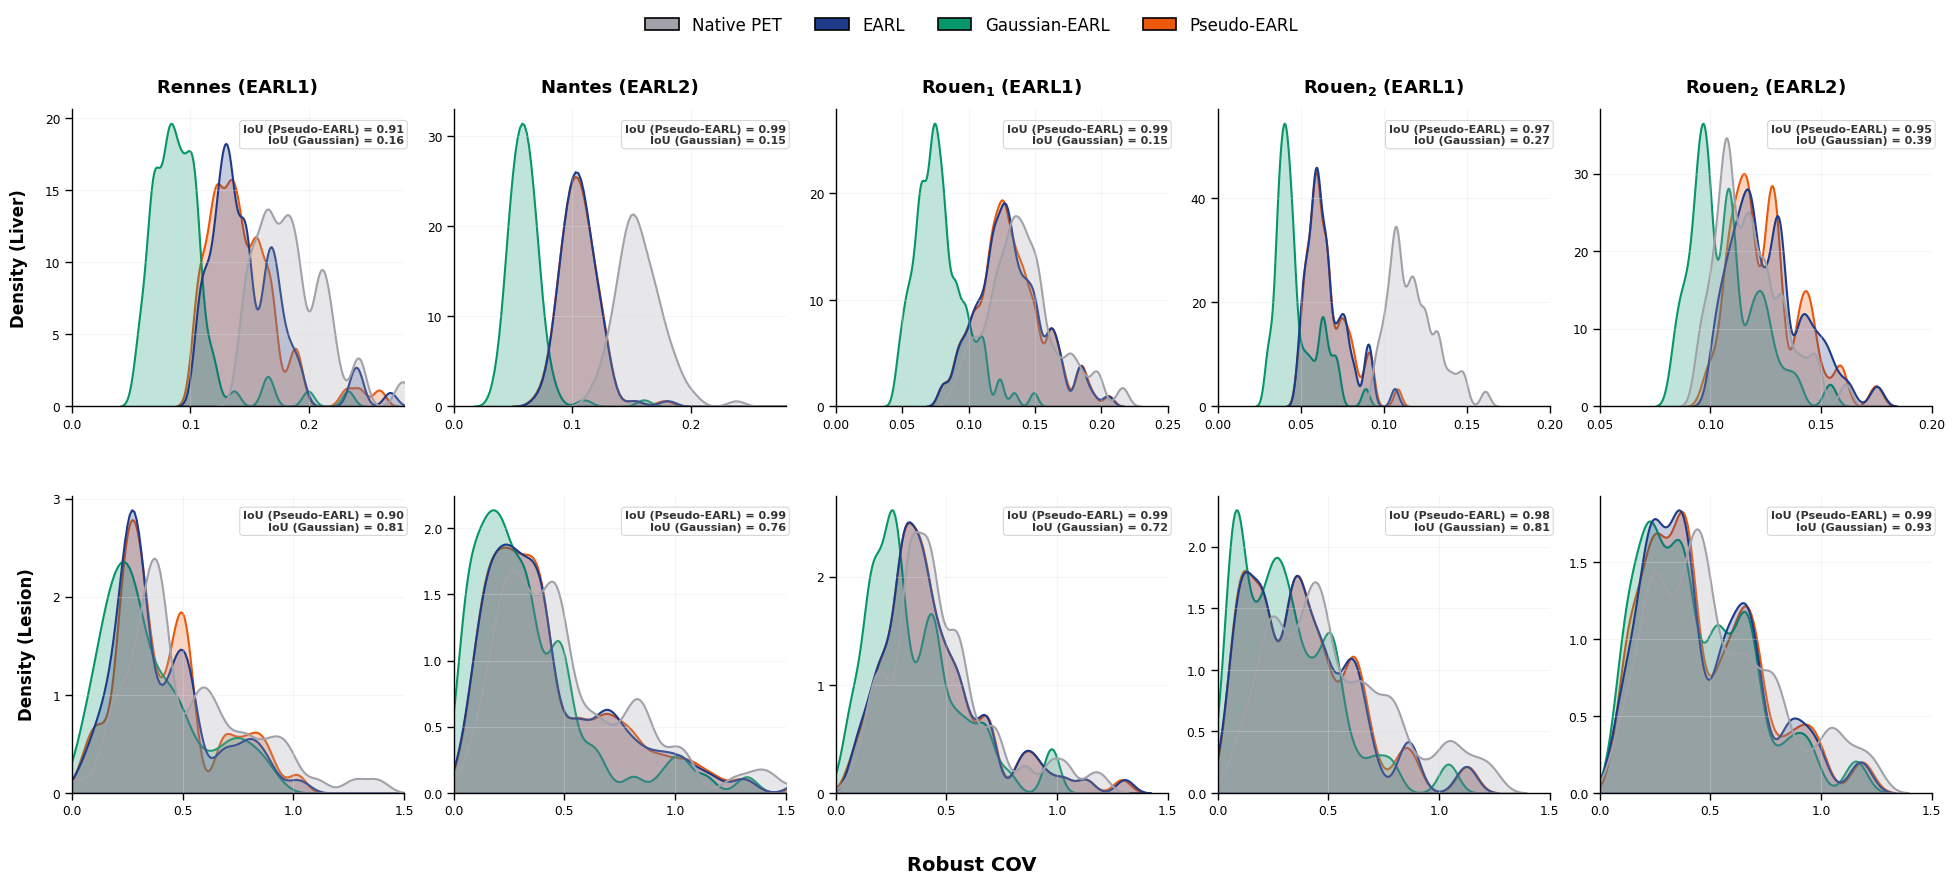

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde

# --- RÈGLES DE STYLE STRICTES ---
plt.style.use('default')

# Fonction utilitaire pour calculer mathématiquement l'Overlap (OVL) ou l'IoU
def calculate_overlap_metrics(data1, data2, metric_type='ovl'):
    if len(data1) < 2 or len(data2) < 2:
        return np.nan
        
    kde1 = gaussian_kde(data1)
    kde2 = gaussian_kde(data2)
    min_x = min(data1.min(), data2.min())
    max_x = max(data1.max(), data2.max())
    margin = (max_x - min_x) * 0.2
    
    # Évaluation sur une grille fine pour l'intégrale
    x_eval = np.linspace(min_x - margin, max_x + margin, 1000)
    y1, y2 = kde1(x_eval), kde2(x_eval)
    
    # Intégrale de l'intersection (minimum des deux courbes)
    ovl = np.trapz(np.minimum(y1, y2), x_eval)
    
    if metric_type.lower() == 'iou':
        # Calcul de l'IoU : Intersection / Union (Union = Aire_1 + Aire_2 - Intersection = 2 - OVL)
        return ovl / (2.0 - ovl)
    
    return ovl


def plot_density_seaborn_multivoi(df, 
                                  target_vois=['liver', 'lesion'], 
                                  metric='Robust_COV',
                                  overlap_metric='ovl',    # Choix entre 'ovl' et 'iou'
                                  xlim_list=None,          # Ex: [(0, 0.5), (0, 0.8), ...] (1 tuple par SUBPLOT, soit 10 au total)
                                  ylim_list=None,          # Ex: [(0, 15), (0, 8), ...]    (1 tuple par SUBPLOT, soit 10 au total)
                                  font_scale=1.3,
                                  base_fontsize=14,
                                  force_x_zero=False,
                                  show_all_y_ticks=True,
                                  bw_adjust_val=0.4,
                                  alpha_val=0.3):
    
    sns.set_context("paper", font_scale=font_scale)
    
    # --- 1. CONFIGURATION DES 5 CENTRES ---
    plot_configs = [
        {'domain_raw': 'rennes', 'title': 'Rennes (EARL1)', 'suffix': '1'},
        {'domain_raw': 'nantes', 'title': 'Nantes (EARL2)', 'suffix': '2'},
        {'domain_raw': 'chb', 'title': 'Rouen$_\\mathbf{1}$ (EARL1)', 'suffix': '1'},
        {'domain_raw': 'a100', 'title': 'Rouen$_\\mathbf{2}$ (EARL1)', 'suffix': '1'},
        {'domain_raw': 'a100', 'title': 'Rouen$_\\mathbf{2}$ (EARL2)', 'suffix': '2'}
    ]
    
    colors = ['#a1a1aa', '#1e3a8a', '#059669', '#ea580c'] 
    hue_order = ['Native PET', 'EARL', 'Gaussian-EARL', 'Pseudo-EARL']
    target_mods_all = ['standard', 'earl1', 'earl2', 'pseudo-earl1', 'pseudo-earl2', 'gaussian-earl1', 'gaussian-earl2']
    
    # --- 2. PRÉPARATION GLOBALE DES DONNÉES ---
    df_filtered = df[df['VOI'].str.lower().isin([v.lower() for v in target_vois])].copy()
    df_filtered['Domain'] = df_filtered['Domain'].str.lower()
    df_filtered['Modality'] = df_filtered['Modality'].str.lower()
    df_filtered = df_filtered.dropna(subset=['Domain', 'Modality', metric])
    
    n_rows = len(target_vois)
    n_cols = len(plot_configs)
    
    # --- 3. CRÉATION DE LA FIGURE ---
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4.5 * n_rows))
    
    if n_rows == 1:
        axes = np.atleast_2d(axes)
        
    for row_idx, target_voi in enumerate(target_vois):
        df_row = df_filtered[df_filtered['VOI'].str.lower() == target_voi.lower()]
        df_calc = df_row[df_row['Modality'].isin(target_mods_all)]
        
        # Calcul global (fallback) pour la ligne si aucune limite X n'est fournie
        if not df_calc.empty:
            xmin_calc, xmax_calc = np.percentile(df_calc[metric], 1), np.percentile(df_calc[metric], 99)
            margin = (xmax_calc - xmin_calc) * 0.1
            fallback_xmin = 0 if force_x_zero else max(0, xmin_calc - margin)
            fallback_xmax = xmax_calc + margin
        else:
            fallback_xmin, fallback_xmax = 0, 1

        for col_idx, config in enumerate(plot_configs):
            ax = axes[row_idx, col_idx]
            
            # Index global du subplot (de 0 à 9 pour une grille 2x5)
            flat_idx = row_idx * n_cols + col_idx
            
            domain_raw = config['domain_raw']
            suffix = config['suffix']
            raw_mods = ['standard', f'earl{suffix}', f'gaussian-earl{suffix}', f'pseudo-earl{suffix}']
            
            sub_df = df_row[(df_row['Domain'] == domain_raw) & 
                            (df_row['Modality'].isin(raw_mods))].copy()
            
            mod_map = {
                'standard': 'Native PET',
                f'earl{suffix}': 'EARL',
                f'gaussian-earl{suffix}': 'Gaussian-EARL',
                f'pseudo-earl{suffix}': 'Pseudo-EARL'
            }
            sub_df['Modality'] = sub_df['Modality'].map(mod_map)
            
            if sub_df.empty or len(sub_df) < 5:
                ax.text(0.5, 0.5, "Données insuffisantes", ha='center', va='center', fontsize=base_fontsize)
                ax.axis('off')
                continue
                
            # --- 3A. LE NUAGE (KDE Plot) ---
            sns.kdeplot(
                data=sub_df, x=metric, hue='Modality', hue_order=hue_order, palette=colors,
                fill=True, common_norm=False, alpha=alpha_val, linewidth=1.5, bw_adjust=bw_adjust_val,
                ax=ax, legend=False, zorder=1
            )
            
            # --- 3B. CALCUL ET AFFICHAGE DE LA MÉTRIQUE (OVL ou IoU) ---
            vals_earl = sub_df[sub_df['Modality'] == 'EARL'][metric].values
            vals_pseudo = sub_df[sub_df['Modality'] == 'Pseudo-EARL'][metric].values
            vals_gauss = sub_df[sub_df['Modality'] == 'Gaussian-EARL'][metric].values
            
            score_pseudo = calculate_overlap_metrics(vals_earl, vals_pseudo, metric_type=overlap_metric)
            score_gauss = calculate_overlap_metrics(vals_earl, vals_gauss, metric_type=overlap_metric)
            
            # Formatage du texte selon la métrique choisie
            metric_label = "IoU" if overlap_metric.lower() == 'iou' else "OVL"
            score_text = ""
            
            if not np.isnan(score_pseudo):
                score_text += f"{metric_label} (Pseudo-EARL) = {score_pseudo:.2f}\n"
            if not np.isnan(score_gauss):
                score_text += f"{metric_label} (Gaussian) = {score_gauss:.2f}"
                
            if score_text:
                # Affichage en haut à droite (1.0, 0.95) à l'intérieur du plot
                ax.text(1.0, 0.95, score_text.strip(), transform=ax.transAxes, 
                        ha='right', va='top', fontsize=8, fontweight='bold', color='#333333',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.8), zorder=5)
            
            # --- ESTHÉTIQUE & NETTOYAGE ---
            if row_idx == 0:
                ax.set_title(config['title'], fontweight='bold', pad=12, fontsize=base_fontsize + 1)
            else:
                ax.set_title("")
                
            ax.set_xlabel("")
            
            if col_idx == 0:
                ax.set_ylabel(f"Density ({target_voi.capitalize()})", fontweight='bold', labelpad=12, fontsize=base_fontsize)
            else:
                ax.set_ylabel("")
                
            # --- CONTRÔLE DES LIMITES X ET Y PAR SUBPLOT ---
            if xlim_list and len(xlim_list) > flat_idx and xlim_list[flat_idx] is not None:
                ax.set_xlim(xlim_list[flat_idx])
            else:
                ax.set_xlim(fallback_xmin, fallback_xmax)
                
            if ylim_list and len(ylim_list) > flat_idx and ylim_list[flat_idx] is not None:
                ax.set_ylim(ylim_list[flat_idx])
            else:
                ax.set_ylim(bottom=0)
            
            # Gestion des bordures et Ticks
            sns.despine(ax=ax, top=True, right=True, left=False)
            
            if show_all_y_ticks or col_idx == 0:
                ax.tick_params(labelleft=True)
            else:
                ax.tick_params(labelleft=False)
                
            ax.xaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
            ax.yaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
            ax.grid(axis='both', linestyle='-', alpha=0.3, color='#e0e0e0')

    # --- TEXTE GLOBAL AXE X ---
    fig.supxlabel(metric.replace('_', ' '), fontsize=base_fontsize + 2, fontweight='bold', y=0.03)

    # --- LÉGENDE GLOBALE ---
    legend_elements = [Patch(facecolor=c, edgecolor='black', linewidth=1.2, label=m) 
                       for m, c in zip(hue_order, colors)]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.00), 
               ncol=4, frameon=False, fontsize=base_fontsize)
    
    plt.subplots_adjust(hspace=0.3, wspace=0.15, bottom=0.12)
    plt.show()

# =========================================================
# EXEMPLE D'EXÉCUTION
# =========================================================
#
x_limits = [
    (0, 0.28), (0, 0.28), (0, 0.25), (0, 0.2), (0.05, 0.2), # Ligne 1 : Liver (5 plots)
    (0, 1.5),  (0, 1.5),  (0, 1.5),  (0, 1.5), (0, 1.5)     # Ligne 2 : Lesion (5 plots)
]

plot_density_seaborn_multivoi(
    master_df,
    overlap_metric='iou',      
    xlim_list=x_limits,
    font_scale=1.0,
    base_fontsize=12,
    bw_adjust_val=0.4,
    alpha_val=0.25
)

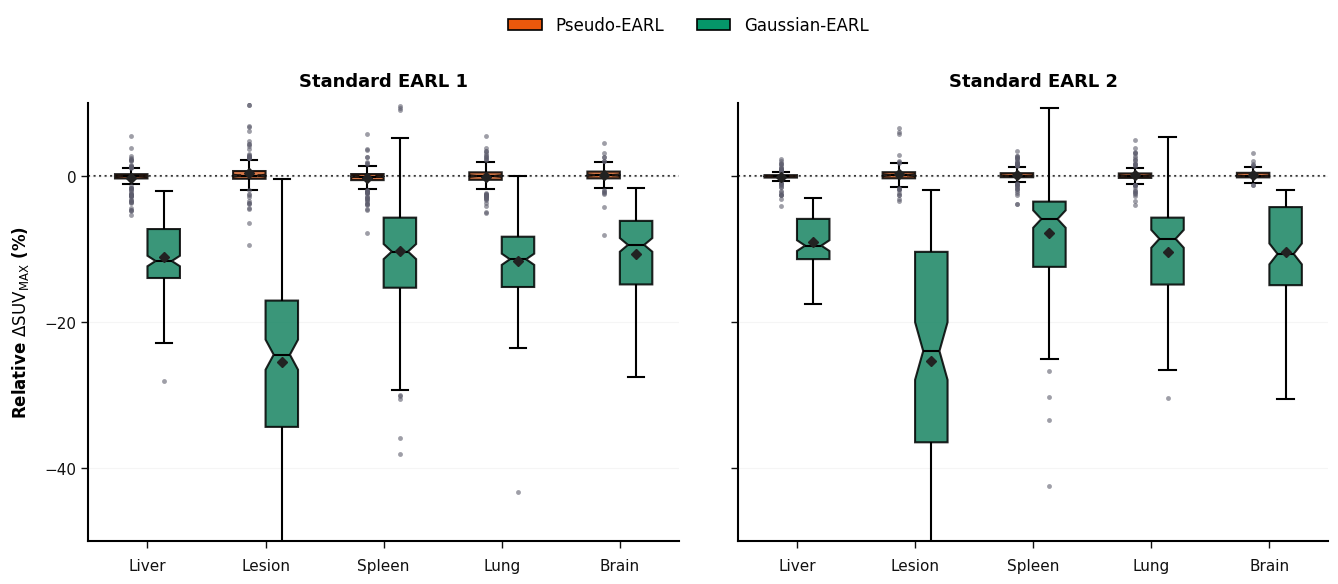

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

# --- APPLICATION STRICTE DE LA CHARTE YAML ---
plt.style.use('default')

def plot_relative_delta_boxplot(df, 
                                feature='original_firstorder_Maximum', 
                                target_vois=['Liver', 'Lesion', 'Spleen', 'Lung', 'Bone', 'Brain'],
                                figsize=(20, 6),       # 2 subplots confortables
                                ylim=None,              # Optionnel: tuple global pour l'axe Y (ex: (-30, 30))
                                box_width=0.6,          
                                box_alpha=0.85,         
                                show_outliers=True,     # Maintien des outliers selon ta demande
                                font_scale=1.2, 
                                base_fontsize=13):
    
    sns.set_context("paper", font_scale=font_scale)
    
    # --- 1. CONFIGURATION DES STANDARDS ET COULEURS (CHARTE) ---
    earl1_domains = ['rennes', 'chb', 'a100']
    earl2_domains = ['nantes', 'a100']
    
    colors = {
        'Pseudo-EARL': '#ea580c',     # Orange vif
        'Gaussian-EARL': '#059669'    # Vert émeraude
    }
    hue_order = ['Pseudo-EARL', 'Gaussian-EARL']
    
    # --- 2. FONCTION D'EXTRACTION DU DELTA RELATIF (%) ---
    def extract_relative_deltas(domains_list, suffix):
        data_list = []
        for voi in target_vois:
            for domain in domains_list:
                # Extraction
                earl = df[(df['VOI'].str.lower() == voi.lower()) & 
                          (df['Domain'].str.lower() == domain) & 
                          (df['Modality'].str.lower() == f'earl{suffix}')][feature].values
                
                pseudo = df[(df['VOI'].str.lower() == voi.lower()) & 
                            (df['Domain'].str.lower() == domain) & 
                            (df['Modality'].str.lower() == f'pseudo-earl{suffix}')][feature].values
                
                gauss = df[(df['VOI'].str.lower() == voi.lower()) & 
                           (df['Domain'].str.lower() == domain) & 
                           (df['Modality'].str.lower() == f'gaussian-earl{suffix}')][feature].values
                
                # Alignement sécurisé
                min_len = min(len(earl), len(pseudo), len(gauss))
                if min_len > 0:
                    earl, pseudo, gauss = earl[:min_len], pseudo[:min_len], gauss[:min_len]
                    
                    # CALCUL DU DELTA RELATIF (%) : ((Pred - Ref) / Ref) * 100
                    # Utilisation de np.where pour éviter les divisions par zéro
                    delta_pseudo_pct = np.where(earl == 0, np.nan, ((pseudo - earl) / earl) * 100)
                    delta_gauss_pct = np.where(earl == 0, np.nan, ((gauss - earl) / earl) * 100)
                    
                    for val in delta_pseudo_pct:
                        if not np.isnan(val):
                            data_list.append({'VOI': voi.capitalize(), 'Method': 'Pseudo-EARL', 'Delta_Pct': val})
                    for val in delta_gauss_pct:
                        if not np.isnan(val):
                            data_list.append({'VOI': voi.capitalize(), 'Method': 'Gaussian-EARL', 'Delta_Pct': val})
                        
        return pd.DataFrame(data_list)

    # Préparation des DataFrames
    df_plot1 = extract_relative_deltas(earl1_domains, suffix='1')
    df_plot2 = extract_relative_deltas(earl2_domains, suffix='2')

    # --- 3. CRÉATION DE LA FIGURE (1 ligne, 2 colonnes) ---
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True) # sharey=True car l'échelle % est commune !
    
    meanprops = {
        "marker": "D", 
        "markerfacecolor": "#222222", 
        "markeredgecolor": "#222222", 
        "markersize": 5
    }
    
    flierprops = {
        'marker': 'o', 
        'markerfacecolor': "#5d5d6d", 
        'markeredgecolor': 'none', 
        'alpha': 0.6, 
        'markersize': 3.5
    }

    plot_titles = [
        "Standard EARL 1", 
        "Standard EARL 2"
    ]
    plot_dfs = [df_plot1, df_plot2]
    
    for i in range(2):
        ax = axes[i]
        df_plot = plot_dfs[i]
        
        if df_plot.empty:
            ax.text(0.5, 0.5, "Données insuffisantes", ha='center', va='center', fontsize=base_fontsize)
            ax.axis('off')
            continue
            
        # --- 3A. LE NOTCHED BOXPLOT ---
        sns.boxplot(
            data=df_plot, x='VOI', y='Delta_Pct', hue='Method', palette=colors,
            hue_order=hue_order, notch=True, width=box_width, ax=ax,
            showmeans=True, meanprops=meanprops,
            showfliers=show_outliers, flierprops=flierprops,
            linewidth=1.5,
            linecolor='black',
            boxprops={'alpha': box_alpha, 'edgecolor': 'black'}
        )

        # --- 3B. LIGNE DE RÉFÉRENCE ZÉRO (0% d'erreur) ---
        ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.8, zorder=0)

        # --- ESTHÉTIQUE & NETTOYAGE ---
        ax.set_title(plot_titles[i], fontweight='bold', pad=12, fontsize=base_fontsize + 1)
        ax.set_xlabel("")
        
        # Label Y en pourcentage
        if i == 0:
            if 'Maximum' in feature:
                y_label = r"Relative $\Delta \text{SUV}_{\text{MAX}}$ (%)"
            elif 'Mean' in feature:
                y_label = r"Relative $\Delta \text{SUV}_{\text{MEAN}}$ (%)"
            else:
                y_label = r"Relative $\Delta$ (%)"
            ax.set_ylabel(y_label, fontweight='bold', labelpad=10, fontsize=base_fontsize)
        else:
            ax.set_ylabel("")
            
        if ylim is not None:
            ax.set_ylim(ylim)
            
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
        # Application YAML
        sns.despine(ax=ax, top=True, right=True, left=False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color("#000000")
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color("#000000")
        
        if i > 0:
            ax.tick_params(labelleft=False)
            
        ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize - 1, colors="#111111")
        ax.yaxis.set_tick_params(labelsize=base_fontsize - 1, colors="#111111")
        
        ax.set_axisbelow(True)
        ax.yaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
        ax.grid(axis='y', linestyle='-', alpha=0.3, color='#e0e0e0')

    # --- 4. LÉGENDE GLOBALE ---
    legend_elements = [Patch(facecolor=colors[m], edgecolor='black', linewidth=1.2, label=m) for m in hue_order]
    # legend_elements.append(plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#222222', markersize=8, label='Mean'))
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
               ncol=3, frameon=False, fontsize=base_fontsize)
    
    plt.subplots_adjust(wspace=0.10, bottom=0.15) # wspace réduit car l'échelle Y est partagée
    plt.show()

# =========================================================
# EXÉCUTION
# =========================================================
#
# Mode auto-adaptatif :
#plot_relative_delta_boxplot(master_df, feature='original_firstorder_Maximum')
#
# Mode avec limitation du pourcentage d'erreur (Ex: couper à +/- 30% d'erreur) 
# pour éviter qu'une lésion avec 200% d'erreur écrase le graphique :
plot_relative_delta_boxplot(
    master_df, 
    feature='original_firstorder_Maximum', 
    ylim=(-50, 10),
    font_scale=1.0,
    base_fontsize=12,
    figsize=(16, 6),
    box_width=0.55,
    show_outliers=True
)

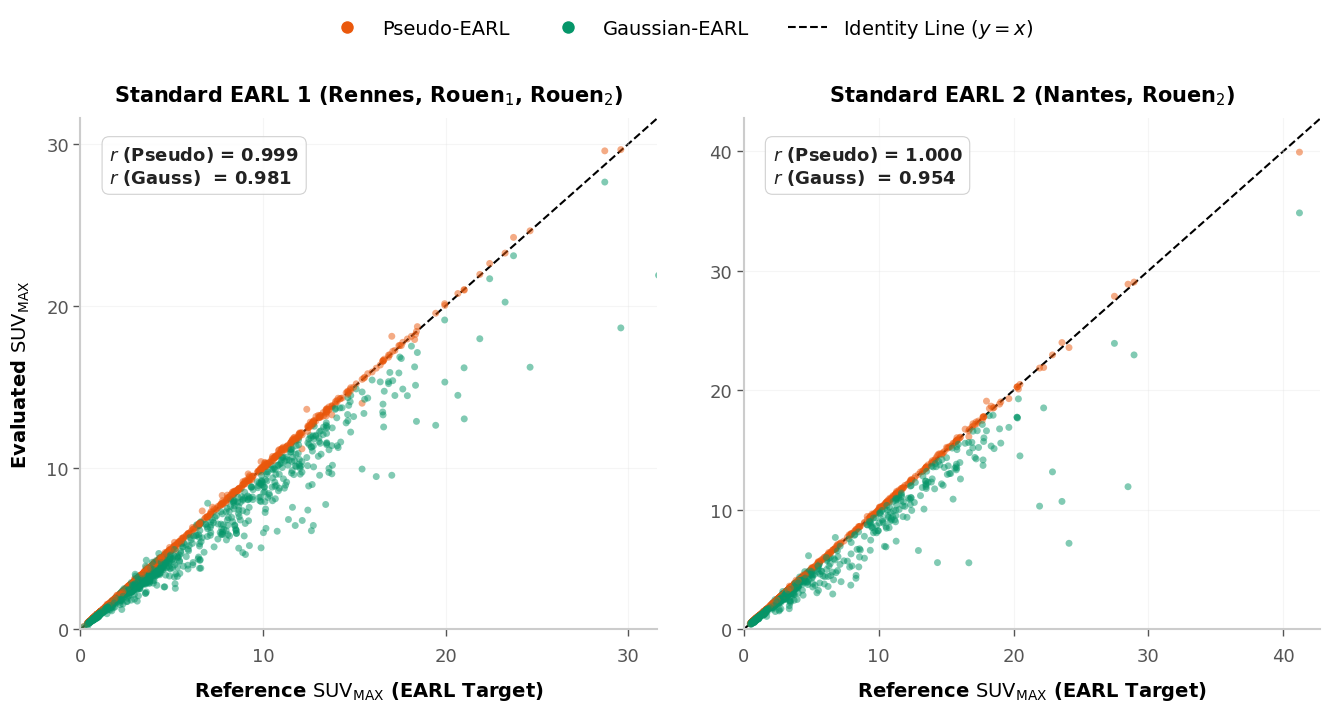

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# --- APPLICATION STRICTE DE LA CHARTE YAML ---
plt.style.use('default')

def plot_identity_scatter_standards(df, 
                                    feature='original_firstorder_Maximum', 
                                    target_vois=['Liver', 'Lesion', 'Spleen', 'Lung', 'Bone', 'Brain'],
                                    figsize=(16, 7),
                                    font_scale=1.2, 
                                    base_fontsize=14,
                                    zoom_percentile=99): # Permet de couper le 1% extrême pour ne pas écraser le plot
    
    sns.set_context("paper", font_scale=font_scale)
    
    # --- 1. CONFIGURATION (CHARTE) ---
    earl1_domains = ['rennes', 'chb', 'a100']
    earl2_domains = ['nantes', 'a100']
    
    colors = {
        'Pseudo-EARL': '#ea580c',     # Orange vif
        'Gaussian-EARL': '#059669'    # Vert émeraude
    }
    hue_order = ['Pseudo-EARL', 'Gaussian-EARL']
    
    # --- 2. EXTRACTION ET POOLING DES DONNÉES ---
    def extract_scatter_data(domains_list, suffix):
        data_list = []
        for voi in target_vois:
            for domain in domains_list:
                # Extraction des arrays
                earl = df[(df['VOI'].str.lower() == voi.lower()) & 
                          (df['Domain'].str.lower() == domain) & 
                          (df['Modality'].str.lower() == f'earl{suffix}')][feature].values
                
                pseudo = df[(df['VOI'].str.lower() == voi.lower()) & 
                            (df['Domain'].str.lower() == domain) & 
                            (df['Modality'].str.lower() == f'pseudo-earl{suffix}')][feature].values
                
                gauss = df[(df['VOI'].str.lower() == voi.lower()) & 
                           (df['Domain'].str.lower() == domain) & 
                           (df['Modality'].str.lower() == f'gaussian-earl{suffix}')][feature].values
                
                # Alignement sécurisé
                min_len = min(len(earl), len(pseudo), len(gauss))
                if min_len > 0:
                    earl, pseudo, gauss = earl[:min_len], pseudo[:min_len], gauss[:min_len]
                    
                    # On crée les couples (X=Target, Y=Prediction)
                    for t, p in zip(earl, pseudo):
                        data_list.append({'Target': t, 'Prediction': p, 'Method': 'Pseudo-EARL'})
                    for t, g in zip(earl, gauss):
                        data_list.append({'Target': t, 'Prediction': g, 'Method': 'Gaussian-EARL'})
                        
        return pd.DataFrame(data_list)

    df_plot1 = extract_scatter_data(earl1_domains, suffix='1')
    df_plot2 = extract_scatter_data(earl2_domains, suffix='2')

    # --- 3. CRÉATION DE LA FIGURE (1 ligne, 2 subplots) ---
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    plot_titles = [
        "Standard EARL 1 (Rennes, Rouen$_1$, Rouen$_2$)", 
        "Standard EARL 2 (Nantes, Rouen$_2$)"
    ]
    plot_dfs = [df_plot1, df_plot2]
    
    # Formatage du nom de la métrique
    if 'Maximum' in feature:
        metric_name = r"$\text{SUV}_{\text{MAX}}$"
    elif 'Mean' in feature:
        metric_name = r"$\text{SUV}_{\text{MEAN}}$"
    else:
        metric_name = feature.replace('original_firstorder_', '')
    
    for i in range(2):
        ax = axes[i]
        df_sub = plot_dfs[i]
        
        if df_sub.empty:
            ax.text(0.5, 0.5, "Données insuffisantes", ha='center', va='center', fontsize=base_fontsize)
            ax.axis('off')
            continue
            
        # --- 3A. TRACÉ DES NUAGES DE POINTS (100% Seaborn) ---
        # On trace d'abord le Gaussian, puis le Pseudo par-dessus (car le Pseudo est souvent meilleur et plus dense)
        sns.scatterplot(
            data=df_sub, x='Target', y='Prediction', hue='Method', 
            palette=colors, hue_order=hue_order[::-1], # Inversion d'ordre pour le zorder de tracé
            s=25, alpha=0.5, edgecolor='none', ax=ax, legend=False
        )
        
        # --- 3B. LIGNE D'IDENTITÉ ET LIMITES ---
        # Calcul du zoom robuste basé sur les cibles (EARL)
        val_max = np.percentile(df_sub['Target'], zoom_percentile) * 1.1
        val_min = 0 # Le SUV ne descend jamais sous zéro
        
        # Diagonale parfaite (y = x)
        ax.plot([val_min, val_max], [val_min, val_max], color='black', linestyle='--', linewidth=1.5, zorder=0)
        
        # --- 3C. CALCUL DES CORRÉLATIONS (Pearson r) ---
        target_pseudo = df_sub[df_sub['Method'] == 'Pseudo-EARL']['Target'].values
        pred_pseudo = df_sub[df_sub['Method'] == 'Pseudo-EARL']['Prediction'].values
        
        target_gauss = df_sub[df_sub['Method'] == 'Gaussian-EARL']['Target'].values
        pred_gauss = df_sub[df_sub['Method'] == 'Gaussian-EARL']['Prediction'].values
        
        r_pseudo = np.corrcoef(target_pseudo, pred_pseudo)[0, 1] if len(target_pseudo) > 1 else np.nan
        r_gauss = np.corrcoef(target_gauss, pred_gauss)[0, 1] if len(target_gauss) > 1 else np.nan
        
        # Affichage du texte de corrélation
        stats_text = f"$r$ (Pseudo) = {r_pseudo:.3f}\n$r$ (Gauss)  = {r_gauss:.3f}"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                ha='left', va='top', fontsize=base_fontsize - 1, fontweight='bold', color='#222222',
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", alpha=0.9), zorder=5)

        # --- ESTHÉTIQUE & NETTOYAGE ---
        ax.set_title(plot_titles[i], fontweight='bold', pad=12, fontsize=base_fontsize + 1)
        
        ax.set_xlabel(f"Reference {metric_name} (EARL Target)", fontweight='bold', labelpad=10, fontsize=base_fontsize)
        if i == 0:
            ax.set_ylabel(f"Evaluated {metric_name}", fontweight='bold', labelpad=10, fontsize=base_fontsize)
        else:
            ax.set_ylabel("")
            
        ax.set_xlim(val_min, val_max)
        ax.set_ylim(val_min, val_max)
        
        # Charte YAML Spines & Ticks
        sns.despine(ax=ax, top=True, right=True, left=False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('#cccccc')
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('#cccccc')
        
        ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize - 1, colors="#555555")
        ax.yaxis.set_tick_params(labelsize=base_fontsize - 1, colors="#555555")
        
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
        ax.yaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
        ax.grid(axis='both', linestyle='-', alpha=0.3, color='#e0e0e0')

    # --- 4. LÉGENDE GLOBALE ---
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[m], markersize=10, label=m) 
                       for m in hue_order]
    legend_elements.append(Line2D([0], [0], color='black', linestyle='--', linewidth=1.5, label='Identity Line ($y=x$)'))
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
               ncol=3, frameon=False, fontsize=base_fontsize)
    
    plt.subplots_adjust(wspace=0.15, bottom=0.15)
    plt.show()

# =========================================================
# EXÉCUTION
# =========================================================
#
plot_identity_scatter_standards(master_df, feature='original_firstorder_Maximum')

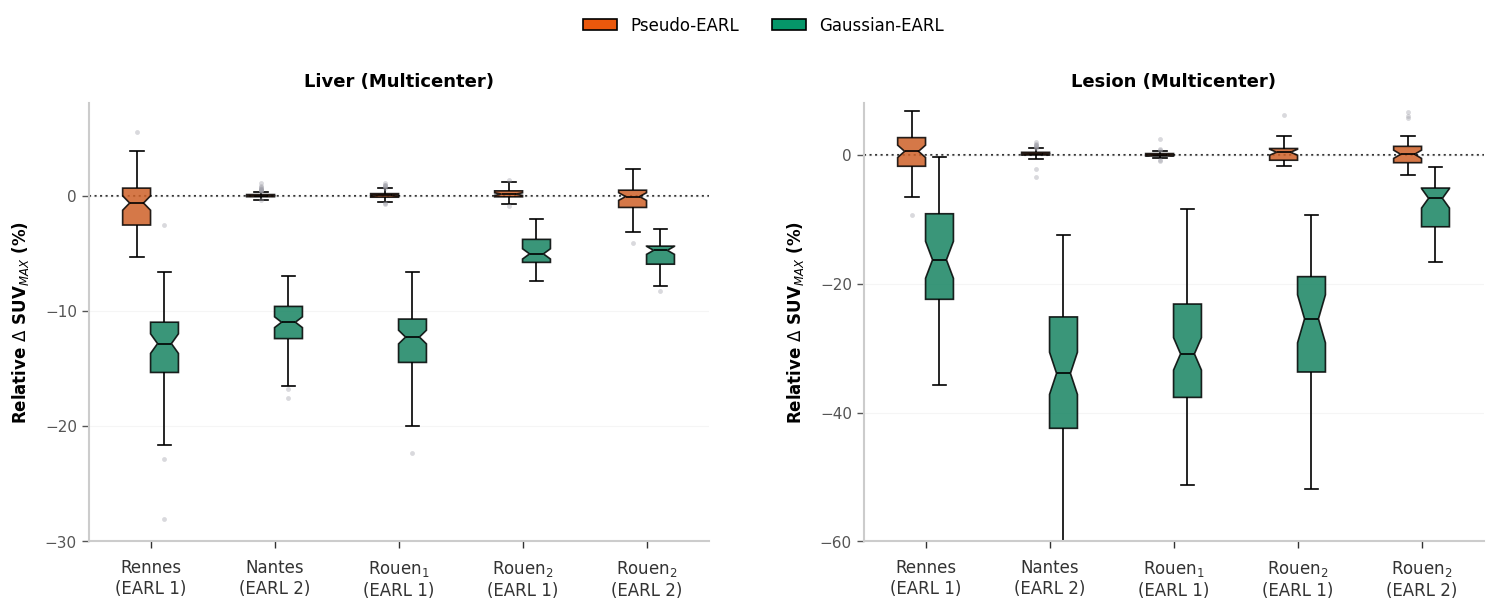

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

# --- APPLICATION STRICTE DE LA CHARTE YAML ---
plt.style.use('default')

def plot_multicenter_delta_voi_grid(df, 
                                    feature='original_firstorder_Maximum', 
                                    target_vois=['liver', 'lesion'], 
                                    delta_type='relative',  # 'relative' (%) ou 'absolute' (valeur brute)
                                    figsize=(20, 6),        # Format large pour 2 colonnes
                                    ylim_list=None,         # Liste de 2 tuples, ex: [(-10, 10), (-40, 40)]
                                    box_width=0.6,          
                                    box_alpha=0.85,         
                                    show_outliers=True,     
                                    font_scale=1.2, 
                                    base_fontsize=14):
    
    sns.set_context("paper", font_scale=font_scale)
    
    if delta_type not in ['relative', 'absolute']:
        raise ValueError("delta_type doit être 'relative' ou 'absolute'")
    
    # --- 1. CONFIGURATION DES 5 CENTRES (CHARTE) ---
    plot_configs = [
        {'domain_raw': 'rennes', 'label': 'Rennes\n(EARL 1)', 'suffix': '1'},
        {'domain_raw': 'nantes', 'label': 'Nantes\n(EARL 2)', 'suffix': '2'},
        {'domain_raw': 'chb', 'label': 'Rouen$_1$\n(EARL 1)', 'suffix': '1'},
        {'domain_raw': 'a100', 'label': 'Rouen$_2$\n(EARL 1)', 'suffix': '1'},
        {'domain_raw': 'a100', 'label': 'Rouen$_2$\n(EARL 2)', 'suffix': '2'}
    ]
    
    colors = {
        'Pseudo-EARL': '#ea580c',     # Orange vif
        'Gaussian-EARL': '#059669'    # Vert émeraude
    }
    hue_order = ['Pseudo-EARL', 'Gaussian-EARL']
    
    # --- 2. EXTRACTION ET CALCUL DU DELTA ---
    data_list = []
    
    for voi in target_vois:
        for config in plot_configs:
            domain = config['domain_raw']
            suffix = config['suffix']
            center_label = config['label']
            
            # Extraction stricte
            earl = df[(df['VOI'].str.lower() == voi.lower()) & 
                      (df['Domain'].str.lower() == domain) & 
                      (df['Modality'].str.lower() == f'earl{suffix}')][feature].values
            
            pseudo = df[(df['VOI'].str.lower() == voi.lower()) & 
                        (df['Domain'].str.lower() == domain) & 
                        (df['Modality'].str.lower() == f'pseudo-earl{suffix}')][feature].values
            
            gauss = df[(df['VOI'].str.lower() == voi.lower()) & 
                       (df['Domain'].str.lower() == domain) & 
                       (df['Modality'].str.lower() == f'gaussian-earl{suffix}')][feature].values
            
            # Alignement des tailles
            min_len = min(len(earl), len(pseudo), len(gauss))
            if min_len > 0:
                earl, pseudo, gauss = earl[:min_len], pseudo[:min_len], gauss[:min_len]
                
                if delta_type == 'relative':
                    # Delta Relatif (%)
                    delta_pseudo = np.where(earl == 0, np.nan, ((pseudo - earl) / earl) * 100)
                    delta_gauss = np.where(earl == 0, np.nan, ((gauss - earl) / earl) * 100)
                else:
                    # Delta Absolu
                    delta_pseudo = pseudo - earl
                    delta_gauss = gauss - earl
                
                # Injection dans les données de tracé
                for val in delta_pseudo:
                    if not np.isnan(val):
                        data_list.append({'VOI': voi.capitalize(), 'Center': center_label, 'Method': 'Pseudo-EARL', 'Delta': val})
                for val in delta_gauss:
                    if not np.isnan(val):
                        data_list.append({'VOI': voi.capitalize(), 'Center': center_label, 'Method': 'Gaussian-EARL', 'Delta': val})
                        
    df_plot = pd.DataFrame(data_list)
    
    if df_plot.empty:
        print("Aucune donnée trouvée.")
        return

    # --- 3. CRÉATION DE LA FIGURE (1 ligne, 2 subplots) ---
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    flierprops = {
        'marker': 'o', 
        'markerfacecolor': '#a1a1aa', 
        'markeredgecolor': 'none', 
        'alpha': 0.4, 
        'markersize': 3.5
    }

    # Formatage de l'axe Y sans balise \text{} pour éviter les erreurs d'affichage
    if 'Maximum' in feature:
        metric_clean = r"SUV$_{MAX}$"
    elif 'Mean' in feature:
        metric_clean = r"SUV$_{MEAN}$"
    else:
        metric_clean = feature.replace('original_firstorder_', '')
        
    if delta_type == 'relative':
        y_label = f"Relative $\\Delta$ {metric_clean} (%)"
    else:
        y_label = f"Absolute $\\Delta$ {metric_clean}"

    for i, voi in enumerate(target_vois):
        ax = axes[i]
        df_sub = df_plot[df_plot['VOI'] == voi.capitalize()]
        
        if df_sub.empty:
            ax.text(0.5, 0.5, "Données insuffisantes", ha='center', va='center')
            ax.axis('off')
            continue
            
        # --- 3A. TRACÉ DU NOTCHED BOXPLOT ---
        sns.boxplot(
            data=df_sub, x='Center', y='Delta', hue='Method', palette=colors,
            hue_order=hue_order, notch=True, width=box_width, ax=ax,
            showmeans=False, # <-- Le marqueur de moyenne a été supprimé ici
            showfliers=show_outliers, flierprops=flierprops,
            linewidth=1.2,
            linecolor='black',
            boxprops={'alpha': box_alpha, 'edgecolor': 'black'}
        )
        
        # --- 3B. LIGNE DE RÉFÉRENCE ZÉRO ---
        ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.8, zorder=0)

        # --- ESTHÉTIQUE & NETTOYAGE ---
        ax.set_title(f"{voi.capitalize()} (Multicenter)", fontweight='bold', pad=12, fontsize=base_fontsize + 1)
        ax.set_xlabel("")
        
        # Axe Y affiché à gauche pour chaque sous-graphique, car les échelles diffèrent
        ax.set_ylabel(y_label, fontweight='bold', labelpad=10, fontsize=base_fontsize)
            
        # Application des limites personnalisées (Foie et Lésion séparément)
        if ylim_list and len(ylim_list) > i and ylim_list[i] is not None:
            ax.set_ylim(ylim_list[i])
            
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
        # Charte YAML (Bordures et Grille)
        sns.despine(ax=ax, top=True, right=True, left=False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('#cccccc')
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('#cccccc')
        
        ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize, colors="#333333")
        ax.yaxis.set_tick_params(labelsize=base_fontsize - 1, colors="#555555")
        
        ax.set_axisbelow(True)
        ax.yaxis.set_major_locator(MaxNLocator(5, steps=[1, 2, 5, 10]))
        ax.grid(axis='y', linestyle='-', alpha=0.3, color='#e0e0e0')

    # --- 4. LÉGENDE GLOBALE ---
    # La mention "Mean Error" a été retirée de la légende
    legend_elements = [Patch(facecolor=colors[m], edgecolor='black', linewidth=1.2, label=m) for m in hue_order]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
               ncol=2, frameon=False, fontsize=base_fontsize)
    
    plt.subplots_adjust(wspace=0.25, bottom=0.15)
    plt.show()

# =========================================================
# EXEMPLES D'EXÉCUTION
# =========================================================
#
# Utilisation de ylim_list pour limiter l'axe du Foie et de la Lésion séparément :
# - Foie (Index 0) : +/- 15%
# - Lésion (Index 1) : +/- 40%
#
y_limits = [(-30, 8), (-60, 8)]
plot_multicenter_delta_voi_grid(
    master_df, 
    delta_type='relative', 
    ylim_list=y_limits,
    figsize=(18, 6),
    font_scale=1.0,
    base_fontsize=12,
    box_width=0.45
)

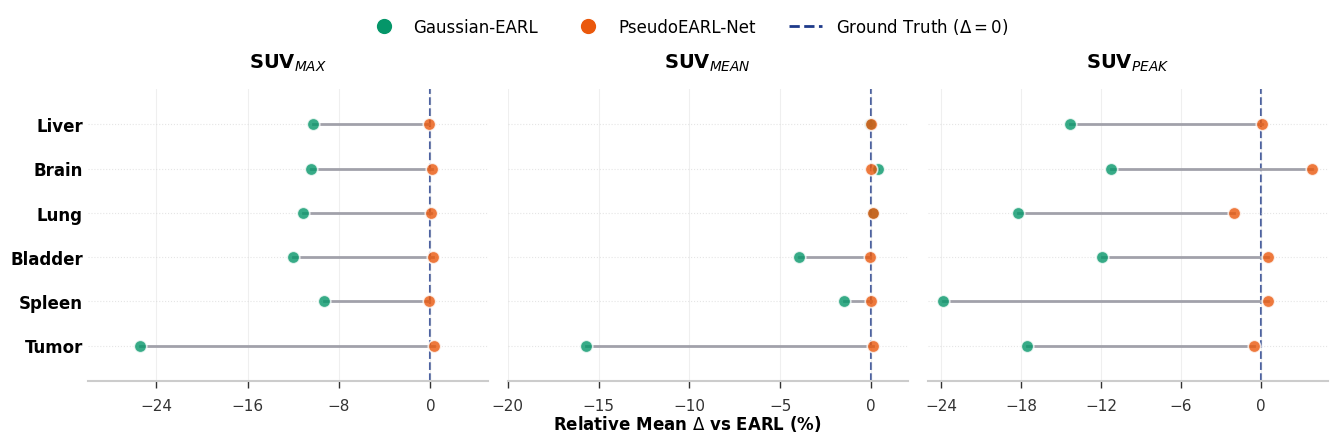

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# --- APPLICATION STRICTE DE LA CHARTE YAML ---
plt.style.use('default')

def plot_aggregated_quantification_dumbbell(df, 
                                            target_vois=['Liver', 'Brain', 'Lung', 'Urinary_bladder', 'Spleen', 'Lesion'],
                                            voi_mapping=None,       # <-- NOUVEAU PARAMÈTRE ICI
                                            delta_type='relative',  
                                            figsize=(18, 5.5),      
                                            xlim_list=None,         
                                            wspace_val=0.10,        
                                            y_margin=0.6,           
                                            marker_size=150,        
                                            connector_linewidth=3,  
                                            target_linewidth=2,     
                                            font_scale=1.2, 
                                            base_fontsize=13):
    
    sns.set_context("paper", font_scale=font_scale)
    
    # --- 1. CONFIGURATION (CHARTE ET MOCK) ---
    earl1_domains = ['rennes', 'chb', 'a100']
    earl2_domains = ['nantes', 'a100']
    
    colors = {
        'EARL_Target': '#1e3a8a',     
        'Pseudo-EARL': '#ea580c',     
        'Gaussian-EARL': '#059669'    
    }
    
    metrics_config = [
        ('original_firstorder_Maximum', r'SUV$_{MAX}$'),
        ('original_firstorder_Mean', r'SUV$_{MEAN}$'),
        ('original_firstorder_Peak', r'SUV$_{PEAK}$') 
    ]
    
    # --- GESTION DU MAPPING DES NOMS DE VOI ---
    if voi_mapping is None:
        voi_mapping = {}
        
    # Création d'un dictionnaire de traduction sécurisé : 
    # S'il n'y a pas de traduction fournie pour un VOI, il applique le formatage par défaut
    display_names = {v: voi_mapping.get(v, v.replace('_', ' ').title()) for v in target_vois}
    
    # --- 2. EXTRACTION ET AGRÉGATION GLOBALE ---
    data_list = []
    
    for feature, metric_name in metrics_config:
        is_mock = feature not in df.columns
        
        for voi in target_vois:
            if is_mock:
                delta_pseudo = np.random.normal(loc=1.5, scale=2.0) if delta_type == 'relative' else np.random.normal(0.1, 0.2)
                delta_gauss = np.random.normal(loc=-15.0, scale=5.0) if delta_type == 'relative' else np.random.normal(-1.5, 0.5)
            else:
                earl_all, pseudo_all, gauss_all = [], [], []
                
                for domains, suffix in [(earl1_domains, '1'), (earl2_domains, '2')]:
                    for domain in domains:
                        earl = df[(df['VOI'].str.lower() == voi.lower()) & 
                                  (df['Domain'].str.lower() == domain) & 
                                  (df['Modality'].str.lower() == f'earl{suffix}')][feature].values
                        pseudo = df[(df['VOI'].str.lower() == voi.lower()) & 
                                    (df['Domain'].str.lower() == domain) & 
                                    (df['Modality'].str.lower() == f'pseudo-earl{suffix}')][feature].values
                        gauss = df[(df['VOI'].str.lower() == voi.lower()) & 
                                   (df['Domain'].str.lower() == domain) & 
                                   (df['Modality'].str.lower() == f'gaussian-earl{suffix}')][feature].values
                        
                        min_len = min(len(earl), len(pseudo), len(gauss))
                        if min_len > 0:
                            earl_all.extend(earl[:min_len])
                            pseudo_all.extend(pseudo[:min_len])
                            gauss_all.extend(gauss[:min_len])
                
                earl_arr, pseudo_arr, gauss_arr = np.array(earl_all), np.array(pseudo_all), np.array(gauss_all)
                
                if len(earl_arr) > 0:
                    with np.errstate(divide='ignore', invalid='ignore'):
                        if delta_type == 'relative':
                            delta_pseudo = np.nanmean(np.where(earl_arr == 0, np.nan, ((pseudo_arr - earl_arr) / earl_arr) * 100))
                            delta_gauss = np.nanmean(np.where(earl_arr == 0, np.nan, ((gauss_arr - earl_arr) / earl_arr) * 100))
                        else:
                            delta_pseudo = np.mean(pseudo_arr - earl_arr)
                            delta_gauss = np.mean(gauss_arr - earl_arr)
                else:
                    delta_pseudo, delta_gauss = np.nan, np.nan

            if not np.isnan(delta_pseudo):
                data_list.append({
                    'Metric': metric_name,
                    'VOI_Display': display_names[voi], # <-- On utilise le nom formaté final
                    'Delta_Pseudo': delta_pseudo,
                    'Delta_Gauss': delta_gauss
                })
                    
    df_plot = pd.DataFrame(data_list)
    if df_plot.empty:
        print("Aucune donnée extraite.")
        return

    # --- 3. CRÉATION DE LA FIGURE ---
    n_cols = len(metrics_config)
    fig, axes = plt.subplots(1, n_cols, figsize=figsize, sharey=True)
    
    # Création de la liste des noms pour l'axe Y (inversée pour avoir le 1er en haut)
    ordered_display_vois = [display_names[v] for v in target_vois][::-1]
    
    for col_idx, (_, metric_name) in enumerate(metrics_config):
        ax = axes[col_idx]
        df_sub = df_plot[df_plot['Metric'] == metric_name]
        
        if df_sub.empty:
            ax.axis('off')
            continue
            
        # --- 3A. TRACÉ DU DUMBBELL ---
        for y_idx, voi_name in enumerate(ordered_display_vois):
            row_data = df_sub[df_sub['VOI_Display'] == voi_name]
            if not row_data.empty:
                val_pseudo = row_data['Delta_Pseudo'].values[0]
                val_gauss = row_data['Delta_Gauss'].values[0]
                
                ax.plot([val_gauss, val_pseudo], [y_idx, y_idx], color='#a1a1aa', linewidth=connector_linewidth, zorder=1)
                ax.scatter(val_gauss, y_idx, color=colors['Gaussian-EARL'], s=marker_size, zorder=2, edgecolors='white', linewidths=1.2, alpha=0.8)
                ax.scatter(val_pseudo, y_idx, color=colors['Pseudo-EARL'], s=marker_size, zorder=3, edgecolors='white', linewidths=1.2, alpha=0.8)
        
        # --- 3B. LIGNE DE RÉFÉRENCE ---
        ax.axvline(0, color=colors['EARL_Target'], linestyle='--', linewidth=target_linewidth, zorder=0, alpha=0.8)
        
        # --- ESTHÉTIQUE & NETTOYAGE ---
        ax.set_title(metric_name, fontweight='bold', pad=15, fontsize=base_fontsize + 2)
        
        if xlim_list and len(xlim_list) > col_idx and xlim_list[col_idx] is not None:
            ax.set_xlim(xlim_list[col_idx])
            
        ax.set_ylim(-y_margin, len(ordered_display_vois) - 1 + y_margin)
        ax.set_yticks(range(len(ordered_display_vois)))
        
        if col_idx == 0:
            ax.set_yticklabels(ordered_display_vois, fontweight='bold', fontsize=base_fontsize)
        else:
            ax.tick_params(labelleft=False)
            
        sns.despine(ax=ax, top=True, right=True, left=True)
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('#cccccc')
        
        ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize - 1, colors="#333333")
        ax.yaxis.set_tick_params(length=0) 
        
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(MaxNLocator(5)) 
        ax.grid(axis='y', linestyle=':', alpha=0.5, color='#cccccc')
        ax.grid(axis='x', linestyle='-', alpha=0.3, color='#cccccc')

    # --- 4. LABEL X ET LÉGENDE ---
    x_label_txt = r"Relative Mean $\Delta$ vs EARL (%)" if delta_type == 'relative' else r"Absolute Mean $\Delta$ vs EARL"
    fig.supxlabel(x_label_txt, fontweight='bold', fontsize=base_fontsize, y=0.02)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Gaussian-EARL'], markersize=12, label='Gaussian-EARL'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Pseudo-EARL'], markersize=12, label='PseudoEARL-Net'),
        Line2D([0], [0], color=colors['EARL_Target'], linestyle='--', linewidth=2, label='Ground Truth ($\Delta = 0$)')
    ]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.1), 
               ncol=3, frameon=False, fontsize=base_fontsize)
    
    plt.subplots_adjust(wspace=wspace_val, bottom=0.15, top=0.88)
    plt.show()

# =========================================================
# EXÉCUTION AVEC LE MAPPING PERSONNALISÉ
# =========================================================

# Ton dictionnaire de renommage personnalisé
custom_labels = {
    'Urinary_bladder': 'Bladder',
    'Liver': 'Liver',        # Optionnel, se formaterait tout seul
    'Lesion': 'Tumor'        # Tu peux même renommer Lesion en Tumor si le journal le préfère !
}

# Exemple : On limite le SUV_MAX entre -30% et +10%, le SUV_MEAN entre -10% et +5%, etc.
limites_x = [
    (-30, 5), # Pour SUV_MAX
    (-20,  2), # Pour SUV_MEAN
    (-25, 5)  # Pour SUV_PEAK
]

plot_aggregated_quantification_dumbbell(
    master_df, 
    voi_mapping=custom_labels,
    delta_type='relative', 
    xlim_list=limites_x,
    wspace_val=0.05,       # Rapproche les 3 colonnes au maximum
    y_margin=0.8,          # Aère l'espace au-dessus du premier organe et en-dessous du dernier
    marker_size=80,       # Grossit légèrement les ronds
    connector_linewidth=2,
    figsize=(16, 4),
    target_linewidth=1.5,
    font_scale=1.0,
    base_fontsize=12
)

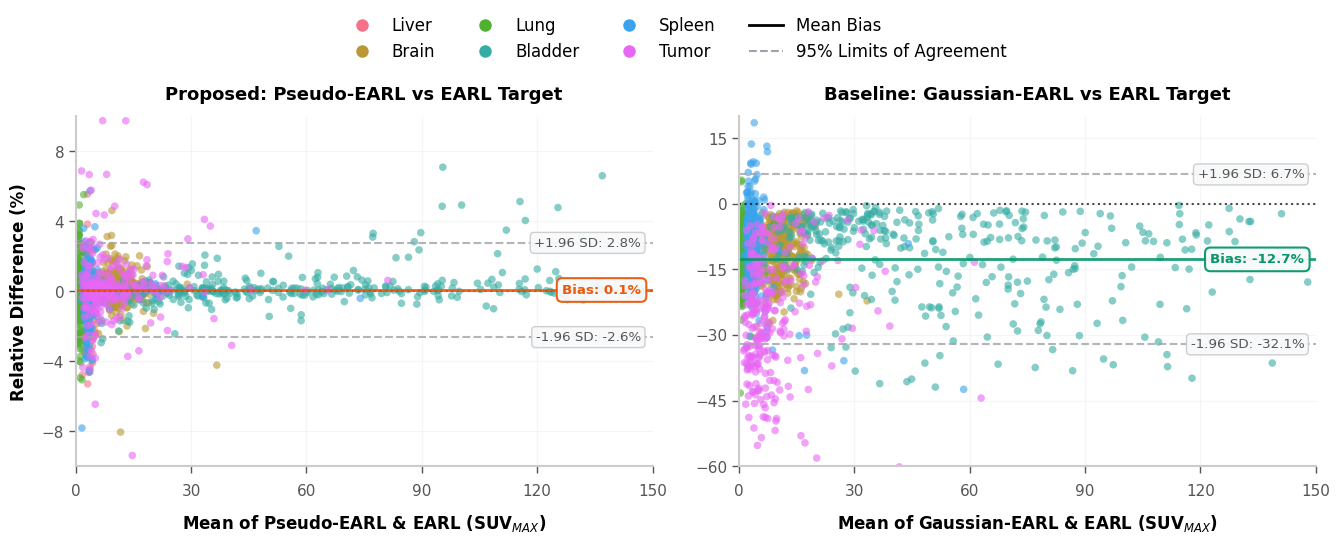

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# --- APPLICATION STRICTE DE LA CHARTE YAML ---
plt.style.use('default')

def plot_bland_altman_aggregated_fixed_limits(df, 
                                              feature='original_firstorder_Maximum', 
                                              target_vois=['Liver', 'Brain', 'Lung', 'Urinary_bladder', 'Spleen', 'Lesion'],
                                              voi_mapping=None,
                                              figsize=(16, 7),
                                              xlim_list=None,     
                                              ylim_list=None,     
                                              font_scale=1.2, 
                                              base_fontsize=14):
    
    sns.set_context("paper", font_scale=font_scale)
    
    # --- 1. CONFIGURATION (CHARTE) ---
    earl1_domains = ['rennes', 'chb', 'a100']
    earl2_domains = ['nantes', 'a100']
    
    method_colors = {
        'Pseudo-EARL': '#ea580c',     
        'Gaussian-EARL': '#059669'    
    }
    
    if voi_mapping is None:
        voi_mapping = {}
    display_names = {v: voi_mapping.get(v, v.replace('_', ' ').title()) for v in target_vois}
    
    voi_palette = sns.color_palette("husl", len(target_vois))
    voi_color_dict = {display_names[v]: voi_palette[i] for i, v in enumerate(target_vois)}
    
    # --- 2. EXTRACTION ET POOLING DES DONNÉES ---
    data_list = []
    
    for voi in target_vois:
        earl_all, pseudo_all, gauss_all = [], [], []
        
        for domains, suffix in [(earl1_domains, '1'), (earl2_domains, '2')]:
            for domain in domains:
                earl = df[(df['VOI'].str.lower() == voi.lower()) & 
                          (df['Domain'].str.lower() == domain) & 
                          (df['Modality'].str.lower() == f'earl{suffix}')][feature].values
                pseudo = df[(df['VOI'].str.lower() == voi.lower()) & 
                            (df['Domain'].str.lower() == domain) & 
                            (df['Modality'].str.lower() == f'pseudo-earl{suffix}')][feature].values
                gauss = df[(df['VOI'].str.lower() == voi.lower()) & 
                           (df['Domain'].str.lower() == domain) & 
                           (df['Modality'].str.lower() == f'gaussian-earl{suffix}')][feature].values
                
                min_len = min(len(earl), len(pseudo), len(gauss))
                if min_len > 0:
                    earl_all.extend(earl[:min_len])
                    pseudo_all.extend(pseudo[:min_len])
                    gauss_all.extend(gauss[:min_len])
        
        earl_arr, pseudo_arr, gauss_arr = np.array(earl_all), np.array(pseudo_all), np.array(gauss_all)
        
        if len(earl_arr) > 0:
            with np.errstate(divide='ignore', invalid='ignore'):
                mean_pseudo_axis = (pseudo_arr + earl_arr) / 2
                mean_gauss_axis = (gauss_arr + earl_arr) / 2
                
                diff_pseudo_pct = np.where(earl_arr == 0, np.nan, ((pseudo_arr - earl_arr) / earl_arr) * 100)
                diff_gauss_pct = np.where(earl_arr == 0, np.nan, ((gauss_arr - earl_arr) / earl_arr) * 100)
                
            for m_p, d_p, m_g, d_g in zip(mean_pseudo_axis, diff_pseudo_pct, mean_gauss_axis, diff_gauss_pct):
                if not np.isnan(d_p) and not np.isnan(d_g):
                    data_list.append({
                        'VOI_Display': display_names[voi],
                        'Mean_Pseudo': m_p, 'Diff_Pseudo': d_p,
                        'Mean_Gauss': m_g, 'Diff_Gauss': d_g
                    })
                    
    df_plot = pd.DataFrame(data_list)
    if df_plot.empty:
        print("Aucune donnée extraite.")
        return

    # --- 3. CRÉATION DE LA FIGURE (Axes indépendants) ---
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False, sharex=False)
    
    max_dispersion = max(
        np.nanpercentile(np.abs(df_plot['Diff_Pseudo']), 99),
        np.nanpercentile(np.abs(df_plot['Diff_Gauss']), 99)
    ) * 1.2
    
    panels = [
        {'ax': axes[0], 'method': 'Pseudo-EARL', 'x_col': 'Mean_Pseudo', 'y_col': 'Diff_Pseudo'},
        {'ax': axes[1], 'method': 'Gaussian-EARL', 'x_col': 'Mean_Gauss', 'y_col': 'Diff_Gauss'}
    ]
    
    metric_clean = r"SUV$_{MAX}$" if 'Maximum' in feature else r"SUV$_{MEAN}$" if 'Mean' in feature else feature.replace('original_firstorder_', '')
    
    for i, panel in enumerate(panels):
        ax = panel['ax']
        method = panel['method']
        
        # --- 3A. TRACÉ DU NUAGE DE POINTS ---
        sns.scatterplot(
            data=df_plot, x=panel['x_col'], y=panel['y_col'], hue='VOI_Display', 
            palette=voi_color_dict, s=30, alpha=0.6, edgecolor='none', ax=ax, legend=False
        )
        
        # --- 3B. STATISTIQUES BLAND-ALTMAN ---
        bias = np.nanmean(df_plot[panel['y_col']])
        sd = np.nanstd(df_plot[panel['y_col']], ddof=1)
        loa_upper = bias + 1.96 * sd
        loa_lower = bias - 1.96 * sd
        
        # --- 3C. TRACÉ DES LIGNES ---
        ax.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.7, zorder=1)
        
        color_bias = method_colors[method]
        ax.axhline(bias, color=color_bias, linestyle='-', linewidth=2, zorder=2, alpha=0.9)
        ax.axhline(loa_upper, color='#a1a1aa', linestyle='--', linewidth=1.5, zorder=2, alpha=0.8)
        ax.axhline(loa_lower, color='#a1a1aa', linestyle='--', linewidth=1.5, zorder=2, alpha=0.8)

        # --- 3D. FIXATION DES LIMITES X/Y ---
        if ylim_list and len(ylim_list) > i and ylim_list[i] is not None:
            ax.set_ylim(ylim_list[i])
        else:
            ax.set_ylim(-max_dispersion, max_dispersion)
            
        if xlim_list and len(xlim_list) > i and xlim_list[i] is not None:
            ax.set_xlim(xlim_list[i])
        
        # --- 3E. ANNOTATIONS AVEC BBOX (BOÎTES GOUVERNÉES PAR LA CHARTE) ---
        _, x_max_visible = ax.get_xlim()
        x_text_pos = x_max_visible * 0.98 
        
        # Définition des boîtes grises (Légères et esthétiques)
        # La boîte du Biais reprend la couleur de la méthode pour sa bordure (lw=1.5)
        bbox_bias = dict(boxstyle="round,pad=0.4", fc="#f8f9fa", ec=color_bias, lw=1.5, alpha=0.95)
        # Les boîtes LoA ont une bordure grise standard
        bbox_loa = dict(boxstyle="round,pad=0.3", fc="#f8f9fa", ec="#cccccc", lw=1.0, alpha=0.95)

        # va='center' aligne parfaitement la boîte sur la ligne
        # zorder=5 garantit que la boîte passe au-dessus des points
        ax.text(x_text_pos, bias, f"Bias: {bias:.1f}%", color=color_bias, fontweight='bold', 
                va='center', ha='right', bbox=bbox_bias, zorder=5)
        ax.text(x_text_pos, loa_upper, f"+1.96 SD: {loa_upper:.1f}%", color='#555555', 
                va='center', ha='right', bbox=bbox_loa, zorder=5)
        ax.text(x_text_pos, loa_lower, f"-1.96 SD: {loa_lower:.1f}%", color='#555555', 
                va='center', ha='right', bbox=bbox_loa, zorder=5)

        # --- ESTHÉTIQUE & NETTOYAGE ---
        title_prefix = "Proposed" if method == 'Pseudo-EARL' else "Baseline"
        ax.set_title(f"{title_prefix}: {method} vs EARL Target", fontweight='bold', pad=12, fontsize=base_fontsize + 1)
        
        ax.set_xlabel(f"Mean of {method} & EARL ({metric_clean})", fontweight='bold', labelpad=10, fontsize=base_fontsize)
        
        if i == 0:
            ax.set_ylabel(f"Relative Difference (%)", fontweight='bold', labelpad=10, fontsize=base_fontsize)
        else:
            ax.set_ylabel("")
            
        sns.despine(ax=ax, top=True, right=True, left=False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('#cccccc')
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('#cccccc')
        
        ax.tick_params(labelleft=True)
            
        ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize - 1, colors="#555555")
        ax.yaxis.set_tick_params(labelsize=base_fontsize - 1, colors="#555555")
        
        ax.set_axisbelow(True)
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(6))
        ax.grid(axis='both', linestyle='-', alpha=0.3, color='#e0e0e0')

    # --- 4. LÉGENDE GLOBALE ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=voi_color_dict[v], markersize=10, label=v) 
        for v in voi_color_dict.keys()
    ]
    legend_elements.append(Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Mean Bias'))
    legend_elements.append(Line2D([0], [0], color='#a1a1aa', linestyle='--', linewidth=1.5, label='95% Limits of Agreement'))
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
               ncol=4, frameon=False, fontsize=base_fontsize)
    
    plt.subplots_adjust(wspace=0.15, bottom=0.15, top=0.85)
    plt.show()

# =========================================================
# EXÉCUTION AVEC LA CORRECTION
# =========================================================

# Ton dictionnaire de renommage personnalisé
custom_labels = {
    'Urinary_bladder': 'Bladder',
    'Liver': 'Liver',
    'Lesion': 'Tumor' 
}

# Tes limites précises (on les garde)
limites_y = [(-10, 10), (-60, 20)]
limites_x = [(0, 150), (0, 150)]

plot_bland_altman_aggregated_fixed_limits(
    master_df, 
    voi_mapping=custom_labels,
    ylim_list=limites_y,
    xlim_list=limites_x,
    feature='original_firstorder_Maximum',
    figsize=(16, 5),
    font_scale=1.0,
    base_fontsize=12
)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def fetch_radiomics_ccc_data(df, group_by='centers', target_vois=['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    family_labels = ['FirstOrder', 'GLCM', 'GLRLM', 'GLSZM', 'GLDM', 'NGTDM']
    
    earl1_domains = ['rennes', 'chb', 'a100']
    earl2_domains = ['nantes', 'a100']
    
    center_configs = [
        {'label': 'Rennes (EARL 1)', 'domain': 'rennes', 'suffix': '1'},
        {'label': 'Nantes (EARL 2)', 'domain': 'nantes', 'suffix': '2'},
        {'label': 'Rouen$_1$ (EARL 1)', 'domain': 'chb', 'suffix': '1'},
        {'label': 'Rouen$_2$ (EARL 1)', 'domain': 'a100', 'suffix': '1'},
        {'label': 'Rouen$_2$ (EARL 2)', 'domain': 'a100', 'suffix': '2'}
    ]
    
    family_configs = [{'label': l, 'prefix': f'original_{f}_'} for l, f in zip(family_labels, families)]
    
    primary_loop = center_configs if group_by == 'centers' else family_configs
    secondary_loop = family_configs if group_by == 'centers' else center_configs
    
    data_list = []
    
    for primary_cfg in primary_loop:
        ccc_pseudo_list, lci_pseudo_list, uci_pseudo_list = [], [], []
        ccc_gauss_list, lci_gauss_list, uci_gauss_list = [], [], []
        
        for secondary_cfg in secondary_loop:
            c_cfg = primary_cfg if group_by == 'centers' else secondary_cfg
            f_cfg = secondary_cfg if group_by == 'centers' else primary_cfg
            
            domain, suffix = c_cfg['domain'], c_cfg['suffix']
            fam_cols = [c for c in df.columns if c.lower().startswith(f_cfg['prefix'])]
            
            for feature in fam_cols:
                for voi in target_vois:
                    voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
                    
                    earl = df[(df['VOI'].str.lower() == voi_query) & (df['Domain'].str.lower() == domain) & (df['Modality'].str.lower() == f'earl{suffix}')][feature].values
                    pseudo = df[(df['VOI'].str.lower() == voi_query) & (df['Domain'].str.lower() == domain) & (df['Modality'].str.lower() == f'pseudo-earl{suffix}')][feature].values
                    gauss = df[(df['VOI'].str.lower() == voi_query) & (df['Domain'].str.lower() == domain) & (df['Modality'].str.lower() == f'gaussian-earl{suffix}')][feature].values
                    
                    min_len = min(len(earl), len(pseudo), len(gauss))
                    if min_len > 3:
                        ccc_p, l_p, u_p, _ = calculate_ccc_and_ci(earl[:min_len], pseudo[:min_len])
                        ccc_g, l_g, u_g, _ = calculate_ccc_and_ci(earl[:min_len], gauss[:min_len])
                        
                        if not np.isnan(ccc_p):
                            ccc_pseudo_list.append(ccc_p); lci_pseudo_list.append(l_p); uci_pseudo_list.append(u_p)
                        if not np.isnan(ccc_g):
                            ccc_gauss_list.append(ccc_g); lci_gauss_list.append(l_g); uci_gauss_list.append(u_g)
                            
        if ccc_pseudo_list:
            data_list.append({
                'Group_Label': primary_cfg['label'], 'Method': 'PseudoEARL-Net',
                'CCC': np.mean(ccc_pseudo_list), 'LCI': np.mean(lci_pseudo_list), 'UCI': np.mean(uci_pseudo_list)
            })
        if ccc_gauss_list:
            data_list.append({
                'Group_Label': primary_cfg['label'], 'Method': 'Gaussian-EARL',
                'CCC': np.mean(ccc_gauss_list), 'LCI': np.mean(lci_gauss_list), 'UCI': np.mean(uci_gauss_list)
            })

    return pd.DataFrame(data_list)

import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def draw_gradient_barh(ax, y, width, height, base_color):
    c_left = mcolors.to_rgba(base_color, alpha=0.95)
    c_right = mcolors.to_rgba(base_color, alpha=0.35)
    cmap = mcolors.LinearSegmentedColormap.from_list('grad', [c_left, c_right])
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, extent=[0, width, y - height/2, y + height/2], aspect='auto', cmap=cmap, zorder=2)
    ax.add_patch(plt.Rectangle((0, y - height/2), width, height, fill=False, edgecolor=base_color, linewidth=1, zorder=3))

def plot_radiomics_ccc_master(df_plot, 
                              group_by='centers',        
                              figsize=(12, 6),           
                              threshold_val=0.9,         
                              bar_width=0.32,            
                              inter_bar_space=0.03,      
                              text_fixed_x=0.2,          # <-- Aligne le texte à X = 0.2
                              y_margin=0.6,
                              base_fontsize=14):
    
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=figsize)
    
    # Couleurs de la charte
    base_colors = {'PseudoEARL-Net': '#ea580c', 'Gaussian-EARL': '#059669'}
    
    # Récupération unique des labels de l'axe Y dans l'ordre inverse
    y_labels = list(df_plot['Group_Label'].unique())[::-1]
    y_positions = np.arange(len(y_labels))
    
    # Zebra Striping
    for y_idx in y_positions:
        if y_idx % 2 == 0:
            ax.axhspan(y_idx - 0.5, y_idx + 0.5, color='#f4f4f5', zorder=0, alpha=0.8)

    # Tracé des barres
    for y_idx, label in enumerate(y_labels):
        df_sub = df_plot[df_plot['Group_Label'] == label]
        
        for method, offset in [('Gaussian-EARL', -(bar_width/2 + inter_bar_space/2)), 
                               ('PseudoEARL-Net', +(bar_width/2 + inter_bar_space/2))]:
            row = df_sub[df_sub['Method'] == method]
            if not row.empty:
                ccc = row['CCC'].values[0]
                lci = row['LCI'].values[0]
                uci = row['UCI'].values[0]
                y_pos = y_idx + offset
                color = base_colors[method]
                
                # 1. Barre en dégradé intra-barre
                draw_gradient_barh(ax, y_pos, width=ccc, height=bar_width, base_color=color)
                
                # 2. Barre d'erreur à l'extrémité
                ax.errorbar(x=ccc, y=y_pos, xerr=[[ccc - lci], [uci - ccc]], 
                            fmt='none', ecolor='#222222', capsize=4, capthick=1.5, zorder=4)
                
                # 3. Texte simplifié ("CCC: 0.85") aligné à X fixe
                text = f"{ccc:.2f} [{lci:.2f}-{uci:.2f}]"
                ax.text(text_fixed_x, y_pos, text, va='center', ha='left', 
                        color='#222222', fontweight='bold', fontsize=base_fontsize - 1, zorder=5)

    # Ligne de seuil
    ax.axvline(threshold_val, color='#555555', linestyle='--', linewidth=1.5, zorder=3, alpha=0.8)
    ax.text(threshold_val, y_positions[-1] + 0.8, f"High Reproducibility", 
            va='bottom', ha='center', color='#222222', fontsize=base_fontsize - 1, fontweight='bold')

    # --- NOUVEAU : P-VALUE EN HAUT À GAUCHE ---
    ax.text(0.02, 0.98, "*** $p < 0.001$", transform=ax.transAxes, 
            va='top', ha='left', color='#222222', fontsize=base_fontsize, fontweight='bold', zorder=5)

    # --- ESTHÉTIQUE & NETTOYAGE ---
    # ax.set_title("Radiomics Reproducibility", fontweight='bold', pad=25, fontsize=base_fontsize + 2)
    ax.set_xlabel("CCC [95% CI]", fontweight='bold', labelpad=12, fontsize=base_fontsize)
    
    # Configuration des Ticks avec Step de 0.1
    ax.set_xlim(0, 1.05)
    ax.set_xticks(np.arange(0, 1.05, 0.1))
    
    ax.set_ylim(-y_margin, len(y_labels) - 1 + y_margin)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontweight='bold', fontsize=base_fontsize)
        
    sns.despine(ax=ax, top=True, right=True, left=True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('#cccccc')
    ax.xaxis.set_tick_params(pad=8, labelsize=base_fontsize - 1, colors="#333333")
    ax.yaxis.set_tick_params(length=0)
    
    ax.set_axisbelow(True)
    ax.grid(axis='x', linestyle='-', alpha=0.3, color='#cccccc')

    # --- LÉGENDE AVEC BORDURE NOIRE LÉGÈRE ---
    legend_elements = [
        plt.Rectangle((0,0),1,1, facecolor=base_colors['Gaussian-EARL'], edgecolor='black', linewidth=0.8, label='Gaussian-EARL'),
        plt.Rectangle((0,0),1,1, facecolor=base_colors['PseudoEARL-Net'], edgecolor='black', linewidth=0.8, label='PseudoEARL-Net')
    ]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, .97), 
               ncol=2, frameon=False, fontsize=base_fontsize)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.86)
    plt.show()

# Étape A : Calcul lourd (À ne faire QU'UNE SEULE FOIS)
df_centers_calculated = fetch_radiomics_ccc_data(master_df, group_by='centers')
df_families_calculated = fetch_radiomics_ccc_data(master_df, group_by='families')

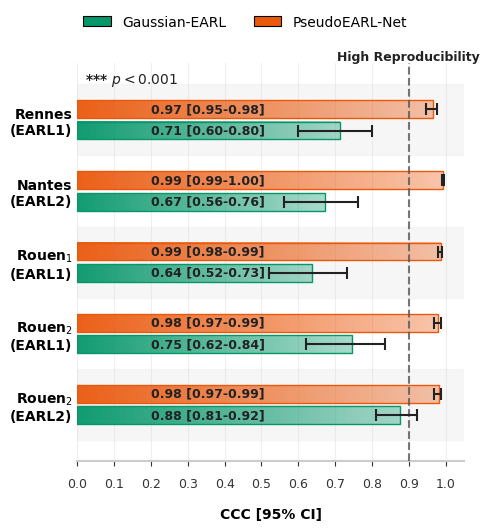

In [69]:
# plot_radiomics_ccc_master(df_centers_calculated, group_by='centers', text_fixed_x=0.2)

plot_radiomics_ccc_master(
    # df_families_calculated, 
    df_centers_calculated,
    group_by='families', 
    text_fixed_x=0.2,
    figsize=(5, 5.5),
    base_fontsize=10,
    bar_width=0.25,
    inter_bar_space=0.05,
    y_margin=0.8
)

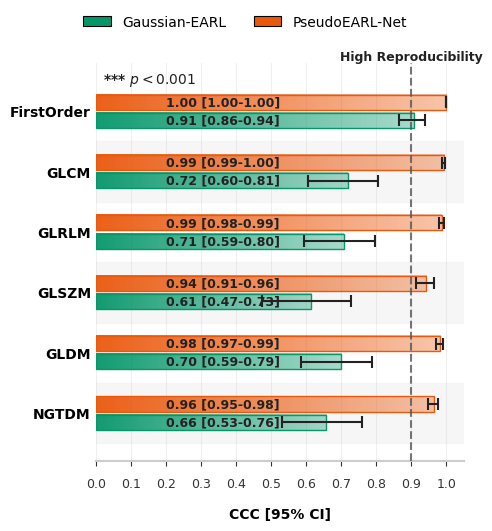

In [104]:
plot_radiomics_ccc_master(
    df_families_calculated, 
    group_by='families', 
    text_fixed_x=0.2,
    figsize=(5, 5.5),
    base_fontsize=10,
    bar_width=0.25,
    inter_bar_space=0.05,
    y_margin=0.8
)

In [68]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.gridspec import GridSpec


# (Garde toujours ta fonction calculate_ccc_and_ci définie ici)

def fetch_radiomics_heatmap_data_per_center(df, target_vois=['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    family_labels = ['First Order', 'GLCM', 'GLRLM', 'GLSZM', 'GLDM', 'NGTDM']
    
    # Identification de la colonne de domaine
    domain_col = 'Domain_Source' if 'Domain_Source' in df.columns else 'Domain'
    
    center_configs = [
        {'domain': 'rennes', 'suffix': '1'},
        {'domain': 'nantes', 'suffix': '2'},
        {'domain': 'chb', 'suffix': '1'},
        {'domain': 'a100', 'suffix': '1'},
        {'domain': 'a100', 'suffix': '2'}
    ]

    # --- 1. APPARIEMENT STRICT DES PATIENTS ---
    merged_pseudo_list = []
    merged_gauss_list = []
    
    for suffix in ['1', '2']:
        df_gt = df[df['Modality'].str.lower() == f'earl{suffix}'].copy()
        df_pseudo = df[df['Modality'].str.lower() == f'pseudo-earl{suffix}'].copy()
        df_gauss = df[df['Modality'].str.lower() == f'gaussian-earl{suffix}'].copy()
        
        m_pseudo = pd.merge(df_gt, df_pseudo, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred'))
        merged_pseudo_list.append(m_pseudo)
        
        m_gauss = pd.merge(df_gt, df_gauss, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred'))
        merged_gauss_list.append(m_gauss)
        
    merged_pseudo = pd.concat(merged_pseudo_list, ignore_index=True)
    merged_gauss = pd.concat(merged_gauss_list, ignore_index=True)
    
    # --- 2. CALCUL HIÉRARCHIQUE : VOI -> FAMILLE -> FEATURE -> CENTRE ---
    data_list = []
    
    for voi in target_vois:
        voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
        
        df_voi_pseudo = merged_pseudo[merged_pseudo['VOI'].str.lower() == voi_query]
        df_voi_gauss = merged_gauss[merged_gauss['VOI'].str.lower() == voi_query]
        
        for fam, fam_label in zip(families, family_labels):
            feat_cols = [c for c in df.columns if c.lower().startswith(f'original_{fam}_')]
            
            ccc_pseudo_features = []
            ccc_gauss_features = []
            
            for feat in feat_cols:
                ccc_pseudo_centers = []
                ccc_gauss_centers = []
                
                # ÉTAPE CLÉ : Calcul indépendant pour CHAQUE CENTRE
                for c_cfg in center_configs:
                    c_domain = c_cfg['domain']
                    c_earl = f"earl{c_cfg['suffix']}"
                    
                    # On isole les données de ce centre spécifique
                    subset_pseudo = df_voi_pseudo[(df_voi_pseudo[domain_col].str.lower() == c_domain) & 
                                                  (df_voi_pseudo['Modality_gt'].str.lower() == c_earl)]
                    subset_gauss = df_voi_gauss[(df_voi_gauss[domain_col].str.lower() == c_domain) & 
                                                (df_voi_gauss['Modality_gt'].str.lower() == c_earl)]
                    
                    # CCC PseudoEARL-Net (pour ce centre)
                    if f"{feat}_gt" in subset_pseudo.columns and f"{feat}_pred" in subset_pseudo.columns:
                        gt_vals = subset_pseudo[f"{feat}_gt"].dropna().values
                        pred_vals = subset_pseudo[f"{feat}_pred"].dropna().values
                        
                        if len(gt_vals) >= 3:
                            ccc_p, _, _, _ = calculate_ccc_and_ci(gt_vals, pred_vals)
                            if not np.isnan(ccc_p): ccc_pseudo_centers.append(ccc_p)
                    
                    # CCC Gaussian-EARL (pour ce centre)
                    if f"{feat}_gt" in subset_gauss.columns and f"{feat}_pred" in subset_gauss.columns:
                        gt_vals_g = subset_gauss[f"{feat}_gt"].dropna().values
                        pred_vals_g = subset_gauss[f"{feat}_pred"].dropna().values
                        
                        if len(gt_vals_g) >= 3:
                            ccc_g, _, _, _ = calculate_ccc_and_ci(gt_vals_g, pred_vals_g)
                            if not np.isnan(ccc_g): ccc_gauss_centers.append(ccc_g)
                
                # ÉTAPE CLÉ : On moyenne les centres pour avoir le CCC final de la Feature
                if ccc_pseudo_centers: ccc_pseudo_features.append(np.mean(ccc_pseudo_centers))
                if ccc_gauss_centers: ccc_gauss_features.append(np.mean(ccc_gauss_centers))
            
            # ÉTAPE CLÉ : On moyenne les Features pour avoir le CCC final de la Famille
            data_list.append({
                'Family': fam_label, 
                'VOI': voi.title(),
                'PseudoEARL-Net': np.mean(ccc_pseudo_features) if ccc_pseudo_features else np.nan,
                'Gaussian-EARL': np.mean(ccc_gauss_features) if ccc_gauss_features else np.nan
            })

    df_results = pd.DataFrame(data_list)
    
    # --- 3. CRÉATION DES MATRICES 2D ---
    heatmap_pseudo = df_results.pivot(index='Family', columns='VOI', values='PseudoEARL-Net')
    heatmap_gauss = df_results.pivot(index='Family', columns='VOI', values='Gaussian-EARL')
    
    heatmap_pseudo = heatmap_pseudo.reindex(index=family_labels, columns=[v.title() for v in target_vois])
    heatmap_gauss = heatmap_gauss.reindex(index=family_labels, columns=[v.title() for v in target_vois])
    
    return {'PseudoEARL-Net': heatmap_pseudo, 'Gaussian-EARL': heatmap_gauss}


# --- APPLICATION STRICTE DE LA CHARTE YAML ---
plt.style.use('default')

def plot_radiomics_ccc_heatmaps(heatmaps_dict, 
                                figsize=(16, 7), 
                                vmin=0.5,             # Borne basse de la couleur (0.5 ou 0.8 permet d'augmenter le contraste si les valeurs sont toutes > 0.8)
                                vmax=1.0,             # Borne haute (CCC parfait = 1.0)
                                cmap='YlGnBu',        # Dégradé : Jaune -> Vert -> Bleu 
                                annot_fontsize=12,    # Taille de la police du texte DANS les cases
                                wspace_val=0.05,      # Espace entre les deux heatmaps
                                cbar_width=0.03,      # Épaisseur de la barre de couleur (Colorbar)
                                cbar_pad=0.02,        # Espace entre la 2ème heatmap et la barre de couleur
                                linewidths=1.5,       # Épaisseur de la grille blanche entre les cases
                                base_fontsize=14):
    
    sns.set_context("paper", font_scale=1.)
    
    df_pseudo = heatmaps_dict['PseudoEARL-Net']
    df_gauss = heatmaps_dict['Gaussian-EARL']
    
    # --- 1. CRÉATION DE L'ARCHITECTURE (GridSpec) ---
    # On crée 3 colonnes : Heatmap 1, Heatmap 2, et Colorbar
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 3, width_ratios=[1, 1, cbar_width], wspace=wspace_val)
    
    ax_pseudo = fig.add_subplot(gs[0, 0])
    ax_gauss = fig.add_subplot(gs[0, 1])
    ax_cbar = fig.add_subplot(gs[0, 2])
    
    # --- 2. CONFIGURATION DES ANNOTATIONS ---
    annot_kws = {'fontsize': annot_fontsize, 'fontweight': 'bold'}
    
    # --- 3. TRACÉ DES HEATMAPS ---
    # Heatmap 1 : PseudoEARL-Net (Pas de cbar affichée ici)
    sns.heatmap(df_pseudo, ax=ax_pseudo, vmin=vmin, vmax=vmax, cmap=cmap, 
                annot=True, fmt='.2f', annot_kws=annot_kws, cbar=False,
                linewidths=linewidths, linecolor='white', square=True)
    
    # Heatmap 2 : Gaussian-EARL (La cbar est déportée sur ax_cbar)
    sns.heatmap(df_gauss, ax=ax_gauss, vmin=vmin, vmax=vmax, cmap=cmap, 
                annot=True, fmt='.2f', annot_kws=annot_kws, 
                cbar=True, cbar_ax=ax_cbar,
                linewidths=linewidths, linecolor='white', square=True)
    
    # --- 4. ESTHÉTIQUE DES AXES & TITRES ---
    panels = [
        {'ax': ax_pseudo, 'title': 'Proposed: PseudoEARL-Net', 'show_ylabel': True},
        {'ax': ax_gauss, 'title': 'Baseline: Gaussian-EARL', 'show_ylabel': False}
    ]
    
    for panel in panels:
        ax = panel['ax']
        
        # Titre
        ax.set_title(panel['title'], fontweight='bold', pad=15, fontsize=base_fontsize + 1)
        
        # Axe X (VOIs)
        # ax.set_xlabel("Volume of Interest (VOI)", fontweight='bold', labelpad=12, fontsize=base_fontsize)
        ax.set_xlabel("")
        ax.xaxis.set_tick_params(labelsize=base_fontsize - 1, labelrotation=0, colors='#333333')
        
        # Axe Y (Familles)
        if panel['show_ylabel']:
            ax.set_ylabel("Radiomics Feature Family", fontweight='bold', labelpad=12, fontsize=base_fontsize)
            ax.yaxis.set_tick_params(labelsize=base_fontsize - 1, labelrotation=0, colors='#333333')
        else:
            ax.set_ylabel("")
            ax.set_yticks([]) # Efface les ticks sur la 2ème heatmap pour que les 2 se "collent" proprement
            
        # On supprime les bordures noires disgracieuses autour de la heatmap
        for _, spine in ax.spines.items():
            spine.set_visible(False)

    # --- 5. ESTHÉTIQUE DE LA BARRE DE COULEUR ---
    ax_cbar.set_ylabel("CCC", fontweight='bold', labelpad=15, fontsize=base_fontsize)
    ax_cbar.yaxis.set_tick_params(labelsize=base_fontsize - 1)
    
    # Ajustement pour décoller la colorbar de la heatmap 2
    pos = ax_cbar.get_position()
    pos.x0 += cbar_pad
    pos.x1 += cbar_pad
    ax_cbar.set_position(pos)

    # Titre Global (Optionnel, au choix)
    # plt.suptitle("Radiomics Reproducibility (CCC) vs EARL Target", fontweight='bold', fontsize=base_fontsize + 3, y=1.02)
    
    plt.show()

# =========================================================
# EXÉCUTION
# =========================================================
# df_clone = master_df[master_df['Domain'].str.lower().isin(['nantes'])].copy()
# matrices_dict_strict = fetch_radiomics_heatmap_data_strict(df_clone)
matrices_dict = fetch_radiomics_heatmap_data_per_center(master_df)

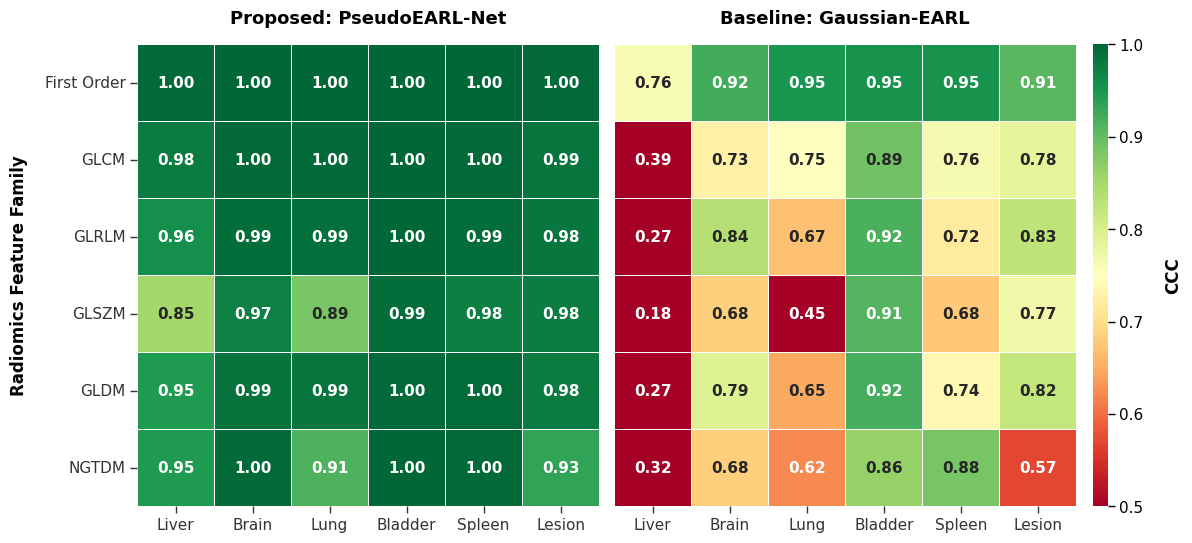

In [69]:
# Étape B : On affiche
# Si tes CCC sont tous très bons (ex: > 0.7), monte le vmin à 0.7 ! 
# Cela augmentera le contraste des couleurs.
#
plot_radiomics_ccc_heatmaps(
    matrices_dict, 
    vmin=0.5, 
    vmax=1.0, 
    cmap='RdYlGn',  # Dégradé : Rouge -> Jaune -> Vert
    wspace_val=0.00,  # Rapproche les deux blocs
    linewidths=0.5,
    figsize=(12.5, 6),
    annot_fontsize=11,
    base_fontsize=12,
    cbar_width=0.03,
    cbar_pad=0.0075
)

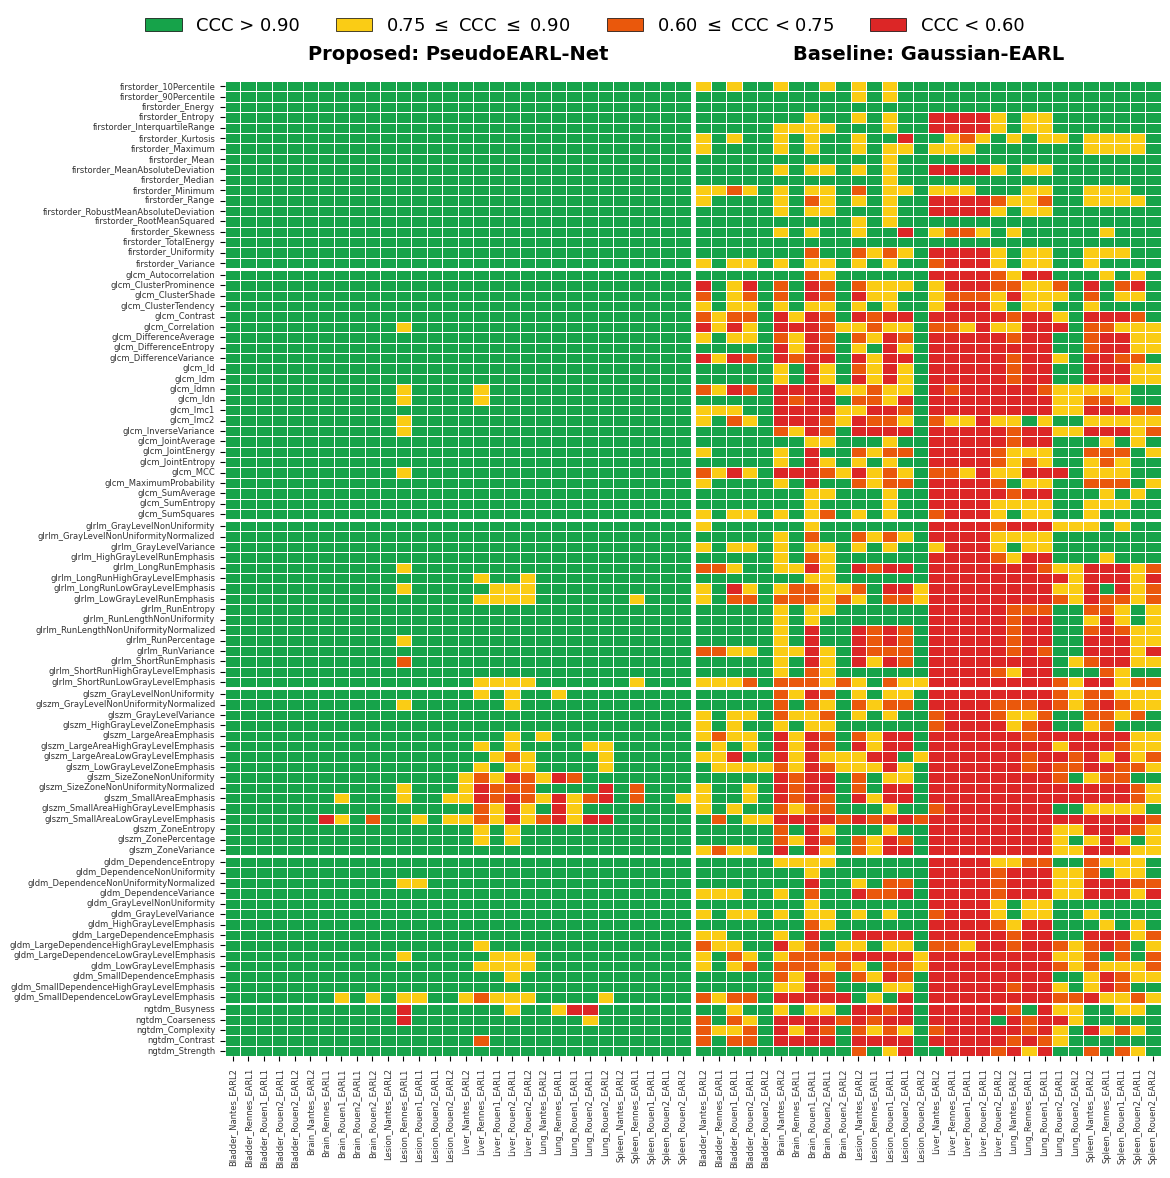

In [83]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def fetch_comprehensive_dual_heatmap_data(df, target_vois=['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    
    center_configs = [
        {'label': 'Rennes_EARL1', 'domain': 'rennes', 'suffix': '1'},
        {'label': 'Nantes_EARL2', 'domain': 'nantes', 'suffix': '2'},
        {'label': 'Rouen1_EARL1', 'domain': 'chb', 'suffix': '1'},
        {'label': 'Rouen2_EARL1', 'domain': 'a100', 'suffix': '1'},
        {'label': 'Rouen2_EARL2', 'domain': 'a100', 'suffix': '2'}
    ]
    
    domain_col = 'Domain_Source' if 'Domain_Source' in df.columns else 'Domain'
    
    merged_pseudo_list, merged_gauss_list = [], []
    for suffix in ['1', '2']:
        df_gt = df[df['Modality'].str.lower() == f'earl{suffix}'].copy()
        df_pseudo = df[df['Modality'].str.lower() == f'pseudo-earl{suffix}'].copy()
        df_gauss = df[df['Modality'].str.lower() == f'gaussian-earl{suffix}'].copy()
        
        merged_pseudo_list.append(pd.merge(df_gt, df_pseudo, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred')))
        merged_gauss_list.append(pd.merge(df_gt, df_gauss, on=['Subject_ID', 'VOI', domain_col], suffixes=('_gt', '_pred')))
        
    merged_p = pd.concat(merged_pseudo_list, ignore_index=True)
    merged_g = pd.concat(merged_gauss_list, ignore_index=True)
    
    all_features = [c for c in df.columns if c.startswith('original_') and 'shape' not in c.lower()]
    data_list = []
    
    for voi in target_vois:
        voi_query = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
        df_v_p = merged_p[merged_p['VOI'].str.lower() == voi_query]
        df_v_g = merged_g[merged_g['VOI'].str.lower() == voi_query]
        
        for c_cfg in center_configs:
            c_label = c_cfg['label']
            col_x_name = f"{voi.title()}_{c_label}"
            
            sub_p = df_v_p[(df_v_p[domain_col].str.lower() == c_cfg['domain']) & (df_v_p['Modality_gt'].str.lower() == f"earl{c_cfg['suffix']}")]
            sub_g = df_v_g[(df_v_g[domain_col].str.lower() == c_cfg['domain']) & (df_v_g['Modality_gt'].str.lower() == f"earl{c_cfg['suffix']}")]
            
            for feat in all_features:
                family = feat.split('_')[1]
                feature_display = feat.replace('original_', '')
                
                ccc_p, ccc_g = np.nan, np.nan
                if f"{feat}_gt" in sub_p.columns and f"{feat}_pred" in sub_p.columns:
                    gt, pred = sub_p[f"{feat}_gt"].dropna().values, sub_p[f"{feat}_pred"].dropna().values
                    if len(gt) >= 3: ccc_p, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        
                if f"{feat}_gt" in sub_g.columns and f"{feat}_pred" in sub_g.columns:
                    gt, pred = sub_g[f"{feat}_gt"].dropna().values, sub_g[f"{feat}_pred"].dropna().values
                    if len(gt) >= 3: ccc_g, _, _, _ = calculate_ccc_and_ci(gt, pred)
                
                data_list.append({
                    'Family': family, 'Feature_Y': feature_display, 'VOI_Center_X': col_x_name,
                    'CCC_Pseudo': ccc_p, 'CCC_Gauss': ccc_g
                })

    df_res = pd.DataFrame(data_list)
    matrix_p = df_res.pivot(index=['Family', 'Feature_Y'], columns='VOI_Center_X', values='CCC_Pseudo').sort_index(axis=1).reindex(families, level=0)
    matrix_g = df_res.pivot(index=['Family', 'Feature_Y'], columns='VOI_Center_X', values='CCC_Gauss').sort_index(axis=1).reindex(families, level=0)
    
    return {'PseudoEARL-Net': matrix_p, 'Gaussian-EARL': matrix_g}


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import numpy as np

def plot_dual_comprehensive_heatmap(matrices_dict, 
                                    figsize=None,          
                                    cell_width=0.3,        
                                    cell_height=0.18,      
                                    gap_between_families=0.08, 
                                    wspace_val=0.03,       
                                    label_fontsize=9,      
                                    title_fontsize=14,
                                    show_annotations=False):
    
    plt.style.use('default')
    
    matrix_p = matrices_dict['PseudoEARL-Net']
    matrix_g = matrices_dict['Gaussian-EARL']
    
    bounds = [-1.0, 0.6, 0.75, 0.9, 1.0] 
    colors = ['#dc2626', '#ea580c', '#facc15', '#16a34a'] 
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    families = matrix_p.index.get_level_values(0).unique()
    num_cols = matrix_p.shape[1]
    
    if figsize is None:
        total_height = (matrix_p.shape[0] * cell_height) + (len(families) * gap_between_families)
        total_width = (num_cols * cell_width) * 2 
        fig_width = total_width + 6.0  
        fig_height = total_height + 4.0
    else:
        fig_width, fig_height = figsize
        
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    height_ratios = [len(matrix_p.loc[fam]) for fam in families]
    gs = GridSpec(len(families), 2, height_ratios=height_ratios, hspace=gap_between_families, wspace=wspace_val)
    
    for i, fam in enumerate(families):
        ax_p = fig.add_subplot(gs[i, 0])
        ax_g = fig.add_subplot(gs[i, 1])
        
        df_fam_p = matrix_p.loc[fam]
        df_fam_g = matrix_g.loc[fam]
        
        sns.heatmap(df_fam_p, ax=ax_p, cmap=cmap, norm=norm, cbar=False, annot=show_annotations, square=False, linewidths=0.5, linecolor='white')
        sns.heatmap(df_fam_g, ax=ax_g, cmap=cmap, norm=norm, cbar=False, annot=show_annotations, square=False, linewidths=0.5, linecolor='white')
        
        if i == 0:
            ax_p.set_title("Proposed: PseudoEARL-Net", fontweight='bold', pad=15, fontsize=title_fontsize)
            ax_g.set_title("Baseline: Gaussian-EARL", fontweight='bold', pad=15, fontsize=title_fontsize)
            
        # --- CORRECTION DE L'AXE Y ---
        ax_p.set_ylabel("")
        ax_g.set_ylabel("")
        ax_g.set_yticks([]) 
        
        # On fige les positions (au centre des cases = +0.5) AVANT d'appliquer les textes
        ax_p.set_yticks(np.arange(len(df_fam_p.index)) + 0.5)
        ax_p.set_yticklabels(df_fam_p.index, rotation=0, fontsize=label_fontsize, fontweight='normal', color="#333333")
        
        # --- CORRECTION DE L'AXE X ---
        ax_p.set_xlabel("")
        ax_g.set_xlabel("")
        
        if i == len(families) - 1: 
            # On fige les positions X
            ax_p.set_xticks(np.arange(len(df_fam_p.columns)) + 0.5)
            ax_g.set_xticks(np.arange(len(df_fam_g.columns)) + 0.5)
            
            # On applique les textes
            ax_p.set_xticklabels(df_fam_p.columns, rotation=90, fontsize=label_fontsize, fontweight='normal', color="#333333")
            ax_g.set_xticklabels(df_fam_g.columns, rotation=90, fontsize=label_fontsize, fontweight='normal', color="#333333")
            
            ax_p.xaxis.set_tick_params(pad=5)
            ax_g.xaxis.set_tick_params(pad=5)
        else:
            ax_p.set_xticks([])
            ax_g.set_xticks([])
            
        for spine in list(ax_p.spines.values()) + list(ax_g.spines.values()):
            spine.set_visible(False)

    legend_elements = [
        Patch(facecolor='#16a34a', edgecolor='black', linewidth=0.5, label='CCC > 0.90'),
        Patch(facecolor='#facc15', edgecolor='black', linewidth=0.5, label='0.75 $\leq$ CCC $\leq$ 0.90'),
        Patch(facecolor='#ea580c', edgecolor='black', linewidth=0.5, label='0.60 $\leq$ CCC < 0.75'),
        Patch(facecolor='#dc2626', edgecolor='black', linewidth=0.5, label='CCC < 0.60')
    ]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.97), 
               ncol=4, frameon=False, fontsize=title_fontsize - 1)
    
    plt.subplots_adjust(bottom=0.18, top=0.91, left=0.20, right=0.98)
    plt.show()

ccc_matrices = fetch_comprehensive_dual_heatmap_data(master_df)

plot_dual_comprehensive_heatmap(
    ccc_matrices,
    cell_width=0.1,        
    cell_height=0.1,       
    gap_between_families=0.01,
    wspace_val=0.01,       
    label_fontsize=6
)


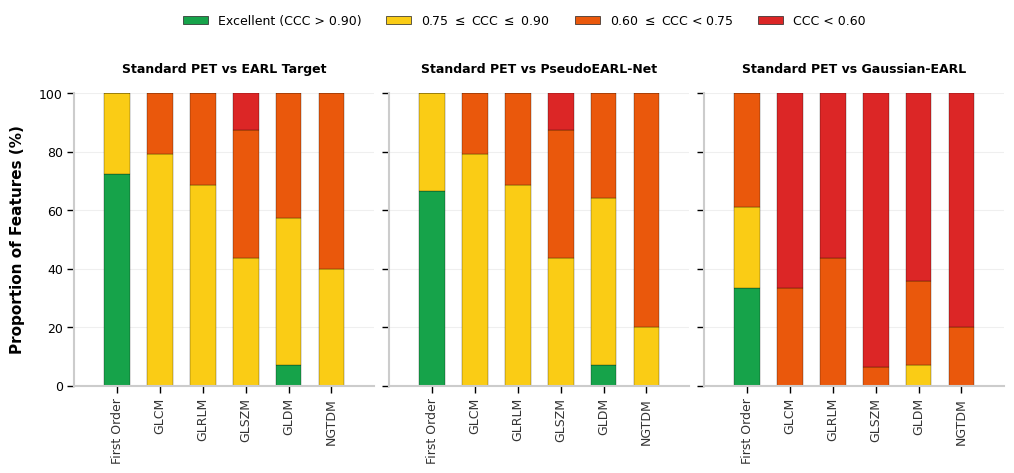

In [113]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# (Assure-toi que ta fonction calculate_ccc_and_ci est bien définie au-dessus)

def fetch_stacked_reproducibility_data(df, target_vois=['Liver', 'Brain', 'Lung', 'Bladder', 'Spleen', 'Lesion']):
    families = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
    family_labels = ['First Order', 'GLCM', 'GLRLM', 'GLSZM', 'GLDM', 'NGTDM']
    
    domain_col = 'Domain_Source' if 'Domain_Source' in df.columns else 'Domain'
    
    # Identification automatique de la modalité Standard
    std_mods = df[df['Modality'].str.lower().str.contains('standard')]['Modality'].unique()
    std_mod = std_mods[0] if len(std_mods) > 0 else 'Standard'
    
    center_configs = [
        {'domain': 'rennes', 'suffix': '1'},
        {'domain': 'nantes', 'suffix': '2'},
        {'domain': 'chb', 'suffix': '1'},
        {'domain': 'a100', 'suffix': '1'},
        {'domain': 'a100', 'suffix': '2'}
    ]
    
    comparisons = ['EARL', 'PseudoEARL-Net', 'Gaussian-EARL']
    all_features = [c for c in df.columns if c.startswith('original_') and 'shape' not in c.lower()]
    
    # Dictionnaire de stockage: {Comparaison: {Feature: [Liste de tous les CCC par VOI/Centre]}}
    ccc_store = {comp: {feat: [] for feat in all_features} for comp in comparisons}
    
    # 1. CALCUL DES CCC PAR FEATURE / VOI / CENTRE
    for voi in target_vois:
        voi_q = 'urinary_bladder' if voi.lower() == 'bladder' else voi.lower()
        
        for c_cfg in center_configs:
            c_domain = c_cfg['domain']
            c_suffix = c_cfg['suffix']
            
            # Isolement des données pour CE VOI et CE Centre
            df_std = df[(df['VOI'].str.lower() == voi_q) & (df[domain_col].str.lower() == c_domain) & (df['Modality'].str.lower() == std_mod.lower())]
            df_earl = df[(df['VOI'].str.lower() == voi_q) & (df[domain_col].str.lower() == c_domain) & (df['Modality'].str.lower() == f'earl{c_suffix}')]
            df_pseudo = df[(df['VOI'].str.lower() == voi_q) & (df[domain_col].str.lower() == c_domain) & (df['Modality'].str.lower() == f'pseudo-earl{c_suffix}')]
            df_gauss = df[(df['VOI'].str.lower() == voi_q) & (df[domain_col].str.lower() == c_domain) & (df['Modality'].str.lower() == f'gaussian-earl{c_suffix}')]
            
            if df_std.empty: continue
            
            # Appariement patient par patient
            m_earl = pd.merge(df_std, df_earl, on='Subject_ID', suffixes=('_std', '_comp')) if not df_earl.empty else pd.DataFrame()
            m_pseudo = pd.merge(df_std, df_pseudo, on='Subject_ID', suffixes=('_std', '_comp')) if not df_pseudo.empty else pd.DataFrame()
            m_gauss = pd.merge(df_std, df_gauss, on='Subject_ID', suffixes=('_std', '_comp')) if not df_gauss.empty else pd.DataFrame()
            
            for feat in all_features:
                col_std = f"{feat}_std"
                col_comp = f"{feat}_comp"
                
                if not m_earl.empty and col_std in m_earl.columns and col_comp in m_earl.columns:
                    gt, pred = m_earl[col_std].dropna().values, m_earl[col_comp].dropna().values
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store['EARL'][feat].append(ccc)
                        
                if not m_pseudo.empty and col_std in m_pseudo.columns and col_comp in m_pseudo.columns:
                    gt, pred = m_pseudo[col_std].dropna().values, m_pseudo[col_comp].dropna().values
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store['PseudoEARL-Net'][feat].append(ccc)
                        
                if not m_gauss.empty and col_std in m_gauss.columns and col_comp in m_gauss.columns:
                    gt, pred = m_gauss[col_std].dropna().values, m_gauss[col_comp].dropna().values
                    if len(gt) >= 3:
                        ccc, _, _, _ = calculate_ccc_and_ci(gt, pred)
                        if not np.isnan(ccc): ccc_store['Gaussian-EARL'][feat].append(ccc)
    
    # 2. MOYENNE ET RÉPARTITION EN % PAR FAMILLE
    final_data = []
    for comp in comparisons:
        for fam, fam_label in zip(families, family_labels):
            fam_features = [f for f in all_features if f.split('_')[1] == fam]
            
            excellent, good, moderate, mediocre = 0, 0, 0, 0
            total_valid_features = 0
            
            for feat in fam_features:
                vals = ccc_store[comp][feat]
                if len(vals) > 0:
                    mean_ccc = np.mean(vals) # Moyenne de la feature à travers les VOI/Centres
                    total_valid_features += 1
                    
                    if mean_ccc >= 0.90: excellent += 1
                    elif mean_ccc >= 0.75: good += 1
                    elif mean_ccc >= 0.60: moderate += 1
                    else: mediocre += 1
            
            if total_valid_features > 0:
                final_data.append({
                    'Comparison': comp,
                    'Family': fam_label,
                    'Excellent': (excellent / total_valid_features) * 100,
                    'Good': (good / total_valid_features) * 100,
                    'Moderate': (moderate / total_valid_features) * 100,
                    'Mediocre': (mediocre / total_valid_features) * 100
                })
                
    return pd.DataFrame(final_data)

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

plt.style.use('default')

def plot_reproducibility_stacked_bars(df_plot, 
                                      figsize=(14, 6),
                                      bar_width=0.2,            
                                      gap_between_bars=0.05,    
                                      bar_edgecolor='black',
                                      bar_linewidth=0.2,
                                      wspace_val=0.05,
                                      x_label_rotation=90,
                                      title_fontsize=13,
                                      label_fontsize=9,
                                      legend_fontsize=11):
    
    sns.set_context("paper", font_scale=1.1)
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    
    comparisons = ['EARL', 'PseudoEARL-Net', 'Gaussian-EARL']
    titles = ['Standard PET vs EARL Target', 'Standard PET vs PseudoEARL-Net', 'Standard PET vs Gaussian-EARL']
    
    tiers = ['Excellent', 'Good', 'Moderate', 'Mediocre']
    colors = ['#16a34a', '#facc15', '#ea580c', '#dc2626'] 
    
    # --- LA MAGIE EST ICI : Calcul du pas exact sur l'axe X ---
    x_step = bar_width + gap_between_bars
    
    for i, (comp, title) in enumerate(zip(comparisons, titles)):
        ax = axes[i]
        df_sub = df_plot[df_plot['Comparison'] == comp]
        
        if df_sub.empty:
            ax.axis('off')
            continue
            
        x_labels = df_sub['Family'].tolist()
        
        # On force les positions X à être rapprochées selon le pas calculé
        x = np.arange(len(x_labels)) * x_step
        bottom = np.zeros(len(x_labels))
        
        for tier, color in zip(tiers, colors):
            values = df_sub[tier].values
            ax.bar(x, values, bottom=bottom, color=color, 
                   edgecolor=bar_edgecolor, width=bar_width, linewidth=bar_linewidth)
            bottom += values 
            
        ax.set_title(title, fontweight='bold', pad=15, fontsize=title_fontsize)
        
        # Application des ticks sur les nouvelles positions X resserrées
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=x_label_rotation, 
                           fontsize=label_fontsize, fontweight='normal', color="#333333")
        
        # On coupe les marges latérales vides générées par le resserrement des barres
        ax.set_xlim(-x_step, x[-1] + x_step)
        ax.set_ylim(0, 100)
        
        if i == 0:
            ax.set_ylabel("Proportion of Features (%)", fontweight='bold', labelpad=10, fontsize=label_fontsize + 2)
            
        sns.despine(ax=ax, top=True, right=True, left=False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('#cccccc')
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('#cccccc')
        
        ax.tick_params(axis='y', labelsize=label_fontsize)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle='-', alpha=0.3, color='#cccccc')
        ax.xaxis.grid(False)

    legend_elements = [
        Patch(facecolor='#16a34a', edgecolor='#222222', linewidth=0.5, label='Excellent (CCC > 0.90)'),
        Patch(facecolor='#facc15', edgecolor='#222222', linewidth=0.5, label='0.75 $\leq$ CCC $\leq$ 0.90'),
        Patch(facecolor='#ea580c', edgecolor='#222222', linewidth=0.5, label='0.60 $\leq$ CCC < 0.75'),
        Patch(facecolor='#dc2626', edgecolor='#222222', linewidth=0.5, label='CCC < 0.60')
    ]
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
               ncol=4, frameon=False, fontsize=legend_fontsize)
    
    plt.subplots_adjust(bottom=0.20, top=0.85, wspace=wspace_val)
    plt.show()

df_stacked_data = fetch_stacked_reproducibility_data(master_df)
plot_reproducibility_stacked_bars(
    df_stacked_data,
    figsize=(12, 4.5),
    wspace_val=0.05,
    title_fontsize=9,
    label_fontsize=9,
    bar_edgecolor='black',
    bar_linewidth=.2,
    bar_width=0.015,
    x_label_rotation=90,
    gap_between_bars=0.01,
    legend_fontsize=9
)

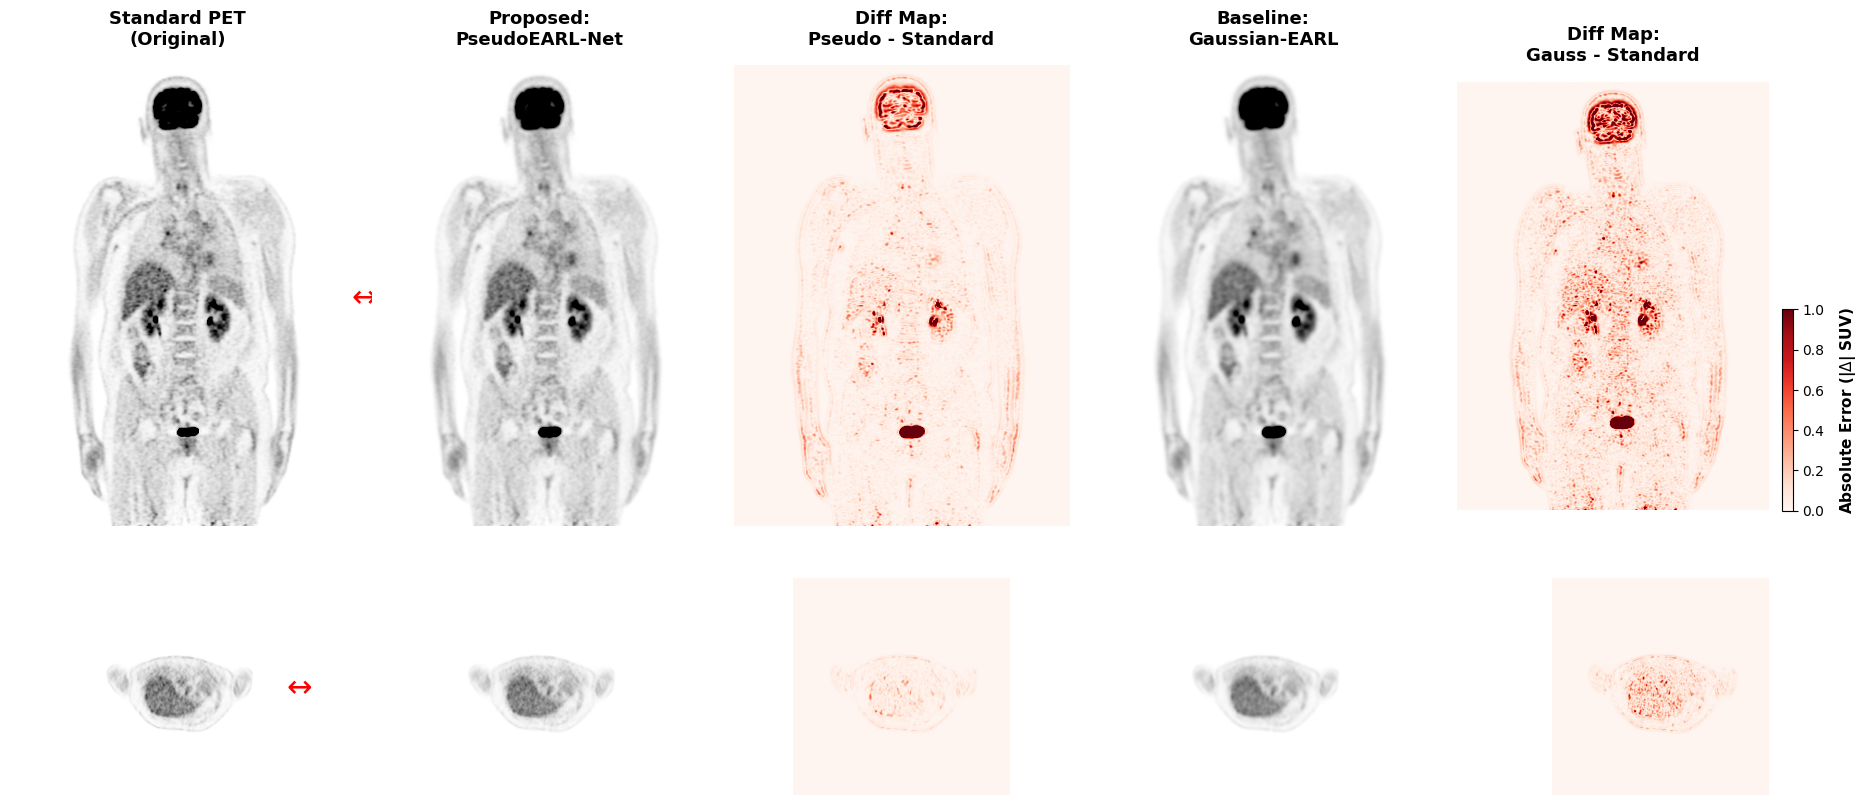

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import nibabel as nib

# --- APPLICATION DE LA CHARTE ---
plt.style.use('default')

def load_and_orient_volume(path_or_array):
    if isinstance(path_or_array, str):
        img = nib.load(path_or_array)
        return img.get_fdata()
    return path_or_array

def plot_pet_harmonization_panel(std_vol, pseudo_vol, gauss_vol, 
                                 coronal_idx, axial_idx, 
                                 figsize=(23, 10),      
                                 vmax_suv=5.0,          
                                 vmax_diff=None,
                                 absolute_diff=False,   # NOUVEAU : Erreur absolue
                                 show_profiles=True):   # NOUVEAU : Affichage des profils
    
    # 1. Chargement des données
    v_std = load_and_orient_volume(std_vol)
    v_pseudo = load_and_orient_volume(pseudo_vol)
    v_gauss = load_and_orient_volume(gauss_vol)
    
    # 2. Extraction des coupes
    cor_std = np.rot90(v_std[:, coronal_idx, :], k=1)
    cor_pseudo = np.rot90(v_pseudo[:, coronal_idx, :], k=1)
    cor_gauss = np.rot90(v_gauss[:, coronal_idx, :], k=1)
    
    ax_std = np.rot90(v_std[:, :, axial_idx], k=1)
    ax_pseudo = np.rot90(v_pseudo[:, :, axial_idx], k=1)
    ax_gauss = np.rot90(v_gauss[:, :, axial_idx], k=1)
    
    # 3. Calcul des matrices de différence (Signée ou Absolue)
    if absolute_diff:
        cor_diff_pseudo = np.abs(cor_pseudo - cor_std)
        ax_diff_pseudo = np.abs(ax_pseudo - ax_std)
        cor_diff_gauss = np.abs(cor_gauss - cor_std)
        ax_diff_gauss = np.abs(ax_gauss - ax_std)
        
        diff_cmap = 'Reds' # Dégradé Blanc -> Rouge pour l'erreur absolue
        vmin_diff = 0
        cbar_label = 'Absolute Error (|$\Delta$| SUV)'
    else:
        cor_diff_pseudo = cor_pseudo - cor_std
        ax_diff_pseudo = ax_pseudo - ax_std
        cor_diff_gauss = cor_gauss - cor_std
        ax_diff_gauss = ax_gauss - ax_std
        
        diff_cmap = 'bwr'  # Bleu -> Blanc -> Rouge pour l'erreur signée
        cbar_label = 'Error ($\Delta$ SUV)'
        
    # Gestion dynamique du VMAX de l'erreur
    if vmax_diff is None:
        all_diffs = np.concatenate([
            cor_diff_pseudo.flatten(), ax_diff_pseudo.flatten(),
            cor_diff_gauss.flatten(), ax_diff_gauss.flatten()
        ])
        vmax_diff = np.nanpercentile(np.abs(all_diffs), 99.9)
        if vmax_diff == 0: vmax_diff = 1.0 
        
    # Si non absolu, le vmin doit être symétrique
    if not absolute_diff:
        vmin_diff = -vmax_diff
    
    # --- GESTION DE L'ARCHITECTURE GRIDSPEC ---
    n_cols = 6 if show_profiles else 5
    width_ratios = [1.2, 2, 2, 2, 2, 2] if show_profiles else [2, 2, 2, 2, 2]
    img_col = 1 if show_profiles else 0 # Offset pour savoir où commencent les images
    
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, n_cols, width_ratios=width_ratios, height_ratios=[2.5, 1], wspace=0.08, hspace=0.03)
    
    axes = {}
    for i in range(2):
        for j in range(n_cols):
            axes[(i, j)] = fig.add_subplot(gs[i, j])

    pet_cmap = 'gray_r' 
    
    # --- LIGNE 0 : VUES CORONALES ---
    axes[(0, img_col)].imshow(cor_std, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(0, img_col+1)].imshow(cor_pseudo, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(0, img_col+2)].imshow(cor_diff_pseudo, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    axes[(0, img_col+3)].imshow(cor_gauss, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    im_diff = axes[(0, img_col+4)].imshow(cor_diff_gauss, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    
    # --- LIGNE 1 : VUES AXIALES ---
    axes[(1, img_col)].imshow(ax_std, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(1, img_col+1)].imshow(ax_pseudo, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(1, img_col+2)].imshow(ax_diff_pseudo, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    axes[(1, img_col+3)].imshow(ax_gauss, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(1, img_col+4)].imshow(ax_diff_gauss, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)

    # --- DESSIN DES PROFILS D'INTENSITÉ (SI ACTIVÉ) ---
    if show_profiles:
        color_std, color_pseudo, color_gauss = '#3b82f6', '#ef4444', '#10b981'
        
        # 1. Profil Coronal (Projection horizontale via axis=1)
        mip_cor_std = np.max(np.clip(cor_std, 0, vmax_suv), axis=1)
        mip_cor_pseudo = np.max(np.clip(cor_pseudo, 0, vmax_suv), axis=1)
        mip_cor_gauss = np.max(np.clip(cor_gauss, 0, vmax_suv), axis=1)
        y_axis_cor = np.arange(cor_std.shape[0])
        
        ax_pc = axes[(0, 0)]
        ax_pc.plot(mip_cor_std, y_axis_cor, color=color_std, linewidth=1.5, label='Standard')
        ax_pc.plot(mip_cor_pseudo, y_axis_cor, color=color_pseudo, linewidth=1.5, label='PseudoEARL')
        ax_pc.plot(mip_cor_gauss, y_axis_cor, color=color_gauss, linewidth=1.0, alpha=0.7, linestyle='--', label='Gaussian')
        ax_pc.set_title("Intensity Profile", fontweight='bold', fontsize=12)
        # Forçage mathématique de l'axe Y pour un alignement pixel perfect avec imshow
        ax_pc.set_ylim(cor_std.shape[0] - 0.5, -0.5) 
        ax_pc.legend(loc='lower left', frameon=False, fontsize=10)
        
        # 2. Profil Axial (Projection horizontale via axis=1 pour s'aligner sur la Y de l'image axiale)
        mip_ax_std = np.max(np.clip(ax_std, 0, vmax_suv), axis=1)
        mip_ax_pseudo = np.max(np.clip(ax_pseudo, 0, vmax_suv), axis=1)
        mip_ax_gauss = np.max(np.clip(ax_gauss, 0, vmax_suv), axis=1)
        y_axis_ax = np.arange(ax_std.shape[0])
        
        ax_pa = axes[(1, 0)]
        ax_pa.plot(mip_ax_std, y_axis_ax, color=color_std, linewidth=1.5)
        ax_pa.plot(mip_ax_pseudo, y_axis_ax, color=color_pseudo, linewidth=1.5)
        ax_pa.plot(mip_ax_gauss, y_axis_ax, color=color_gauss, linewidth=1.0, alpha=0.7, linestyle='--')
        ax_pa.set_xlabel("Max SUV", fontweight='bold', fontsize=10)
        # Forçage mathématique de l'axe Y
        ax_pa.set_ylim(ax_std.shape[0] - 0.5, -0.5)

    # --- ESTHÉTIQUE & NETTOYAGE ---
    titles = [
        "Standard PET\n(Original)", 
        "Proposed:\nPseudoEARL-Net", 
        "Diff Map:\nPseudo - Standard", 
        "Baseline:\nGaussian-EARL", 
        "Diff Map:\nGauss - Standard"
    ]
    
    for j in range(5):
        axes[(0, img_col + j)].set_title(titles[j], fontweight='bold', pad=15, fontsize=13)
        
    for i in range(2):
        for j in range(n_cols):
            ax = axes[(i, j)]
            if j >= img_col: 
                ax.axis('off') 
            elif show_profiles: 
                # Nettoyage des axes de profils
                if i == 0: ax.set_xticks([]) # Cache les valeurs SUV en haut pour ne les garder qu'en bas
                ax.set_yticks([]) 
                for spine in ax.spines.values():
                    spine.set_linewidth(1.2)
                    spine.set_color('#333333')
    
    # --- FLÈCHES ROUGES ---
    arrow_kwargs = dict(color='red', fontsize=22, fontweight='bold', ha='center', va='center')
    axes[(0, img_col)].text(1.05, 0.5, r'$\leftrightarrow$', transform=axes[(0, img_col)].transAxes, **arrow_kwargs)
    axes[(1, img_col)].text(1.05, 0.5, r'$\leftrightarrow$', transform=axes[(1, img_col)].transAxes, **arrow_kwargs)

    # --- BARRE DE COULEUR (COLORBAR) ---
    cbar = fig.colorbar(im_diff, ax=[axes[(0, img_col+4)], axes[(1, img_col+4)]], 
                        fraction=0.03, pad=0.04, shrink=0.8)
    cbar.set_label(cbar_label, fontweight='bold', fontsize=11, labelpad=10)
    cbar.ax.tick_params(labelsize=10)

    plt.show()


plot_pet_harmonization_panel(
    std_vol='../data/PET-EARL/domain_rennes/GQz9nY6LSG2GNcbDnPWWsi/PET_TEP_TAP_AC.nii.gz', 
    pseudo_vol='../data/PET-EARL/domain_rennes/GQz9nY6LSG2GNcbDnPWWsi/pseudo-earl1.nii.gz', 
    gauss_vol='../data/PET-EARL/domain_rennes/GQz9nY6LSG2GNcbDnPWWsi/gaussian-earl1.nii.gz',
    coronal_idx=200, 
    axial_idx=300,   
    vmax_suv=5.0,
    vmax_diff=1.0,           
    absolute_diff=True,
    show_profiles=False
)

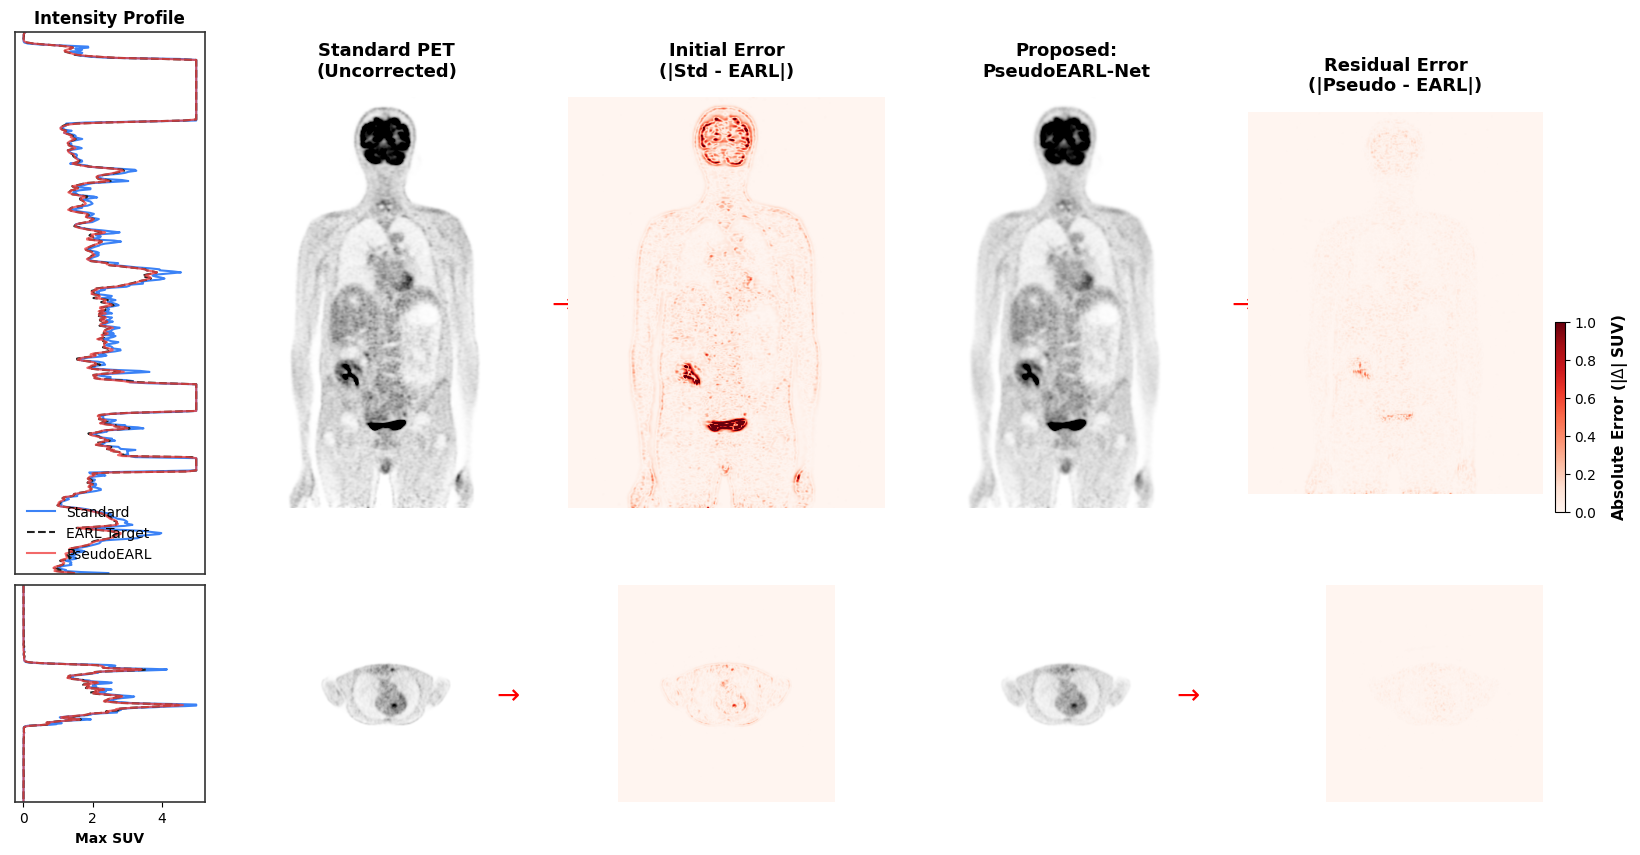

In [151]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import nibabel as nib

# --- APPLICATION DE LA CHARTE ---
plt.style.use('default')

def load_and_orient_volume(path_or_array):
    if isinstance(path_or_array, str):
        img = nib.load(path_or_array)
        return img.get_fdata()
    return path_or_array

def plot_pet_error_reduction_panel(std_vol, earl_vol, pseudo_vol, 
                                   coronal_idx, axial_idx, 
                                   figsize=(20, 10),      
                                   vmax_suv=5.0,          
                                   vmax_diff=None,
                                   absolute_diff=True,    # Par défaut en erreur absolue (très visuel)
                                   show_profiles=True):   
    
    # 1. Chargement des données
    v_std = load_and_orient_volume(std_vol)
    v_earl = load_and_orient_volume(earl_vol)     # La vérité terrain cible
    v_pseudo = load_and_orient_volume(pseudo_vol) # La prédiction du modèle
    
    # 2. Extraction des coupes (Rotation pour alignement)
    cor_std = np.rot90(v_std[:, coronal_idx, :], k=1)
    cor_earl = np.rot90(v_earl[:, coronal_idx, :], k=1)
    cor_pseudo = np.rot90(v_pseudo[:, coronal_idx, :], k=1)
    
    ax_std = np.rot90(v_std[:, :, axial_idx], k=1)
    ax_earl = np.rot90(v_earl[:, :, axial_idx], k=1)
    ax_pseudo = np.rot90(v_pseudo[:, :, axial_idx], k=1)
    
    # 3. Calcul des matrices d'erreur (Standard vs EARL) et (Pseudo vs EARL)
    if absolute_diff:
        cor_err_std = np.abs(cor_std - cor_earl)
        ax_err_std = np.abs(ax_std - ax_earl)
        cor_err_pseudo = np.abs(cor_pseudo - cor_earl)
        ax_err_pseudo = np.abs(ax_pseudo - ax_earl)
        
        diff_cmap = 'Reds'
        vmin_diff = 0
        cbar_label = 'Absolute Error (|$\Delta$| SUV)'
        err_str_std = "|Std - EARL|"
        err_str_pseudo = "|Pseudo - EARL|"
    else:
        cor_err_std = cor_std - cor_earl
        ax_err_std = ax_std - ax_earl
        cor_err_pseudo = cor_pseudo - cor_earl
        ax_err_pseudo = ax_pseudo - ax_earl
        
        diff_cmap = 'bwr'
        cbar_label = 'Error ($\Delta$ SUV)'
        err_str_std = "Std - EARL"
        err_str_pseudo = "Pseudo - EARL"
        
    # Gestion dynamique du VMAX de l'erreur
    if vmax_diff is None:
        all_diffs = np.concatenate([
            cor_err_std.flatten(), ax_err_std.flatten(),
            cor_err_pseudo.flatten(), ax_err_pseudo.flatten()
        ])
        vmax_diff = np.nanpercentile(np.abs(all_diffs), 99.9)
        if vmax_diff == 0: vmax_diff = 1.0 
        
    if not absolute_diff:
        vmin_diff = -vmax_diff
    
    # --- GESTION DE L'ARCHITECTURE GRIDSPEC ---
    n_cols = 5 if show_profiles else 4
    width_ratios = [1.2, 2, 2, 2, 2] if show_profiles else [2, 2, 2, 2]
    img_col = 1 if show_profiles else 0
    
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, n_cols, width_ratios=width_ratios, height_ratios=[2.5, 1], wspace=0.08, hspace=0.03)
    
    axes = {}
    for i in range(2):
        for j in range(n_cols):
            axes[(i, j)] = fig.add_subplot(gs[i, j])

    pet_cmap = 'gray_r' 
    
    # --- LIGNE 0 : VUES CORONALES ---
    axes[(0, img_col)].imshow(cor_std, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(0, img_col+1)].imshow(cor_err_std, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    axes[(0, img_col+2)].imshow(cor_pseudo, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    im_diff = axes[(0, img_col+3)].imshow(cor_err_pseudo, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    
    # --- LIGNE 1 : VUES AXIALES ---
    axes[(1, img_col)].imshow(ax_std, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(1, img_col+1)].imshow(ax_err_std, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)
    axes[(1, img_col+2)].imshow(ax_pseudo, cmap=pet_cmap, vmin=0, vmax=vmax_suv)
    axes[(1, img_col+3)].imshow(ax_err_pseudo, cmap=diff_cmap, vmin=vmin_diff, vmax=vmax_diff)

    # --- DESSIN DES PROFILS D'INTENSITÉ ---
    if show_profiles:
        # On remplace le Gaussien par la Target EARL (Noir pointillé)
        color_std, color_pseudo, color_earl = '#3b82f6', '#ef4444', '#222222'
        
        # Profil Coronal
        mip_cor_std = np.max(np.clip(cor_std, 0, vmax_suv), axis=1)
        mip_cor_pseudo = np.max(np.clip(cor_pseudo, 0, vmax_suv), axis=1)
        mip_cor_earl = np.max(np.clip(cor_earl, 0, vmax_suv), axis=1)
        y_axis_cor = np.arange(cor_std.shape[0])
        
        ax_pc = axes[(0, 0)]
        ax_pc.plot(mip_cor_std, y_axis_cor, color=color_std, linewidth=1.5, label='Standard')
        ax_pc.plot(mip_cor_earl, y_axis_cor, color=color_earl, linewidth=1.5, linestyle='--', label='EARL Target')
        ax_pc.plot(mip_cor_pseudo, y_axis_cor, color=color_pseudo, linewidth=1.5, alpha=0.8, label='PseudoEARL')
        
        ax_pc.set_title("Intensity Profile", fontweight='bold', fontsize=12)
        ax_pc.set_ylim(cor_std.shape[0] - 0.5, -0.5) 
        ax_pc.legend(loc='lower left', frameon=False, fontsize=10)
        
        # Profil Axial 
        mip_ax_std = np.max(np.clip(ax_std, 0, vmax_suv), axis=1)
        mip_ax_pseudo = np.max(np.clip(ax_pseudo, 0, vmax_suv), axis=1)
        mip_ax_earl = np.max(np.clip(ax_earl, 0, vmax_suv), axis=1)
        y_axis_ax = np.arange(ax_std.shape[0])
        
        ax_pa = axes[(1, 0)]
        ax_pa.plot(mip_ax_std, y_axis_ax, color=color_std, linewidth=1.5)
        ax_pa.plot(mip_ax_earl, y_axis_ax, color=color_earl, linewidth=1.5, linestyle='--')
        ax_pa.plot(mip_ax_pseudo, y_axis_ax, color=color_pseudo, linewidth=1.5, alpha=0.8)
        
        ax_pa.set_xlabel("Max SUV", fontweight='bold', fontsize=10)
        ax_pa.set_ylim(ax_std.shape[0] - 0.5, -0.5)

    # --- ESTHÉTIQUE & NETTOYAGE ---
    titles = [
        "Standard PET\n(Uncorrected)", 
        f"Initial Error\n({err_str_std})", 
        "Proposed:\nPseudoEARL-Net", 
        f"Residual Error\n({err_str_pseudo})"
    ]
    
    for j in range(4):
        axes[(0, img_col + j)].set_title(titles[j], fontweight='bold', pad=15, fontsize=13)
        
    for i in range(2):
        for j in range(n_cols):
            ax = axes[(i, j)]
            if j >= img_col: 
                ax.axis('off') 
            elif show_profiles: 
                if i == 0: ax.set_xticks([]) 
                ax.set_yticks([]) 
                for spine in ax.spines.values():
                    spine.set_linewidth(1.2)
                    spine.set_color('#333333')
    
    # --- FLÈCHES ROUGES DE PROGRESSION ---
    arrow_kwargs = dict(color='red', fontsize=20, fontweight='bold', ha='center', va='center')
    axes[(0, img_col)].text(1.05, 0.5, r'$\rightarrow$', transform=axes[(0, img_col)].transAxes, **arrow_kwargs)
    axes[(1, img_col)].text(1.05, 0.5, r'$\rightarrow$', transform=axes[(1, img_col)].transAxes, **arrow_kwargs)
    
    axes[(0, img_col+2)].text(1.05, 0.5, r'$\rightarrow$', transform=axes[(0, img_col+2)].transAxes, **arrow_kwargs)
    axes[(1, img_col+2)].text(1.05, 0.5, r'$\rightarrow$', transform=axes[(1, img_col+2)].transAxes, **arrow_kwargs)

    # --- BARRE DE COULEUR (COLORBAR) ---
    cbar = fig.colorbar(im_diff, ax=[axes[(0, img_col+3)], axes[(1, img_col+3)]], 
                        fraction=0.03, pad=0.04, shrink=0.8)
    cbar.set_label(cbar_label, fontweight='bold', fontsize=11, labelpad=10)
    cbar.ax.tick_params(labelsize=10)

    plt.show()

plot_pet_error_reduction_panel(
    std_vol='../data/PET-EARL/domain_rennes/2ybL92aNCnoQcHxamqh4r8/PET_TEP_TAP_AC.nii.gz', 
    earl_vol='../data/PET-EARL/domain_rennes/2ybL92aNCnoQcHxamqh4r8/EARL_TEP_TAP_EARL.nii.gz',       # La Target
    pseudo_vol='../data/PET-EARL/domain_rennes/2ybL92aNCnoQcHxamqh4r8/pseudo-earl1.nii.gz',
    coronal_idx=200, 
    axial_idx=300,   
    vmax_suv=5.0,
    vmax_diff=1,           
    absolute_diff=True,      # Affiche l'effacement de l'erreur en Rouge -> Blanc
    show_profiles=True       
)

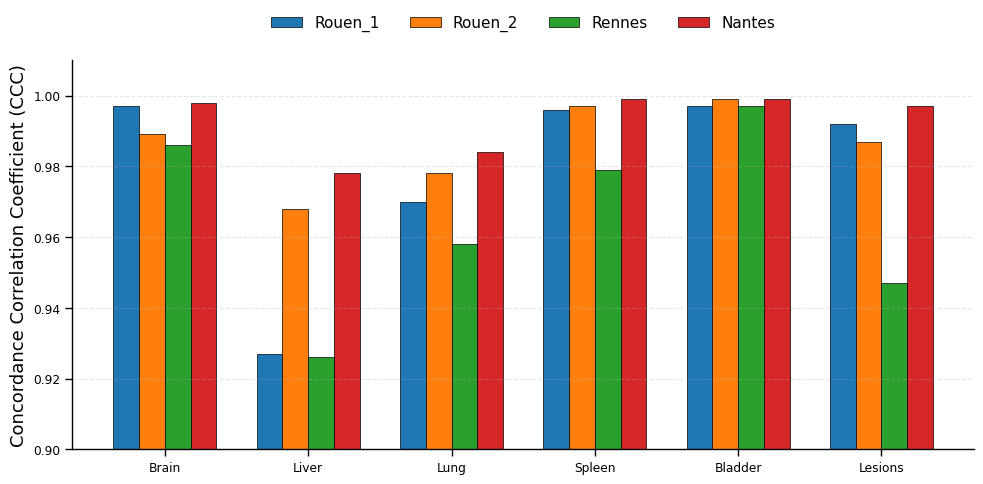

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# REPLACE WITH YOUR DATA
# ------------------------------------------------------------------

vois = ["Brain", "Liver", "Lung", "Spleen", "Bladder", "Lesions"]

data = {
    "Rouen_1": [0.997, 0.927, 0.970, 0.996, 0.997, 0.992],
    "Rouen_2": [0.989, 0.968, 0.978, 0.997, 0.999, 0.987],
    "Rennes":  [0.986, 0.926, 0.958, 0.979, 0.997, 0.947],
    "Nantes":  [0.998, 0.978, 0.984, 0.999, 0.999, 0.997]
}

df = pd.DataFrame(data, index=vois)

# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(vois))
width = 0.18

for i, center in enumerate(df.columns):
    ax.bar(
        x + (i - 1.5) * width,
        df[center],
        width=width,
        label=center,
        edgecolor="black",
        linewidth=0.5
    )

ax.set_xticks(x)
ax.set_xticklabels(vois)

ax.set_ylabel("Concordance Correlation Coefficient (CCC)")
ax.set_ylim(0.90, 1.01)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15)
)

plt.tight_layout()
plt.show()

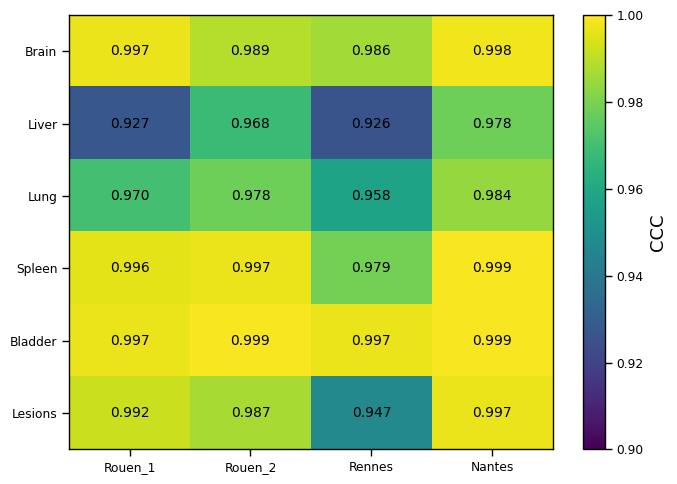

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Rouen_1":[0.997,0.927,0.970,0.996,0.997,0.992],
    "Rouen_2":[0.989,0.968,0.978,0.997,0.999,0.987],
    "Rennes":[0.986,0.926,0.958,0.979,0.997,0.947],
    "Nantes":[0.998,0.978,0.984,0.999,0.999,0.997]
},
index=["Brain","Liver","Lung","Spleen","Bladder","Lesions"])

fig, ax = plt.subplots(figsize=(7,5))

im = ax.imshow(
    df,
    aspect="auto",
    vmin=0.90,
    vmax=1.00
)

ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns)

ax.set_yticks(range(len(df.index)))
ax.set_yticklabels(df.index)

for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        ax.text(
            j,
            i,
            f"{df.iloc[i,j]:.3f}",
            ha="center",
            va="center",
            fontsize=10
        )

cbar = plt.colorbar(im)
cbar.set_label("CCC")

plt.tight_layout()
plt.show()

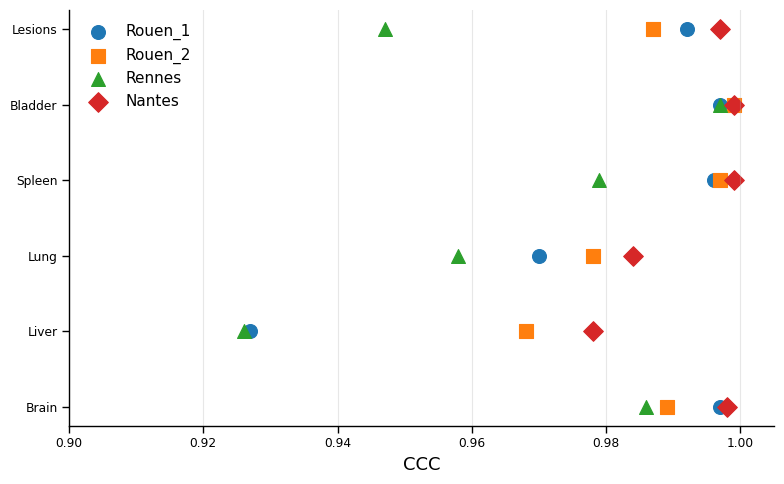

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Rouen_1":[0.997,0.927,0.970,0.996,0.997,0.992],
    "Rouen_2":[0.989,0.968,0.978,0.997,0.999,0.987],
    "Rennes":[0.986,0.926,0.958,0.979,0.997,0.947],
    "Nantes":[0.998,0.978,0.984,0.999,0.999,0.997]
},
index=["Brain","Liver","Lung","Spleen","Bladder","Lesions"])

fig, ax = plt.subplots(figsize=(8,5))

markers = ["o","s","^","D"]

for marker, center in zip(markers, df.columns):
    ax.scatter(
        df[center],
        df.index,
        s=100,
        marker=marker,
        label=center
    )

ax.set_xlim(0.90,1.005)
ax.set_xlabel("CCC")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="x", alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

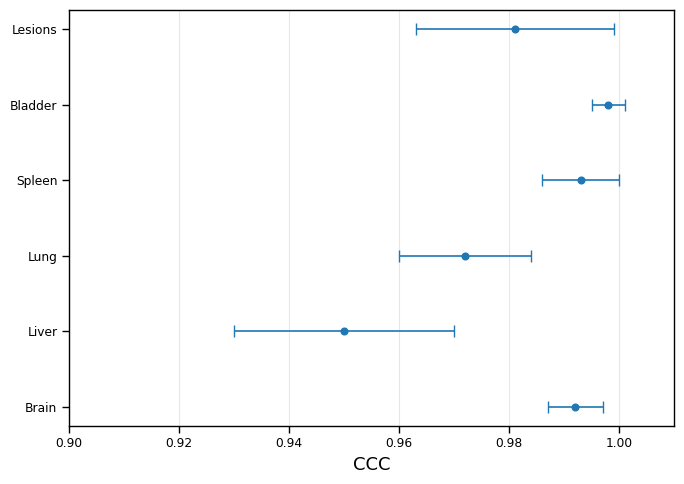

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vois = ["Brain","Liver","Lung","Spleen","Bladder","Lesions"]

mean_ccc = [0.992,0.950,0.972,0.993,0.998,0.981]
sd_ccc = [0.005,0.020,0.012,0.007,0.003,0.018]

fig, ax = plt.subplots(figsize=(7,5))

y = np.arange(len(vois))

ax.errorbar(
    mean_ccc,
    y,
    xerr=sd_ccc,
    fmt='o',
    capsize=4
)

ax.set_yticks(y)
ax.set_yticklabels(vois)

ax.set_xlabel("CCC")
ax.set_xlim(0.90,1.01)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

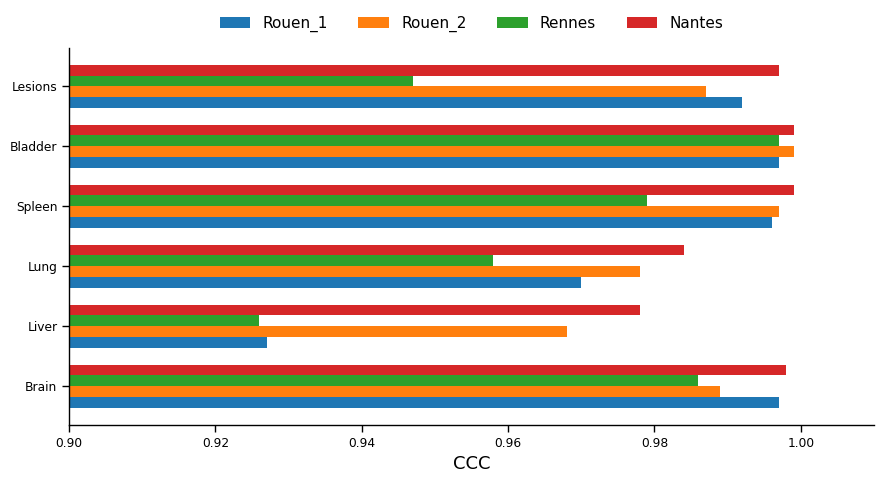

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Rouen_1":[0.997,0.927,0.970,0.996,0.997,0.992],
    "Rouen_2":[0.989,0.968,0.978,0.997,0.999,0.987],
    "Rennes":[0.986,0.926,0.958,0.979,0.997,0.947],
    "Nantes":[0.998,0.978,0.984,0.999,0.999,0.997]
},
index=["Brain","Liver","Lung","Spleen","Bladder","Lesions"])

fig, ax = plt.subplots(figsize=(9,5))

y = np.arange(len(df.index))
h = 0.18

for i, center in enumerate(df.columns):
    ax.barh(
        y + (i-1.5)*h,
        df[center],
        height=h,
        label=center
    )

ax.set_yticks(y)
ax.set_yticklabels(df.index)

ax.set_xlim(0.90,1.01)

ax.set_xlabel("CCC")

ax.legend(
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,1.12),
    loc="upper center"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

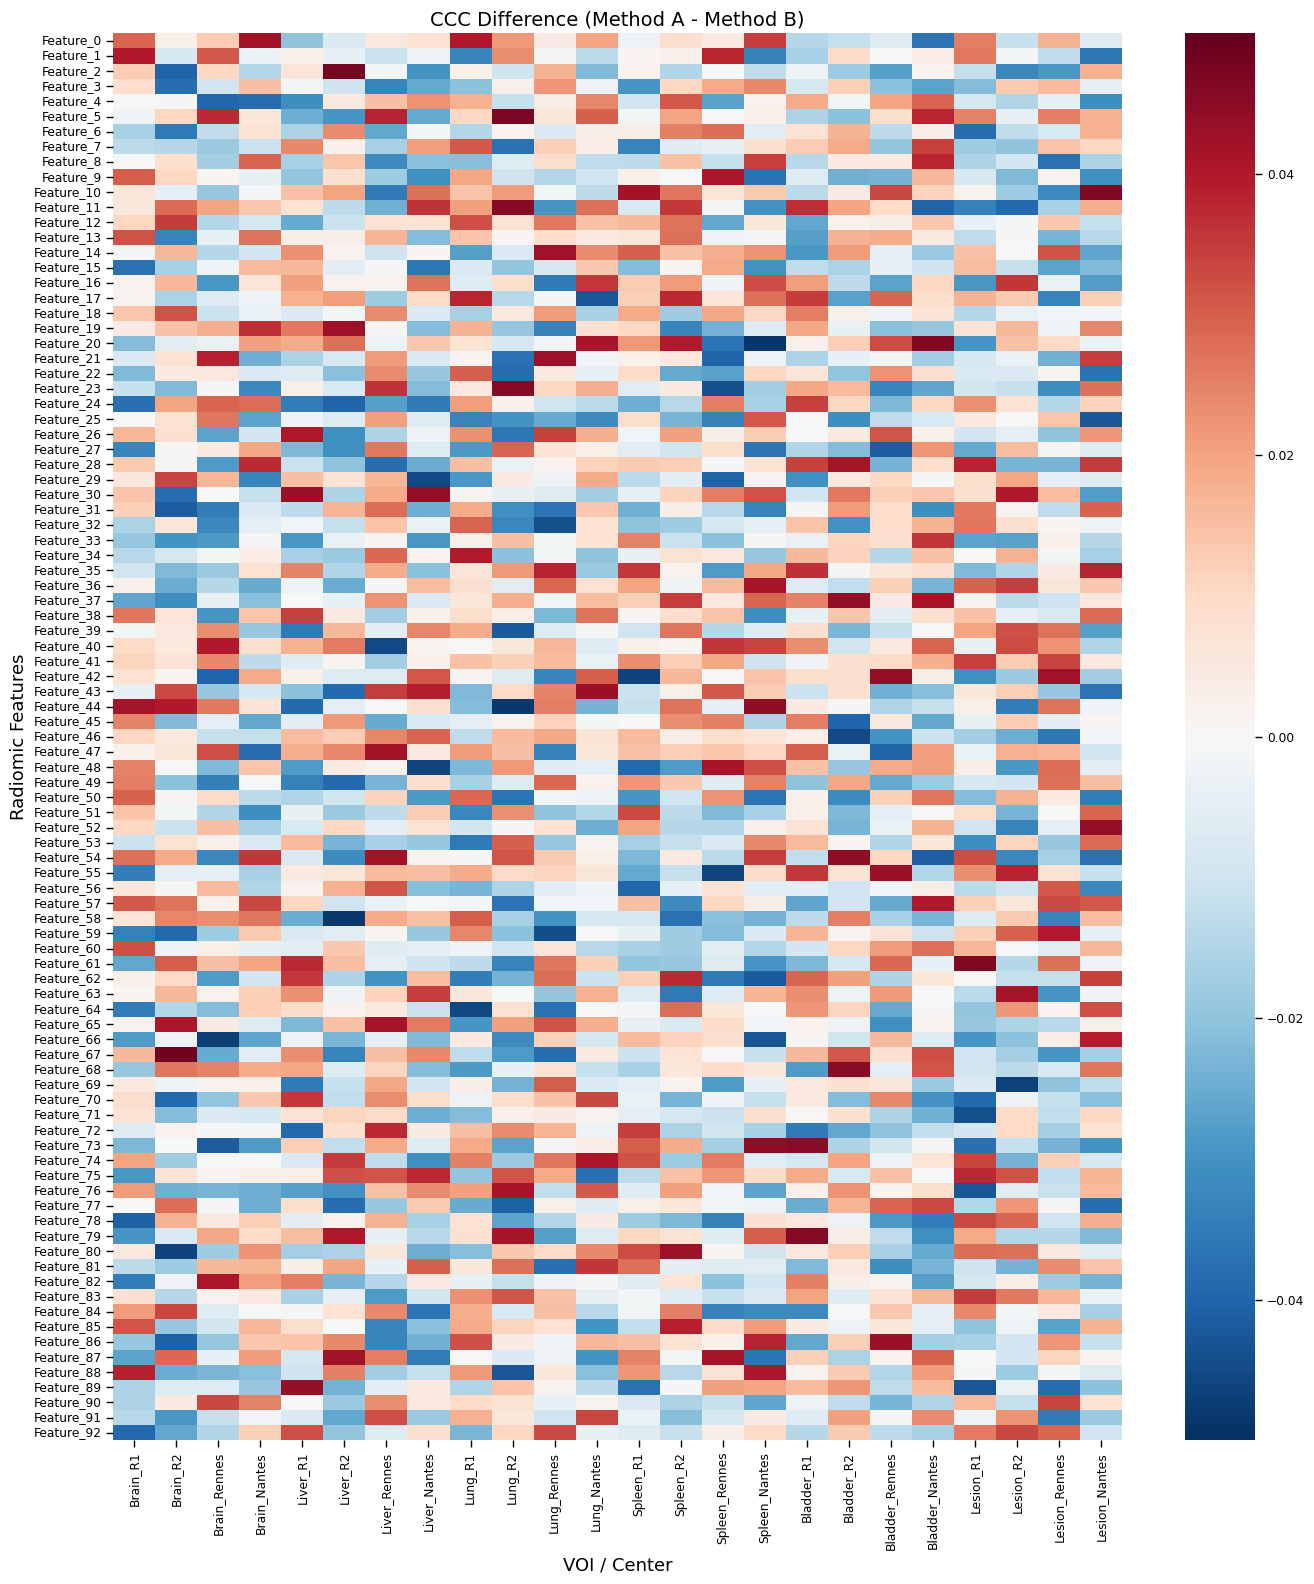

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Example
# ----------------------------------------------------

features = [f"Feature_{i}" for i in range(93)]

columns = [
    "Brain_R1","Brain_R2","Brain_Rennes","Brain_Nantes",
    "Liver_R1","Liver_R2","Liver_Rennes","Liver_Nantes",
    "Lung_R1","Lung_R2","Lung_Rennes","Lung_Nantes",
    "Spleen_R1","Spleen_R2","Spleen_Rennes","Spleen_Nantes",
    "Bladder_R1","Bladder_R2","Bladder_Rennes","Bladder_Nantes",
    "Lesion_R1","Lesion_R2","Lesion_Rennes","Lesion_Nantes"
]

# CCC of your method
ccc_method_A = pd.DataFrame(
    0.95 + 0.05*np.random.rand(93,24),
    index=features,
    columns=columns
)

# CCC of reference method
ccc_method_B = pd.DataFrame(
    0.95 + 0.05*np.random.rand(93,24),
    index=features,
    columns=columns
)

delta = ccc_method_A - ccc_method_B

plt.figure(figsize=(14,16))

sns.heatmap(
    delta,
    cmap="RdBu_r",
    center=0,
    vmin=-0.05,
    vmax=0.05
)

plt.title("CCC Difference (Method A - Method B)")
plt.xlabel("VOI / Center")
plt.ylabel("Radiomic Features")

plt.tight_layout()
plt.show()

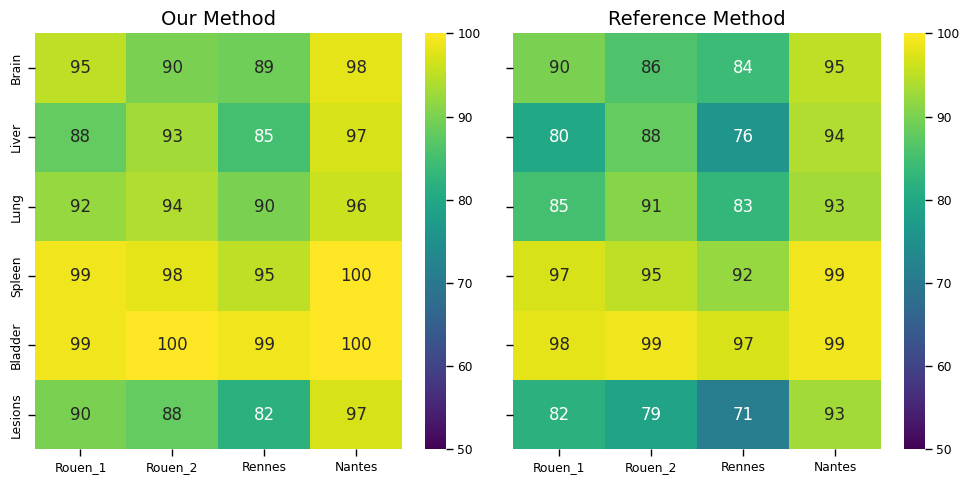

In [ ]:
# percentage_features_ccc90 = (
#     df
#     .groupby(["Method","VOI","Center"])
#     ["CCC"]
#     .apply(lambda x: (x > 0.90).mean()*100)
# )

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example
data_A = pd.DataFrame({
    "Rouen_1":[95,88,92,99,99,90],
    "Rouen_2":[90,93,94,98,100,88],
    "Rennes":[89,85,90,95,99,82],
    "Nantes":[98,97,96,100,100,97]
},
index=["Brain","Liver","Lung","Spleen","Bladder","Lesions"])

data_B = pd.DataFrame({
    "Rouen_1":[90,80,85,97,98,82],
    "Rouen_2":[86,88,91,95,99,79],
    "Rennes":[84,76,83,92,97,71],
    "Nantes":[95,94,93,99,99,93]
},
index=data_A.index)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10,5),
    sharey=True
)

sns.heatmap(
    data_A,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    vmin=50,
    vmax=100,
    ax=axes[0]
)

axes[0].set_title("Our Method")

sns.heatmap(
    data_B,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    vmin=50,
    vmax=100,
    ax=axes[1]
)

axes[1].set_title("Reference Method")

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# 1. Données hardcodées extraites des tableaux fournis
data = [
    # === GROUPE EARL1 (a100, chb, Rennes) ===
    # a100 (Rouen 1) - EARL1
    {"centre": "a100", "standard": "EARL1", "voi": "BRAIN", "aRE": 0.67, "PSNR": 48.12},
    {"centre": "a100", "standard": "EARL1", "voi": "LIVER", "aRE": 0.42, "PSNR": 46.48},
    {"centre": "a100", "standard": "EARL1", "voi": "LUNG", "aRE": 0.83, "PSNR": 44.92},
    {"centre": "a100", "standard": "EARL1", "voi": "SPLEEN", "aRE": 0.57, "PSNR": 47.86},
    {"centre": "a100", "standard": "EARL1", "voi": "BLADDER", "aRE": 1.11, "PSNR": 48.25},
    {"centre": "a100", "standard": "EARL1", "voi": "LESIONS", "aRE": 1.02, "PSNR": 42.88},
    
    # chb (Rouen 2) - EARL1
    {"centre": "chb", "standard": "EARL1", "voi": "BRAIN", "aRE": 0.88, "PSNR": 45.31},
    {"centre": "chb", "standard": "EARL1", "voi": "LIVER", "aRE": 0.27, "PSNR": 51.78},
    {"centre": "chb", "standard": "EARL1", "voi": "LUNG", "aRE": 0.39, "PSNR": 51.45},
    {"centre": "chb", "standard": "EARL1", "voi": "SPLEEN", "aRE": 0.28, "PSNR": 55.39},
    {"centre": "chb", "standard": "EARL1", "voi": "BLADDER", "aRE": 0.55, "PSNR": 56.46},
    {"centre": "chb", "standard": "EARL1", "voi": "LESIONS", "aRE": 0.34, "PSNR": 54.16},
    
    # Rennes - EARL1
    {"centre": "Rennes", "standard": "EARL1", "voi": "BRAIN", "aRE": 0.87, "PSNR": 45.76},
    {"centre": "Rennes", "standard": "EARL1", "voi": "LIVER", "aRE": 1.41, "PSNR": 37.91},
    {"centre": "Rennes", "standard": "EARL1", "voi": "LUNG", "aRE": 2.21, "PSNR": 37.17},
    {"centre": "Rennes", "standard": "EARL1", "voi": "SPLEEN", "aRE": 1.88, "PSNR": 38.22},
    {"centre": "Rennes", "standard": "EARL1", "voi": "BLADDER", "aRE": 2.07, "PSNR": 41.66},
    {"centre": "Rennes", "standard": "EARL1", "voi": "LESIONS", "aRE": 2.57, "PSNR": 36.09},

    # === GROUPE EARL2 (a100, Nantes) ===
    # a100 (Rouen 1) - EARL2
    {"centre": "a100", "standard": "EARL2", "voi": "BRAIN", "aRE": 1.13, "PSNR": 45.13},
    {"centre": "a100", "standard": "EARL2", "voi": "LIVER", "aRE": 0.99, "PSNR": 40.69},
    {"centre": "a100", "standard": "EARL2", "voi": "LUNG", "aRE": 1.80, "PSNR": 39.77},
    {"centre": "a100", "standard": "EARL2", "voi": "SPLEEN", "aRE": 1.31, "PSNR": 41.91},
    {"centre": "a100", "standard": "EARL2", "voi": "BLADDER", "aRE": 1.55, "PSNR": 47.08},
    {"centre": "a100", "standard": "EARL2", "voi": "LESIONS", "aRE": 1.71, "PSNR": 39.98},
    
    # Nantes - EARL2
    {"centre": "Nantes", "standard": "EARL2", "voi": "BRAIN", "aRE": 0.30, "PSNR": 53.78},
    {"centre": "Nantes", "standard": "EARL2", "voi": "LIVER", "aRE": 0.23, "PSNR": 50.94},
    {"centre": "Nantes", "standard": "EARL2", "voi": "LUNG", "aRE": 0.47, "PSNR": 49.78},
    {"centre": "Nantes", "standard": "EARL2", "voi": "SPLEEN", "aRE": 0.27, "PSNR": 52.84},
    {"centre": "Nantes", "standard": "EARL2", "voi": "BLADDER", "aRE": 0.46, "PSNR": 56.30},
    {"centre": "Nantes", "standard": "EARL2", "voi": "LESIONS", "aRE": 0.45, "PSNR": 50.05}
]

# 2. Création du DataFrame
df = pd.DataFrame(data)

# 3. Calcul de la moyenne par Standard et par Organe (VOI)
df_mean = df.groupby(['standard', 'voi'])[['aRE', 'PSNR']].mean().reset_index()

# 4. Pivot du tableau pour mettre les standards en colonnes
df_pivot = df_mean.pivot(index='voi', columns='standard', values=['aRE', 'PSNR'])

# 5. Aplatir le MultiIndex des colonnes
df_pivot.columns = [f"{std}_{metric}" for metric, std in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# 6. Réorganisation des colonnes et des lignes selon l'ordre demandé
ordered_columns = ['voi', 'EARL1_aRE', 'EARL1_PSNR', 'EARL2_aRE', 'EARL2_PSNR']
df_final = df_pivot[ordered_columns]

# Définition de l'ordre spécifique des lignes (organes)
row_order = ['BRAIN', 'LIVER', 'LUNG', 'SPLEEN', 'BLADDER', 'LESIONS']
df_final['voi'] = pd.Categorical(df_final['voi'], categories=row_order, ordered=True)
df_final = df_final.sort_values('voi').reset_index(drop=True)

# 7. Affichage des résultats
print("==================================================================")
print("  MOYENNES PAR STANDARD (EARL1 vs EARL2) ET PAR ORGANE REORDONNÉ  ")
print("==================================================================")
pd.options.display.float_format = '{:,.2f}'.format
print(df_final.to_string(index=False, header=[
    'VOIs', 'Moyenne EARL1 aRE (%)', 'Moyenne EARL1 PSNR (dB)', 
    'Moyenne EARL2 aRE (%)', 'Moyenne EARL2 PSNR (dB)'
]))

  MOYENNES PAR STANDARD (EARL1 vs EARL2) ET PAR ORGANE REORDONNÉ  
   VOIs Moyenne EARL1 aRE (%) Moyenne EARL1 PSNR (dB) Moyenne EARL2 aRE (%) Moyenne EARL2 PSNR (dB)
  BRAIN                  0.81                   46.40                  0.71                   49.45
  LIVER                  0.70                   45.39                  0.61                   45.81
   LUNG                  1.14                   44.51                  1.14                   44.78
 SPLEEN                  0.91                   47.16                  0.79                   47.38
BLADDER                  1.24                   48.79                  1.01                   51.69
LESIONS                  1.31                   44.38                  1.08                   45.02


# ==============================================================================
# CHARTE GRAPHIQUE SCIENTIFIQUE - PROJET RADIOMIQUES / IA MULTICENTRIQUE
# ==============================================================================
# Objectif : Garantir une uniformité visuelle stricte (style 'Science' épuré) 
# pour les publications académiques (IEEE, MICCAI, etc.).
# ==============================================================================

global_settings:
  matplotlib_style: "default"
  seaborn_context: "paper"
  base_font_scale: 1.2  # Modulable jusqu'à 1.3 selon la densité du graphique
  latex_rendering: "off" # Désactivé pour éviter les crashs OS, mais utilisation de math-text matplotlib ($...$)

color_palette:
  # --- Modalités (Valeurs d'intensité) ---
  standard_pet: "#a1a1aa"      # Gris neutre
  earl: "#1e3a8a"              # Bleu profond (Vérité de terrain / Référence)
  gaussian_earl: "#059669"     # Vert émeraude
  pseudo_earl: "#ea580c"       # Orange vif (Prédiction / Cible)
  
  # --- Éléments structurels ---
  text_primary: "#222222"      # Noir adouci (Moyennes, OVL, texte important)
  text_secondary: "#555555"    # Gris foncé (Ticks, légendes secondaires)
  spines_and_ticks: "#cccccc"  # Gris clair (Bordures des axes)
  grid_lines: "#e0e0e0"        # Gris très clair (Quadrillage)

typography:
  titles:
    fontweight: "bold"
    pad: 12
    size: "base_fontsize + 1"
  axis_labels:
    fontweight: "bold"
    labelpad: 10
  annotations:
    fontweight: "bold"
    size: 11
  mathematics:
    suv_max: r"$\text{SUV}_{\text{MAX}}$"
    rouen_1: r"Rouen$_\mathbf{1}$"
    rouen_2: r"Rouen$_\mathbf{2}$"
    p_value: "*** $p < 0.001$"

axes_and_spines:
  despine:
    top: true
    right: true
    left: false  # Maintenu si l'axe Y est affiché
    bottom: false
  spines_style:
    linewidth: 1.5
    color: "#cccccc"
  ticks:
    locator: "MaxNLocator(5, steps=[1, 2, 5, 10])" # Force des graduations "rondes" et esthétiques
    x_pad: 12  # Éloigne légèrement les labels de l'axe X pour respirer
    color: "#555555"

grid:
  display: true
  axis: "both" # Ou 'x' / 'y' selon le plot
  linestyle: "-"
  alpha: 0.3
  color: "#e0e0e0"
  zorder: "below" # La grille doit TOUJOURS passer derrière les données (ax.set_axisbelow(True))

legend:
  location: "upper center"
  bbox_to_anchor: [0.5, 1.05] # Centré en haut, au-dessus du graphique
  layout: "horizontal"
  ncol: "dynamique (souvent 3 ou 4)"
  frameon: false
  style_recommandation:
    - "Pour les densités/barres : Utiliser des matplotlib.patches.Patch (rectangles) avec edgecolor='black', linewidth=1.2"
    - "Pour les nuages de points : Utiliser des Line2D (cercles) avec marker='o', color='w', markerfacecolor=couleur"

plot_specific_rules:
  kde_density_plots:
    fill: true
    alpha: 0.3
    linewidth: 1.5
    bw_adjust: 0.4  # Lissage strict
    common_norm: false
  
  scatter_swarm_plots:
    marker_size: 15 # (30 pour Bland-Altman)
    edgecolor: "none"
    alpha: 0.6
  
  bar_plots:
    alpha: 0.85
    edgecolor: "white" # Séparateur visuel
    linewidth: 0.5
    text_inside: true # Texte des stats à l'intérieur de la barre en blanc et gras
  
  bland_altman:
    mean_bias_line: {color: "#ea580c", linestyle: "-", linewidth: 2}
    loa_lines: {color: "#a1a1aa", linestyle: "--", linewidth: 1.5}
    zero_line: {color: "black", linestyle: ":", linewidth: 1, alpha: 0.7}
    y_limits: "Centré sur 0 avec marge intelligente robuste aux outliers"
  
  statistical_errorbars:
    marker: "D" # Losange (Diamond)
    color: "#222222"
    capsize: 3
    elinewidth: 1.5
    markersize: 5